In [ ]:
# ── Auto-sync from GitHub (run this first) ──────────────────────────────────
import os

REPO_URL = "https://github.com/arpan1221/HeterogenousFeatureAugmentation.git"
REPO_DIR = "HeterogenousFeatureAugmentation"

if os.path.exists(f'/content/{REPO_DIR}'):
    print('Pulling latest changes...')
    !git -C /content/{REPO_DIR} pull
else:
    print('Cloning repo...')
    !git clone {REPO_URL} /content/{REPO_DIR}

os.chdir(f'/content/{REPO_DIR}')
print(f'Working directory: {os.getcwd()}')
# ─────────────────────────────────────────────────────────────────────────────

In [ ]:
# ── Google Drive output sync ─────────────────────────────────────────────────
from google.colab import drive
import os

drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/HFA_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Outputs will be saved to: {OUTPUT_DIR}')
# ─────────────────────────────────────────────────────────────────────────────

In [ ]:
# COMPLETE TRANSFER LEARNING: Industry/Occupation from CPS + NOEMP from ASEC to HPS

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             balanced_accuracy_score, precision_recall_fscore_support,
                             matthews_corrcoef, cohen_kappa_score)
import joblib
import os
from time import time
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('temp', exist_ok=True)

print("="*80)
print("COMPLETE TRANSFER LEARNING PIPELINE")
print("Industry/Occupation from CPS + NOEMP from ASEC → HPS")
print("="*80)

COMPLETE TRANSFER LEARNING PIPELINE
Industry/Occupation from CPS + NOEMP from ASEC → HPS


In [ ]:
# ============================================================================
# SECTION 1: LOAD AND PREPARE DATA
# ============================================================================

print("\n" + "="*70)
print("SECTION 1: LOADING DATA")
print("="*70)

# Load HPS data
print("Loading HPS data...")
# df1 = pd.read_csv("/content/hps_data_combined_and_filtered_all_states.csv")
df = pd.read_csv("/content/hps_filtered_cleaned.csv")
print(f"HPS loaded: {df.shape}")

# Load CPS data
print("Loading CPS data...")
filtered_df = pd.read_csv("CPS_filtered_final.csv")
filtered_df = filtered_df[filtered_df['gestfips'].isin([4,6,10,11,12,13,17,18,24,25,26,33,34,36,42,48,51,53,55])]
print(f"CPS loaded: {filtered_df.shape}")

# Load ASEC data
# print("Loading ASEC data...")
# asec_merged = pd.read_csv("/content/asec_merged_new.csv")
# asec_merged = asec_merged[asec_merged['GESTFIPS'].isin([4,6,10,11,12,13,17,18,24,25,26,33,34,36,42,48,51,53,55])]
# print(f"ASEC loaded: {asec_merged.shape}")


SECTION 1: LOADING DATA
Loading HPS data...
HPS loaded: (57536, 54)
Loading CPS data...
CPS loaded: (161155, 48)


In [ ]:
df['remote'].value_counts()

,count
remote,
1,23618
3,22921
2,10997


In [ ]:
filtered_df['pttlwk'].value_counts()

,count
pttlwk,
2.0,118921
1.0,42234


In [ ]:
df['remote'] = df['remote'].replace({2: 1, 3: 1, 1: 2})
print(df['remote'].value_counts())

remote
1    33918
2    23618
Name: count, dtype: int64


In [ ]:
filtered_df['pttlwk'].value_counts()

,count
pttlwk,
2.0,118921
1.0,42234


In [ ]:
# ============================================================================
# SECTION 2: PROCESS CPS DATA
# ============================================================================

print("\n" + "="*70)
print("SECTION 2: PROCESSING CPS DATA")
print("="*70)

# The clean_telework_hours function and its invocation are removed
# as 'pttlwk' will now be used directly as the target variable.
X_cps = filtered_df.drop(columns=['hetelavl','HUBUS','prdthsp','PUWK','pemjnum','pehruslt','pternwa'], errors='ignore')

# Age
def cap_age(df, column, lower=18, upper=85):
    df[column] = df[column].clip(lower, upper)
    return df

X_cps = X_cps.rename(columns={'prtage': 'AGE'})
X_cps = cap_age(X_cps, 'AGE')

# Hispanic
X_cps['RHISPANIC'] = X_cps['pehspnon'].map({1: 2, 2: 1})
X_cps = X_cps.drop('pehspnon', axis=1)

# Race
race_mapping = {
    1: 1, 2: 2, 4: 3,
    3: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4, 10: 4,
    11: 4, 12: 4, 13: 4, 14: 4, 15: 4, 16: 4,
    17: 4, 18: 4, 19: 4, 20: 4, 21: 4, 22: 4,
    23: 4, 24: 4, 25: 4, 26: 4
}
X_cps['RRACE'] = X_cps['ptdtrace'].map(race_mapping)
X_cps = X_cps.drop('ptdtrace', axis=1)

# Education
education_mapping = {
    31: 1, 32: 1, 33: 1, 34: 1,
    35: 2, 36: 2, 37: 2, 38: 2,
    39: 3, 40: 4, 41: 5, 42: 5,
    43: 6, 44: 7, 45: 7, 46: 7
}
X_cps['EEDUC'] = X_cps['peeduca'].map(education_mapping)
X_cps = X_cps.drop('peeduca', axis=1)

# Marital status
marital_mapping = {1: 1, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
X_cps['MS'] = X_cps['pemaritl'].map(marital_mapping)
X_cps = X_cps.drop('pemaritl', axis=1)

# Gender
X_cps = X_cps.rename(columns={'pesex': 'EGENID_BIRTH'})

# Household size - CAP AT 10 TO MATCH HPS
X_cps = X_cps.rename(columns={'hrnumhou': 'THHLD_NUMPER'})
print(f"\nTHHLD_NUMPER capping for HPS alignment:")
print(f"   Original range: {X_cps['THHLD_NUMPER'].min()} to {X_cps['THHLD_NUMPER'].max()}")
original_over_10 = (X_cps['THHLD_NUMPER'] > 10).sum()
X_cps['THHLD_NUMPER'] = X_cps['THHLD_NUMPER'].clip(upper=10)
print(f"   Final range: {X_cps['THHLD_NUMPER'].min()} to {X_cps['THHLD_NUMPER'].max()}")
print(f"   🔧 Capped {original_over_10:,} values from >10 to 10")

# Worker class
worker_class_mapping = {1: 1, 2: 1, 3: 1, 4: 2, 5: 3, 6: 4, 7: 4, 8: 5}
X_cps['KINDWORK'] = X_cps['peio1cow'].map(worker_class_mapping)
X_cps = X_cps.drop('peio1cow', axis=1)

# Income
income_mapping = {
    1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1,
    8: 2, 9: 2, 10: 3, 11: 3, 12: 4, 13: 4,
    14: 5, 15: 6, 16: 7
}
X_cps['INCOME'] = X_cps['hefaminc'].map(income_mapping)
X_cps = X_cps.drop('hefaminc', axis=1)

# State and MSA
X_cps = X_cps.rename(columns={'gestfips': 'EST_ST'})
X_cps = X_cps.rename(columns={'gtcbsa': 'EST_MSA'})

print(f"CPS basic processing complete: {X_cps.shape}")

# ============================================================================
# EXACT CATEGORY MATCHING WITH HPS - ALL COMMON VARIABLES
# ============================================================================

print("\n" + "="*70)
print("EXACT CATEGORY MATCHING: CPS → HPS ALIGNMENT")
print("="*70)
print("🎯 Goal: Both datasets have IDENTICAL value categories for domain adaptation")

# ============================================================================
# 1. CHILDREN COUNT (PRNMCHLD → THHLD_NUMKID) - TARGET: [0-10]
# ============================================================================

print("\n" + "-"*50)
print("1. CHILDREN COUNT: PRNMCHLD → THHLD_NUMKID")
print("-"*50)

if 'prnmchld' in X_cps.columns:
    print("📊 BEFORE recoding:")
    original_counts = X_cps['prnmchld'].value_counts().sort_index()
    print(f"   PRNMCHLD range: {X_cps['prnmchld'].min()} to {X_cps['prnmchld'].max()}")
    print(f"   PRNMCHLD unique values: {sorted(X_cps['prnmchld'].dropna().unique())}")
    print(f"   PRNMCHLD distribution (top 10): {dict(list(original_counts.head(10).items()))}")

    def clean_children_count_exact(x):
        """Clean PRNMCHLD to exact HPS THHLD_NUMKID range [0-10]"""
        if pd.isna(x) or x < 0:  # Handle missing values or NIU codes (-1)
            return 0
        elif x > 10:  # Cap at 10 to match HPS range
            return 10
        else:
            return int(x)

    X_cps['THHLD_NUMKID'] = X_cps['prnmchld'].apply(clean_children_count_exact)

    print("📊 AFTER recoding:")
    final_counts = X_cps['THHLD_NUMKID'].value_counts().sort_index()
    print(f"   THHLD_NUMKID range: {X_cps['THHLD_NUMKID'].min()} to {X_cps['THHLD_NUMKID'].max()}")
    print(f"   THHLD_NUMKID unique values: {sorted(X_cps['THHLD_NUMKID'].unique())}")
    print(f"   THHLD_NUMKID distribution: {dict(final_counts)}")
    print(f"   ✅ TARGET ACHIEVED: Range [0-10]")
else:
    print("⚠️ PRNMCHLD not found in CPS data")

# ============================================================================
# 2. DISABILITY VARIABLES - TARGET: [1, 2] for all
# ============================================================================

print("\n" + "-"*50)
print("2. DISABILITY VARIABLES → TARGET: [1, 2]")
print("-"*50)
print("   Mapping: CPS 1=serious difficulty→2, CPS 2=no difficulty→1")
print("   Result:  1=No difficulty, 2=Any difficulty")

def map_disability_exact_binary(df, cps_var, target_var, description):
    """Map CPS disability to exact HPS categories [1, 2]"""
    if cps_var not in df.columns:
        print(f"⚠️  {cps_var} not found in CPS data")
        return df

    print(f"\n🔧 {target_var} - {description}:")

    # Original counts
    original_counts = df[cps_var].value_counts().sort_index()
    print(f"   📊 BEFORE - {cps_var}: {dict(original_counts)}")

    # EXACT mapping: CPS 1=serious difficulty→2, CPS 2=no difficulty→1
    exact_mapping = {
        1: 2,  # CPS: Yes (serious difficulty) → Target: Any difficulty
        2: 1   # CPS: No → Target: No difficulty
    }

    df[target_var] = df[cps_var].map(exact_mapping)

    # Final counts
    new_counts = df[target_var].value_counts().sort_index()
    print(f"   📊 AFTER  - {target_var}: {dict(new_counts)}")
    print(f"   📋 Unique values: {sorted(df[target_var].dropna().unique())}")

    # Validation
    expected_categories = [1, 2]
    actual_categories = sorted(df[target_var].dropna().unique())
    if actual_categories == expected_categories:
        print(f"   ✅ TARGET ACHIEVED: {actual_categories}")
    else:
        print(f"   ❌ MISMATCH: Expected {expected_categories}, got {actual_categories}")

    return df

# Map all individual disability variables
disability_mappings = [
    ('pedisear', 'HEARING', 'Hearing difficulty'),
    ('pediseye', 'SEEING', 'Vision difficulty'),
    ('pedisphy', 'MOBILITY', 'Mobility difficulty'),
    ('pedisrem', 'REMEMBERING', 'Cognitive difficulty')
]

for cps_var, target_var, description in disability_mappings:
    X_cps = map_disability_exact_binary(X_cps, cps_var, target_var, description)

# ============================================================================
# SELFCARE - COMBINED VARIABLE TARGET: [1, 2]
# ============================================================================

print(f"\n🔧 SELFCARE - Self-care difficulty (combined variable):")
if 'pedisdrs' in X_cps.columns and 'pedisout' in X_cps.columns:

    # Show original distributions
    drs_counts = X_cps['pedisdrs'].value_counts().sort_index()
    out_counts = X_cps['pedisout'].value_counts().sort_index()
    print(f"   📊 BEFORE - PEDISDRS (dressing): {dict(drs_counts)}")
    print(f"   📊 BEFORE - PEDISOUT (going out): {dict(out_counts)}")

    def map_selfcare_exact_binary(row):
        """Combine dressing and going out for exact binary categories"""
        dressing = row.get('pedisdrs', 2)  # Default to No if missing
        going_out = row.get('pedisout', 2)  # Default to No if missing

        # If either is Yes (1), then difficulty exists → 2
        if dressing == 1 or going_out == 1:
            return 2  # Any difficulty
        else:
            return 1  # No difficulty

    X_cps['SELFCARE'] = X_cps.apply(map_selfcare_exact_binary, axis=1)

    # Final counts
    final_counts = X_cps['SELFCARE'].value_counts().sort_index()
    print(f"   📊 AFTER  - SELFCARE: {dict(final_counts)}")
    print(f"   📋 Unique values: {sorted(X_cps['SELFCARE'].dropna().unique())}")

    # Validation
    expected_categories = [1, 2]
    actual_categories = sorted(X_cps['SELFCARE'].dropna().unique())
    if actual_categories == expected_categories:
        print(f"   ✅ TARGET ACHIEVED: {actual_categories}")
    else:
        print(f"   ❌ MISMATCH: Expected {expected_categories}, got {actual_categories}")
else:
    print("⚠️ PEDISDRS or PEDISOUT not found in CPS data")

# ============================================================================
# 3. HOUSING TYPE (HEHOUSUT → LIVQTRRV) - TARGET: [1-7]
# ============================================================================

print("\n" + "-"*50)
print("3. HOUSING TYPE: HEHOUSUT → LIVQTRRV")
print("-"*50)

if 'hehousut' in X_cps.columns:

    print("📊 BEFORE recoding:")
    original_counts = X_cps['hehousut'].value_counts().sort_index()
    print(f"   HEHOUSUT unique values: {sorted(X_cps['hehousut'].dropna().unique())}")
    print(f"   HEHOUSUT distribution: {dict(original_counts)}")

    def map_housing_exact_categories(x):
        """Map CPS HEHOUSUT to exact HPS LIVQTRRV categories [1-7]"""
        if pd.isna(x):
            return 2  # Default to detached house
        elif x == 0:   # Other unit
            return 7   # Boat, RV, van, etc.
        elif x == 1:   # House, apartment, flat
            return 2   # One-family house detached
        elif x == 2:   # HU in nontransient hotel, motel, etc.
            return 7   # Boat, RV, van, etc.
        elif x == 3:   # HU permanent in transient hotel, motel
            return 7   # Boat, RV, van, etc.
        elif x == 4:   # HU in rooming house
            return 6   # Building with 5 or more apartments
        elif x == 5:   # Mobile home or trailer w/no perm. room added
            return 1   # Mobile home
        elif x == 6:   # Mobile home or trailer w/1 or more perm. rooms added
            return 1   # Mobile home
        elif x == 7:   # HU not specified above
            return 2   # Default to detached house
        elif x == 8:   # Quarters not HU in rooming or boarding HS
            return 6   # Building with 5 or more apartments
        elif x == 9:   # Unit not perm. in transient hotl, motl
            return 7   # Boat, RV, van, etc.
        elif x == 10:  # Unoccupied tent site or trlr site
            return 7   # Boat, RV, van, etc.
        elif x == 11:  # Student quarters in college dorm
            return 6   # Building with 5 or more apartments
        elif x == 12:  # Other unit not specified above
            return 7   # Boat, RV, van, etc.
        else:
            return 2   # Default to detached house

    X_cps['LIVQTRRV'] = X_cps['hehousut'].apply(map_housing_exact_categories)

    print("📊 AFTER recoding:")
    final_counts = X_cps['LIVQTRRV'].value_counts().sort_index()
    print(f"   LIVQTRRV unique values: {sorted(X_cps['LIVQTRRV'].dropna().unique())}")
    print(f"   LIVQTRRV distribution: {dict(final_counts)}")

    # Housing type labels
    housing_labels = {
        1: "Mobile home", 2: "One-family detached", 3: "One-family attached",
        4: "Building with 2 apartments", 5: "Building with 3-4 apartments",
        6: "Building with 5+ apartments", 7: "Boat, RV, van, etc."
    }

    print("   📋 Category meanings:")
    for val in sorted(X_cps['LIVQTRRV'].dropna().unique()):
        count = (X_cps['LIVQTRRV'] == val).sum()
        print(f"      {val}: {housing_labels.get(val, 'Unknown')} (n={count:,})")

    # Validation
    expected_categories = [1, 2, 3, 4, 5, 6, 7]
    actual_categories = sorted(X_cps['LIVQTRRV'].dropna().unique())
    if set(actual_categories).issubset(set(expected_categories)):
        print(f"   ✅ TARGET ACHIEVED: {actual_categories} ⊆ {expected_categories}")
    else:
        print(f"   ❌ INVALID CATEGORIES: Expected subset of {expected_categories}, got {actual_categories}")
else:
    print("⚠️ HEHOUSUT not found in CPS data")

# ============================================================================
# CLEANUP - REMOVE ORIGINAL VARIABLES
# ============================================================================

print("\n" + "-"*50)
print("4. CLEANUP: Removing original CPS variables")
print("-"*50)

columns_to_drop = ['prchld', 'prnmchld', 'pedisear', 'pediseye', 'pedisphy',
                   'pedisrem', 'pedisdrs', 'pedisout', 'hehousut']

dropped_count = 0
for col in columns_to_drop:
    if col in X_cps.columns:
        X_cps = X_cps.drop(col, axis=1)
        dropped_count += 1
        print(f"   ✅ Dropped: {col}")
    else:
        print(f"   ⚠️  Not found: {col}")

print(f"   📊 Dropped {dropped_count} original variables")

# ============================================================================
# FINAL VALIDATION: COMPLETE EXACT CATEGORY VERIFICATION
# ============================================================================

print("\n" + "="*70)
print("FINAL CPS VALIDATION: EXACT CATEGORIES FOR HPS MATCHING")
print("="*70)

aligned_features = ['THHLD_NUMKID', 'THHLD_NUMPER', 'HEARING', 'SEEING', 'MOBILITY',
                   'REMEMBERING', 'SELFCARE', 'LIVQTRRV']

expected_exact_categories = {
    'HEARING': [1, 2],
    'SEEING': [1, 2],
    'MOBILITY': [1, 2],
    'REMEMBERING': [1, 2],
    'SELFCARE': [1, 2],
    'LIVQTRRV': [1, 2, 3, 4, 5, 6, 7],
    'THHLD_NUMKID': list(range(0, 11)),  # 0-10
    'THHLD_NUMPER': list(range(1, 11))   # 1-10 (capped)
}

category_meanings = {
    'HEARING': "1=No difficulty, 2=Any difficulty",
    'SEEING': "1=No difficulty, 2=Any difficulty",
    'MOBILITY': "1=No difficulty, 2=Any difficulty",
    'REMEMBERING': "1=No difficulty, 2=Any difficulty",
    'SELFCARE': "1=No difficulty, 2=Any difficulty",
    'LIVQTRRV': "1=Mobile, 2=Detached, 3=Attached, 4=2apt, 5=3-4apt, 6=5+apt, 7=Other",
    'THHLD_NUMKID': "Count of children under 18",
    'THHLD_NUMPER': "Household size (capped at 10)"
}

print("🎯 CPS EXACT CATEGORIES - READY FOR HPS ALIGNMENT:")
print()

all_match = True
for feature in aligned_features:
    if feature in X_cps.columns:
        actual_cats = sorted(X_cps[feature].dropna().unique())
        expected_cats = expected_exact_categories.get(feature, [])
        meaning = category_meanings.get(feature, "")

        print(f"📊 {feature}:")
        print(f"   Categories: {actual_cats}")
        print(f"   Expected:   {expected_cats}")
        print(f"   Meaning:    {meaning}")

        # Value counts
        counts = X_cps[feature].value_counts().sort_index()
        count_str = ", ".join([f"{k}:{v:,}" for k, v in counts.items()])
        print(f"   Distribution: {count_str}")

        if (feature == 'LIVQTRRV' and set(actual_cats).issubset(set(expected_cats))) or \
           (feature == 'THHLD_NUMPER' and set(actual_cats).issubset(set(range(1, 11)))) or \
           (feature == 'THHLD_NUMKID' and set(actual_cats).issubset(set(range(0, 11)))) or \
           (feature not in ['LIVQTRRV', 'THHLD_NUMPER', 'THHLD_NUMKID'] and actual_cats == expected_cats):
            print(f"   ✅ VALID CATEGORIES")
        else:
            print(f"   ❌ MISMATCH")
            all_match = False
            missing = set(expected_cats) - set(actual_cats)
            extra = set(actual_cats) - set(expected_cats)
            if missing:
                print(f"      Missing: {missing}")
            if extra:
                print(f"      Extra: {extra}")
        print()
    else:
        print(f"📊 {feature}: ⚠️ NOT FOUND in CPS dataset")
        all_match = False

print("-" * 70)
print(f"📈 Final CPS dataset shape: {X_cps.shape}")
print(f"🎯 Features aligned for HPS matching: {len([f for f in aligned_features if f in X_cps.columns])}/{len(aligned_features)}")

if all_match:
    print(f"✅ SUCCESS: All {len(aligned_features)} features have VALID categories for HPS matching!")
    print("🚀 Ready for HPS processing and domain adaptation!")
else:
    print("❌ WARNING: Some category mismatches detected - check above for details")

print("\n" + "🎯" + "-"*65)
print("DOMAIN ADAPTATION READINESS SUMMARY")
print("-" * 70)
print("✅ Category subsets are OK - datasets can have different distributions")
print("✅ Missing categories in one dataset = 0 counts in joint distribution")
print("✅ Domain adaptation works with consistent possible value ranges")
print("🔧 Next: Run HPS processing to ensure matching category validation")
print("=" * 70)


SECTION 2: PROCESSING CPS DATA

THHLD_NUMPER capping for HPS alignment:
   Original range: 1 to 15
   Final range: 1 to 10
   🔧 Capped 144 values from >10 to 10
CPS basic processing complete: (161155, 48)

EXACT CATEGORY MATCHING: CPS → HPS ALIGNMENT
🎯 Goal: Both datasets have IDENTICAL value categories for domain adaptation

--------------------------------------------------
1. CHILDREN COUNT: PRNMCHLD → THHLD_NUMKID
--------------------------------------------------
📊 BEFORE recoding:
   PRNMCHLD range: 0.0 to 12.0
   PRNMCHLD unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]
   PRNMCHLD distribution (top 10): {0.0: 112983, 1.0: 21148, 2.0: 18854, 3.0: 5873, 4.0: 1601, 5.0: 455, 6.0: 135, 7.0: 51, 8.0: 33, 9.0: 10}
📊 AFTER recoding:
   THHLD_NUMKID range: 0 to 10
   THHLD_NUMKID unique values: [n

In [ ]:
# ============================================================================
# SECTION 3: PROCESS HPS DATA
# ============================================================================

print("\n" + "="*70)
print("SECTION 3: PROCESSING HPS DATA")
print("="*70)

# Filter HPS columns
nan_percentages = (df.isna().sum() / len(df)) * 100
cols_to_keep = nan_percentages[nan_percentages < 20].index.tolist()
df_cleaned = df[cols_to_keep]
df_final = df_cleaned.dropna()

X_hps = df_final
X_hps = cap_age(X_hps, 'AGE')
X_hps['INCOME'] = X_hps['INCOME'].replace(8, 7)

# ============================================================================
# HOUSEHOLD SIZE CAPPING FOR CPS ALIGNMENT - ADD BEFORE EXISTING PROCESSING
# ============================================================================

print("\n🔧 THHLD_NUMPER - Capping for CPS alignment:")
if 'THHLD_NUMPER' in X_hps.columns:
    print(f"   Original range: {X_hps['THHLD_NUMPER'].min()} to {X_hps['THHLD_NUMPER'].max()}")
    original_over_10 = (X_hps['THHLD_NUMPER'] > 10).sum()
    X_hps['THHLD_NUMPER'] = X_hps['THHLD_NUMPER'].clip(upper=10)
    print(f"   Final range: {X_hps['THHLD_NUMPER'].min()} to {X_hps['THHLD_NUMPER'].max()}")
    print(f"   🔧 Capped {original_over_10:,} values from >10 to 10")

print(f"HPS basic processing complete: {X_hps.shape}")

# ============================================================================
# EXACT CATEGORY MATCHING WITH CPS - ALL COMMON VARIABLES
# ============================================================================

print("\n" + "="*70)
print("EXACT CATEGORY MATCHING: HPS → CPS ALIGNMENT")
print("="*70)
print("🎯 Goal: Both datasets have IDENTICAL value categories for domain adaptation")

# ============================================================================
# 1. CHILDREN COUNT (THHLD_NUMKID) - TARGET: [0-10]
# ============================================================================

print("\n" + "-"*50)
print("1. CHILDREN COUNT: THHLD_NUMKID → TARGET: [0-10]")
print("-"*50)

if 'THHLD_NUMKID' in X_hps.columns:
    print("📊 BEFORE recoding:")
    print(f"   THHLD_NUMKID range: {X_hps['THHLD_NUMKID'].min()} to {X_hps['THHLD_NUMKID'].max()}")
    print(f"   THHLD_NUMKID unique values: {sorted(X_hps['THHLD_NUMKID'].dropna().unique())}")

    # Show distribution (top values only if many)
    original_counts = X_hps['THHLD_NUMKID'].value_counts().sort_index()
    if len(original_counts) <= 15:
        print(f"   THHLD_NUMKID distribution: {dict(original_counts)}")
    else:
        print(f"   THHLD_NUMKID distribution (0-10): {dict(original_counts.head(11))}")
        print(f"   THHLD_NUMKID distribution (>10): {dict(original_counts.tail(len(original_counts)-11))}")

    # Ensure range goes to 10 to match CPS - check if values already capped
    max_val = X_hps['THHLD_NUMKID'].max()
    if max_val < 10:
        print(f"   ⚠️  HPS THHLD_NUMKID only goes to {max_val}, adding missing categories...")
        # Add dummy rows with missing categories to ensure full range
        missing_cats = [i for i in range(int(max_val)+1, 11) if i not in X_hps['THHLD_NUMKID'].unique()]
        print(f"   🔧 Missing categories that CPS has: {missing_cats}")

    # Cap any values > 10 and set minimum range
    original_over_10 = (X_hps['THHLD_NUMKID'] > 10).sum()
    X_hps['THHLD_NUMKID'] = X_hps['THHLD_NUMKID'].clip(upper=10)

    print("📊 AFTER recoding:")
    final_counts = X_hps['THHLD_NUMKID'].value_counts().sort_index()
    print(f"   THHLD_NUMKID range: {X_hps['THHLD_NUMKID'].min()} to {X_hps['THHLD_NUMKID'].max()}")
    print(f"   THHLD_NUMKID unique values: {sorted(X_hps['THHLD_NUMKID'].unique())}")
    print(f"   THHLD_NUMKID distribution: {dict(final_counts)}")
    print(f"   🔧 Capped {original_over_10:,} values from >10 to 10")

    # Validation
    expected_range = list(range(0, 11))
    actual_values = sorted(X_hps['THHLD_NUMKID'].unique())
    if set(actual_values).issubset(set(expected_range)):
        print(f"   ✅ TARGET ACHIEVED: Range [0-10]")
    else:
        print(f"   ❌ INVALID VALUES: Expected ⊆ {expected_range}, got {actual_values}")
else:
    print("⚠️ THHLD_NUMKID not found in HPS data")

# ============================================================================
# 2. DISABILITY VARIABLES - TARGET: [1, 2] for all
# ============================================================================

print("\n" + "-"*50)
print("2. DISABILITY VARIABLES → TARGET: [1, 2]")
print("-"*50)
print("   Mapping: HPS 1→1 (no difficulty), HPS 2,3,4,-99,-88→2 (any difficulty)")
print("   Result:  1=No difficulty, 2=Any difficulty")

def recode_disability_for_exact_match(df, column_name, description):
    """
    Recode HPS disability variables for EXACT category matching with CPS:
    Target: [1, 2] where 1=No difficulty, 2=Any difficulty
    """
    if column_name not in df.columns:
        print(f"⚠️  {column_name} not found in HPS data")
        return df

    print(f"\n🔧 {column_name} - {description}:")

    # Original distribution
    original_counts = df[column_name].value_counts().sort_index()
    print(f"   📊 BEFORE - {column_name}: {dict(original_counts)}")
    print(f"   📋 Original unique values: {sorted(df[column_name].dropna().unique())}")

    # Exact matching recode map
    recode_map = {
        1: 1,    # No difficulty → No difficulty
        2: 2,    # Some difficulty → Any difficulty
        3: 2,    # A lot of difficulty → Any difficulty
        4: 2,    # Cannot do → Any difficulty
        -99: 2,  # Question seen but not selected → Any difficulty (conservative)
        -88: 1   # Missing → No difficulty (conservative - most common pattern)
    }

    df[column_name] = df[column_name].map(recode_map)

    # Final distribution
    new_counts = df[column_name].value_counts().sort_index()
    print(f"   📊 AFTER  - {column_name}: {dict(new_counts)}")
    print(f"   📋 Final unique values: {sorted(df[column_name].dropna().unique())}")

    # Validation
    expected_categories = [1, 2]
    actual_categories = sorted(df[column_name].dropna().unique())
    if actual_categories == expected_categories:
        print(f"   ✅ TARGET ACHIEVED: {actual_categories}")
    else:
        print(f"   ❌ MISMATCH: Expected {expected_categories}, got {actual_categories}")

        # Show what went wrong
        missing = set(expected_categories) - set(actual_categories)
        extra = set(actual_categories) - set(expected_categories)
        if missing:
            print(f"      Missing categories: {missing}")
        if extra:
            print(f"      Extra categories: {extra}")

    return df

# Recode all disability variables
disability_vars = [
    ('HEARING', 'Hearing difficulty'),
    ('SEEING', 'Vision difficulty'),
    ('MOBILITY', 'Mobility difficulty'),
    ('REMEMBERING', 'Cognitive difficulty'),
    ('SELFCARE', 'Self-care difficulty')
]

for var_name, description in disability_vars:
    X_hps = recode_disability_for_exact_match(X_hps, var_name, description)

# ============================================================================
# 3. HOUSING TYPE (LIVQTRRV) - TARGET: [1-7]
# ============================================================================

print("\n" + "-"*50)
print("3. HOUSING TYPE: LIVQTRRV → TARGET: [1-7]")
print("-"*50)

if 'LIVQTRRV' in X_hps.columns:

    print("📊 BEFORE recoding:")
    original_counts = X_hps['LIVQTRRV'].value_counts().sort_index()
    print(f"   LIVQTRRV unique values: {sorted(X_hps['LIVQTRRV'].dropna().unique())}")
    print(f"   LIVQTRRV distribution: {dict(original_counts)}")

    # Housing type labels for reference
    housing_labels = {
        1: "Mobile home", 2: "One-family detached", 3: "One-family attached",
        4: "Building with 2 apartments", 5: "Building with 3-4 apartments",
        6: "Building with 5+ apartments", 7: "Boat, RV, van, etc.",
        -99: "Question seen but not selected", -88: "Missing/Did not report"
    }

    print("   📋 Original category meanings:")
    for val in sorted(X_hps['LIVQTRRV'].dropna().unique()):
        count = (X_hps['LIVQTRRV'] == val).sum()
        print(f"      {val}: {housing_labels.get(val, 'Unknown')} (n={count:,})")

    # Recode negative values to positive categories
    livqtrrv_recode = {
        1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7,  # Keep existing positive
        -99: 2,  # Question seen but not selected → Detached house (most common)
        -88: 2   # Missing → Detached house (most common)
    }

    negative_count = ((X_hps['LIVQTRRV'] == -99) | (X_hps['LIVQTRRV'] == -88)).sum()
    X_hps['LIVQTRRV'] = X_hps['LIVQTRRV'].map(livqtrrv_recode)

    print("📊 AFTER recoding:")
    final_counts = X_hps['LIVQTRRV'].value_counts().sort_index()
    print(f"   LIVQTRRV unique values: {sorted(X_hps['LIVQTRRV'].dropna().unique())}")
    print(f"   LIVQTRRV distribution: {dict(final_counts)}")
    print(f"   🔧 Recoded {negative_count:,} negative values to category 2")

    print("   📋 Final category meanings:")
    for val in sorted(X_hps['LIVQTRRV'].dropna().unique()):
        count = (X_hps['LIVQTRRV'] == val).sum()
        print(f"      {val}: {housing_labels.get(val, 'Unknown')} (n={count:,})")

    # Validation
    expected_categories = [1, 2, 3, 4, 5, 6, 7]
    actual_categories = sorted(X_hps['LIVQTRRV'].dropna().unique())
    if set(actual_categories).issubset(set(expected_categories)):
        print(f"   ✅ TARGET ACHIEVED: {actual_categories} ⊆ {expected_categories}")
    else:
        print(f"   ❌ INVALID CATEGORIES: Expected subset of {expected_categories}, got {actual_categories}")
        extra = set(actual_categories) - set(expected_categories)
        if extra:
            print(f"      Invalid categories: {extra}")
else:
    print("⚠️ LIVQTRRV not found in HPS data")

# ============================================================================
# FINAL VALIDATION: COMPLETE EXACT CATEGORY VERIFICATION
# ============================================================================

print("\n" + "="*70)
print("FINAL HPS VALIDATION: EXACT CATEGORIES FOR CPS MATCHING")
print("="*70)

aligned_features = ['THHLD_NUMKID', 'THHLD_NUMPER', 'HEARING', 'SEEING', 'MOBILITY',
                   'REMEMBERING', 'SELFCARE', 'LIVQTRRV']

expected_exact_categories = {
    'HEARING': [1, 2],
    'SEEING': [1, 2],
    'MOBILITY': [1, 2],
    'REMEMBERING': [1, 2],
    'SELFCARE': [1, 2],
    'LIVQTRRV': [1, 2, 3, 4, 5, 6, 7],
    'THHLD_NUMKID': list(range(0, 11)),  # 0-10
    'THHLD_NUMPER': list(range(1, 11))   # 1-10 (capped)
}

category_meanings = {
    'HEARING': "1=No difficulty, 2=Any difficulty",
    'SEEING': "1=No difficulty, 2=Any difficulty",
    'MOBILITY': "1=No difficulty, 2=Any difficulty",
    'REMEMBERING': "1=No difficulty, 2=Any difficulty",
    'SELFCARE': "1=No difficulty, 2=Any difficulty",
    'LIVQTRRV': "1=Mobile, 2=Detached, 3=Attached, 4=2apt, 5=3-4apt, 6=5+apt, 7=Other",
    'THHLD_NUMKID': "Count of children under 18",
    'THHLD_NUMPER': "Household size (capped at 10)"
}

print("🎯 HPS EXACT CATEGORIES - READY FOR CPS ALIGNMENT:")
print()

all_match = True
summary_stats = {}

for feature in aligned_features:
    if feature in X_hps.columns:
        actual_cats = sorted(X_hps[feature].dropna().unique())
        expected_cats = expected_exact_categories.get(feature, [])
        meaning = category_meanings.get(feature, "")

        print(f"📊 {feature}:")
        print(f"   Categories: {actual_cats}")
        print(f"   Expected:   {expected_cats}")
        print(f"   Meaning:    {meaning}")

        # Value counts
        counts = X_hps[feature].value_counts().sort_index()
        count_str = ", ".join([f"{k}:{v:,}" for k, v in counts.items()])
        print(f"   Distribution: {count_str}")

        # Store for summary
        summary_stats[feature] = {
            'actual': actual_cats,
            'expected': expected_cats,
            'counts': dict(counts)
        }

        # Validation logic
        if (feature == 'LIVQTRRV' and set(actual_cats).issubset(set(expected_cats))) or \
           (feature == 'THHLD_NUMPER' and set(actual_cats).issubset(set(range(1, 11)))) or \
           (feature == 'THHLD_NUMKID' and set(actual_cats).issubset(set(range(0, 11)))) or \
           (feature not in ['LIVQTRRV', 'THHLD_NUMPER', 'THHLD_NUMKID'] and actual_cats == expected_cats):
            print(f"   ✅ VALID CATEGORIES")
        else:
            print(f"   ❌ MISMATCH")
            all_match = False
            missing = set(expected_cats) - set(actual_cats)
            extra = set(actual_cats) - set(expected_cats)
            if missing:
                print(f"      Missing: {missing}")
            if extra:
                print(f"      Extra: {extra}")
        print()
    else:
        print(f"📊 {feature}: ⚠️ NOT FOUND in HPS dataset")
        all_match = False
        summary_stats[feature] = {'status': 'missing'}

# ============================================================================
# CROSS-DATASET COMPATIBILITY CHECK
# ============================================================================

print("\n" + "-"*70)
print("CROSS-DATASET COMPATIBILITY VERIFICATION")
print("-"*70)
print("🔍 Checking if HPS categories are compatible with expected CPS output...")

compatibility_issues = []

for feature in aligned_features:
    if feature in summary_stats and 'actual' in summary_stats[feature]:
        hps_cats = summary_stats[feature]['actual']
        expected_cats = summary_stats[feature]['expected']

        if feature == 'LIVQTRRV':
            # Housing can have subset of categories
            if set(hps_cats).issubset(set(expected_cats)):
                status = "✅ Compatible (subset)"
            else:
                status = "❌ Incompatible"
                compatibility_issues.append(feature)
        else:
            # Other features need exact match
            if hps_cats == expected_cats:
                status = "✅ Exact match"
            else:
                status = "❌ Incompatible"
                compatibility_issues.append(feature)

        print(f"   {feature}: {status}")
    else:
        print(f"   {feature}: ❌ Missing from HPS")
        compatibility_issues.append(feature)

# Store original for reference
X_hps_original = X_hps.copy()

# Final summary
print("\n" + "="*70)
print("DATASET ALIGNMENT SUMMARY")
print("="*70)

print(f"📈 Final HPS dataset shape: {X_hps.shape}")
print(f"🎯 Features processed: {len([f for f in aligned_features if f in X_hps.columns])}/{len(aligned_features)}")

if all_match and len(compatibility_issues) == 0:
    print(f"✅ SUCCESS: All {len(aligned_features)} features have VALID categories for CPS matching!")
    print("🚀 Ready for domain adaptation with properly aligned feature spaces!")
elif len(compatibility_issues) == 0:
    print("✅ SUCCESS: All features are compatible for CPS matching!")
    print("🚀 Ready for domain adaptation!")
else:
    print(f"❌ WARNING: {len(compatibility_issues)} compatibility issues detected:")
    for issue in compatibility_issues:
        print(f"   - {issue}")
    print("🔧 Review recoding logic for failed features")

print()
print("🎯 DOMAIN ADAPTATION COMPATIBILITY:")
print("✅ Different distributions are EXPECTED and OK")
print("✅ Both datasets now have compatible category ranges")
print("✅ Missing categories = 0 counts in discriminator training")
print("📊 Example: CPS missing LIVQTRRV categories 3,4,5 → 0 counts for those")
print("📊 Ready for realistic covariate shift detection!")
print("=" * 70)


SECTION 3: PROCESSING HPS DATA

🔧 THHLD_NUMPER - Capping for CPS alignment:
   Original range: 1.0 to 10.0
   Final range: 1.0 to 10.0
   🔧 Capped 0 values from >10 to 10
HPS basic processing complete: (57536, 54)

EXACT CATEGORY MATCHING: HPS → CPS ALIGNMENT
🎯 Goal: Both datasets have IDENTICAL value categories for domain adaptation

--------------------------------------------------
1. CHILDREN COUNT: THHLD_NUMKID → TARGET: [0-10]
--------------------------------------------------
📊 BEFORE recoding:
   THHLD_NUMKID range: 0.0 to 5.0
   THHLD_NUMKID unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
   THHLD_NUMKID distribution: {0.0: np.int64(36577), 1.0: np.int64(9070), 2.0: np.int64(8561), 3.0: np.int64(2457), 4.0: np.int64(661), 5.0: np.int64(210)}
   ⚠️  HPS THHLD_NUMKID only goes to 5.0, adding missing categories...
   🔧 Missing categories that CPS has: [6, 7, 8, 9, 10]
📊 AFTER recoding:
   THHLD_NUMKID range: 0

In [ ]:
X_cps = X_cps[X_cps['EST_MSA'].isin([35620, 37980, 19100, 12060, 40140, 47900, 42660, 41860, 33100,
       14460, 38060, 31080, 26420, 16980, 19820])]
X_cps

,Unnamed: 0,hetelhhd,THHLD_NUMPER,hrhtype,gereg,gediv,EST_ST,EST_MSA,gtco,gtcbsast,gtmetsta,gtindvpc,gtcbsasz,gtcsa,perrp,AGE,EGENID_BIRTH,PUCHINHH,prfamrel,prfamtyp,penatvty,pemntvty,pefntvty,prcitshp,prinuyer,pemjot,pehractt,prdtind1,prdtocc1,ptwk,pttlwk,pttlwkhr,prwkstat,pwsswgt,RHISPANIC,RRACE,EEDUC,MS,KINDWORK,INCOME,THHLD_NUMKID,HEARING,SEEING,MOBILITY,REMEMBERING,SELFCARE,LIVQTRRV
87,87,1,3,1,3,5,10,37980,3,4,1,0,7,428,40.0,49.0,1.0,9.0,1.0,1.0,210.0,210.0,210.0,4.0,17.0,2.0,40.0,42.0,1.0,0,1.0,40.0,2.0,6393758.0,1,3,7,1,2,7,1,1,1,1,1,1,2
88,88,1,3,1,3,5,10,37980,3,4,1,0,7,428,42.0,46.0,2.0,9.0,2.0,1.0,210.0,210.0,210.0,4.0,17.0,2.0,40.0,32.0,1.0,0,1.0,40.0,2.0,8320073.0,1,3,6,1,2,7,1,1,1,1,1,1,2
89,89,1,2,4,3,5,10,37980,3,4,1,0,7,428,40.0,62.0,2.0,9.0,1.0,1.0,57.0,57.0,57.0,1.0,0.0,2.0,16.0,49.0,1.0,0,2.0,-1.0,7.0,8691776.0,1,1,6,5,3,1,0,1,1,1,1,1,2
90,90,1,5,1,3,5,10,37980,3,4,1,0,7,428,40.0,39.0,1.0,9.0,1.0,1.0,57.0,57.0,57.0,1.0,0.0,2.0,50.0,28.0,3.0,0,1.0,50.0,2.0,10576586.0,1,1,6,1,2,5,3,1,1,1,1,1,2
91,91,1,1,7,3,5,10,37980,3,4,1,0,7,428,41.0,59.0,2.0,9.0,0.0,2.0,57.0,57.0,57.0,1.0,0.0,2.0,40.0,51.0,2.0,0,1.0,40.0,2.0,7346519.0,1,2,3,3,1,4,0,1,1,1,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318381,318381,1,3,4,3,5,11,47900,1,1,1,1,7,548,48.0,49.0,1.0,9.0,3.0,1.0,57.0,57.0,57.0,1.0,0.0,2.0,40.0,42.0,10.0,0,2.0,-1.0,2.0,5718565.0,1,2,2,3,2,6,0,1,1,1,1,1,2
318382,318382,1,3,4,3,5,11,47900,1,1,1,1,7,548,48.0,46.0,1.0,9.0,3.0,1.0,57.0,57.0,57.0,1.0,0.0,2.0,40.0,36.0,3.0,0,2.0,-1.0,2.0,5718565.0,1,2,3,3,2,6,0,1,1,1,1,1,2
318384,318384,1,1,6,1,1,25,14460,17,1,1,0,6,148,41.0,55.0,1.0,9.0,0.0,2.0,57.0,57.0,57.0,1.0,0.0,2.0,45.0,42.0,10.0,0,2.0,-1.0,2.0,31937881.0,1,1,7,5,4,7,0,1,1,2,1,1,2
318399,318399,1,3,4,1,2,34,35620,31,2,1,0,7,408,40.0,19.0,2.0,9.0,1.0,1.0,57.0,329.0,329.0,1.0,0.0,2.0,20.0,22.0,16.0,0,2.0,-1.0,7.0,48222287.0,2,1,4,5,2,7,0,1,1,1,1,1,2


In [ ]:
for col in X_cps.columns:
  if col=='pwsswgt':
    continue
  X_cps[col] = X_cps[col].astype(int)

In [ ]:
for col in X_hps.columns:
  if col=='PWEIGHT':
    continue
  X_hps[col] = X_hps[col].astype(int)

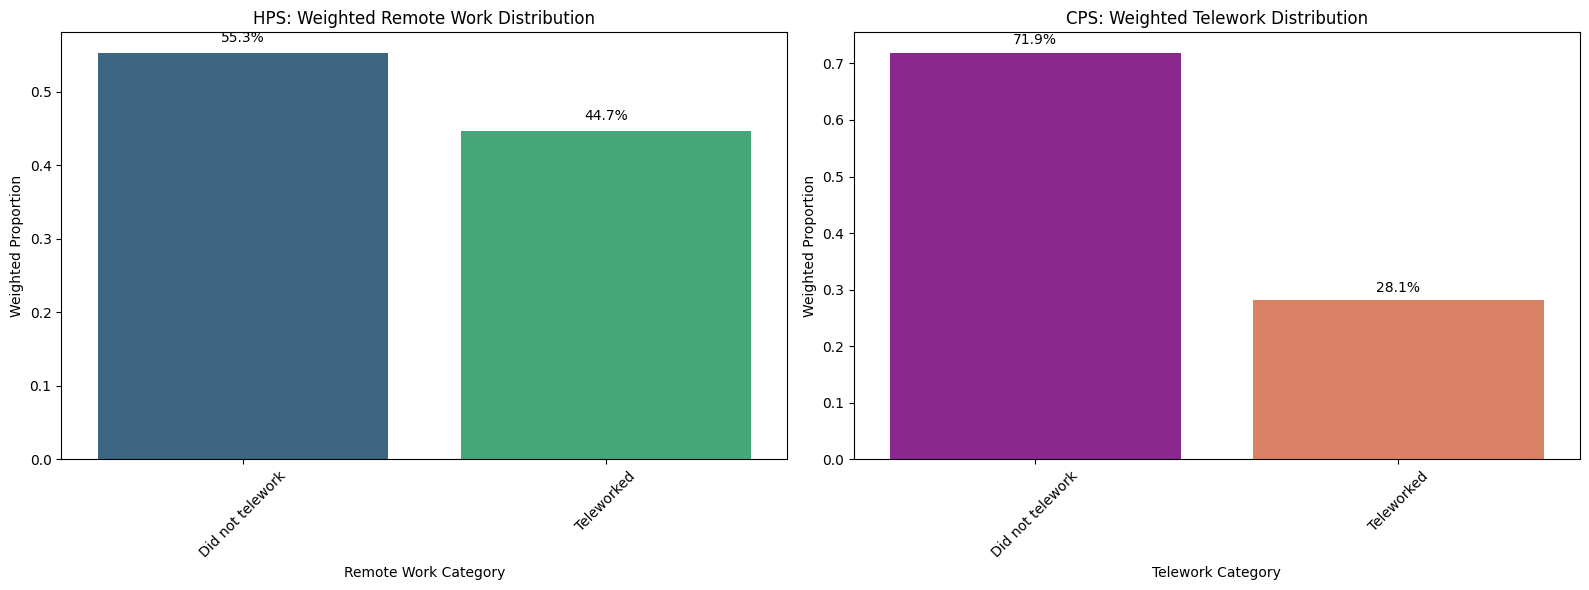

In [ ]:
remote_mapping_hps = {
    1: 'Teleworked',
    2: 'Did not telework'
}

pttlwk_mapping_cps = {
    1: 'Teleworked',
    2: 'Did not telework',
}

# Prepare HPS data
hps_remote_data = X_hps[['remote', 'PWEIGHT']].copy()
hps_remote_data['remote_category'] = hps_remote_data['remote'].map(remote_mapping_hps)

# Prepare CPS data
cps_remote_data = X_cps[['pttlwk', 'pwsswgt']].copy()
cps_remote_data['remote_category'] = cps_remote_data['pttlwk'].map(pttlwk_mapping_cps)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot HPS weighted remote work
hps_weighted_counts = hps_remote_data.groupby('remote_category')['PWEIGHT'].sum()
hps_total_weight = hps_weighted_counts.sum()
hps_weighted_proportions = hps_weighted_counts / hps_total_weight

sns.barplot(x=hps_weighted_proportions.index, y=hps_weighted_proportions.values, ax=axes[0], palette='viridis')
axes[0].set_title('HPS: Weighted Remote Work Distribution')
axes[0].set_xlabel('Remote Work Category')
axes[0].set_ylabel('Weighted Proportion')
axes[0].tick_params(axis='x', rotation=45)
for index, value in enumerate(hps_weighted_proportions.values):
    axes[0].text(index, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

# Plot CPS weighted remote work
cps_weighted_counts = cps_remote_data.groupby('remote_category')['pwsswgt'].sum()
cps_total_weight = cps_weighted_counts.sum()
cps_weighted_proportions = cps_weighted_counts / cps_total_weight

sns.barplot(x=cps_weighted_proportions.index, y=cps_weighted_proportions.values, ax=axes[1], palette='plasma')
axes[1].set_title('CPS: Weighted Telework Distribution')
axes[1].set_xlabel('Telework Category')
axes[1].set_ylabel('Weighted Proportion')
axes[1].tick_params(axis='x', rotation=45)
for index, value in enumerate(cps_weighted_proportions.values):
    axes[1].text(index, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

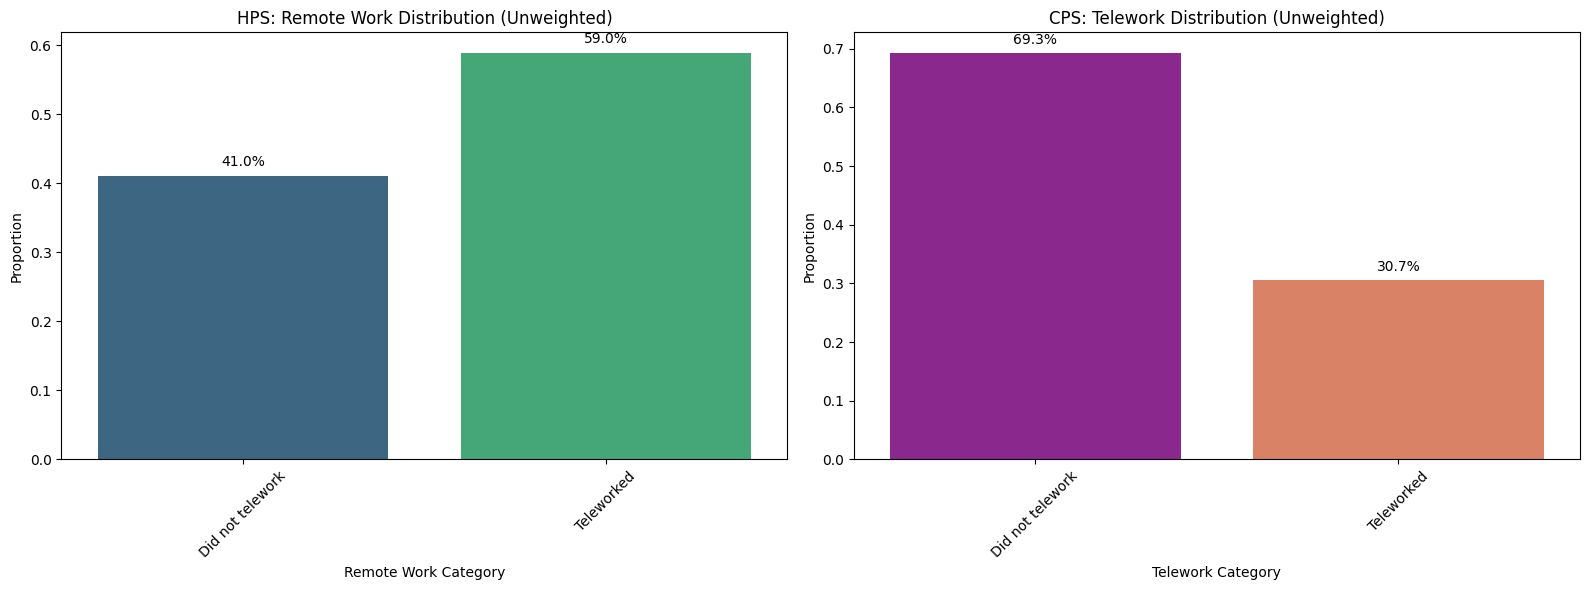

In [ ]:
remote_mapping_hps = {
    1: 'Teleworked',
    2: 'Did not telework'
}

pttlwk_mapping_cps = {
    1: 'Teleworked',
    2: 'Did not telework',
}

# Prepare HPS data
hps_remote_data = X_hps[['remote']].copy() # Removed PWEIGHT
hps_remote_data['remote_category'] = hps_remote_data['remote'].map(remote_mapping_hps)

# Prepare CPS data
cps_remote_data = X_cps[['pttlwk']].copy() # Removed pwsswgt
cps_remote_data['remote_category'] = cps_remote_data['pttlwk'].map(pttlwk_mapping_cps)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot HPS unweighted remote work
hps_counts = hps_remote_data.groupby('remote_category').size() # Count occurrences instead of summing weights
hps_total_count = hps_counts.sum()
hps_proportions = hps_counts / hps_total_count

sns.barplot(x=hps_proportions.index, y=hps_proportions.values, ax=axes[0], palette='viridis')
axes[0].set_title('HPS: Remote Work Distribution (Unweighted)')
axes[0].set_xlabel('Remote Work Category')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=45)
for index, value in enumerate(hps_proportions.values):
    axes[0].text(index, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

# Plot CPS unweighted remote work
cps_counts = cps_remote_data.groupby('remote_category').size() # Count occurrences instead of summing weights
cps_total_count = cps_counts.sum()
cps_proportions = cps_counts / cps_total_count

sns.barplot(x=cps_proportions.index, y=cps_proportions.values, ax=axes[1], palette='plasma')
axes[1].set_title('CPS: Telework Distribution (Unweighted)')
axes[1].set_xlabel('Telework Category')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=45)
for index, value in enumerate(cps_proportions.values):
    axes[1].text(index, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os
# import json
# import warnings
# from tqdm import tqdm
# from typing import Tuple, Dict, List

# warnings.filterwarnings('ignore')
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# np.random.seed(42)
# torch.manual_seed(42)
# if device.type == 'cuda':
#     torch.cuda.manual_seed_all(42)


# # =============================================================================
# # FOCAL LOSS
# # =============================================================================
# class FocalLoss(nn.Module):
#     """Focal Loss for class imbalance. FL(p_t) = -alpha_t * (1-p_t)^gamma * log(p_t)"""

#     def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0, reduction='none'):
#         super().__init__()
#         self.weight = weight
#         self.gamma = gamma
#         self.label_smoothing = label_smoothing
#         self.reduction = reduction

#     def forward(self, inputs, targets):
#         log_probs = F.log_softmax(inputs, dim=-1)
#         probs = torch.exp(log_probs)
#         log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
#         pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
#         focal_weight = (1 - pt) ** self.gamma

#         if self.weight is not None:
#             if self.weight.device != inputs.device:
#                 self.weight = self.weight.to(inputs.device)
#             alpha_t = self.weight.gather(0, targets)
#             focal_weight = alpha_t * focal_weight

#         focal_loss = -focal_weight * log_pt

#         if self.label_smoothing > 0:
#             smooth_loss = -log_probs.mean(dim=-1)
#             focal_loss = (1 - self.label_smoothing) * focal_loss + self.label_smoothing * smooth_loss

#         if self.reduction == 'mean':
#             return focal_loss.mean()
#         elif self.reduction == 'sum':
#             return focal_loss.sum()
#         return focal_loss


# def calculate_class_weights(y_train, remote2_boost=1.0, strategy='inverse_frequency'):
#     """Calculate class weights with optional Remote_2 (hybrid) boost."""
#     classes, counts = np.unique(y_train, return_counts=True)
#     n_samples, n_classes = len(y_train), len(classes)

#     if strategy == 'inverse_frequency':
#         weights = n_samples / (n_classes * counts)
#     elif strategy == 'effective_samples':
#         beta = 0.999
#         effective_num = 1.0 - np.power(beta, counts)
#         weights = (1.0 - beta) / effective_num
#     else:
#         weights = np.ones(n_classes)

#     weights = weights / weights.sum() * n_classes
#     return weights.astype(np.float32)


# # =============================================================================
# # DATA PREPROCESSOR WITH FEATURE INTERACTIONS
# # =============================================================================
# class DataPreprocessor:
#     """Handles CPS (pttlwk) and HPS (remote) with survey weights and feature interactions."""

#     def __init__(self, add_interactions=True):
#         self.common_features = ['AGE', 'EGENID_BIRTH', 'RHISPANIC', 'RRACE', 'EEDUC',
#                                 'MS', 'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA',
#                                 'THHLD_NUMPER', 'THHLD_NUMKID']
#         self.cps_specific = ['prdtind1', 'prdtocc1', 'gtco', 'gtcsa', 'penatvty',
#                              'pemntvty', 'pefntvty', 'pehractt']
#         self.hps_specific = ['HEARING', 'SEEING', 'MOBILITY', 'REMEMBERING',
#                              'SELFCARE', 'LIVQTRRV']
#         self.categorical = ['RHISPANIC', 'RRACE', 'EEDUC', 'MS', 'EGENID_BIRTH',
#                            'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA', 'HEARING',
#                            'SEEING', 'MOBILITY', 'REMEMBERING', 'SELFCARE', 'LIVQTRRV']
#         self.numerical = ['AGE', 'THHLD_NUMPER', 'THHLD_NUMKID']
#         self.scalers = {}
#         self.label_encoder = LabelEncoder()
#         self.exclude_from_cps_features = ['pttlwkhr']
#         self.add_interactions = add_interactions

#         # Track column indices for interaction creation
#         self.age_idx = None
#         self.edu_idx = None
#         self.income_idx = None
#         self.numper_idx = None
#         self.numkid_idx = None

#     def process_cps_remote_label(self, df):
#         """Convert pttlwk to remote categories (numeric 1, 2) to match HPS."""
#         print(f"\n📊 Processing CPS remote label (pttlwk)...")
#         df = df.copy()

#         if 'pttlwk' not in df.columns:
#             raise ValueError("CPS must have 'pttlwk' column for remote label generation.")

#         def categorize(x):
#             if x == 1: return 1  # Did not work from home -> No remote
#             elif x == 2: return 2  # Worked from home -> Yes remote
#             return np.nan

#         df['remote'] = df['pttlwk'].apply(categorize)
#         df = df.dropna(subset=['remote'])

#         print(f"   Distribution:")
#         for label, count in df['remote'].value_counts().items():
#             print(f"      {label}: {count:,} ({100*count/len(df):.1f}%)")
#         return df

#     def extract_weights(self, df, dataset_name):
#         """Extract and normalize survey weights."""
#         weight_col = 'pwsswgt' if dataset_name == 'CPS' else 'PWEIGHT'

#         if weight_col not in df.columns:
#             print(f"   ⚠️ {weight_col} not found, using uniform weights")
#             return np.ones(len(df), dtype=np.float32)

#         weights = pd.to_numeric(df[weight_col], errors='coerce').values
#         weights = np.nan_to_num(weights, nan=1.0)
#         upper = np.percentile(weights[weights > 0], 99) if np.any(weights > 0) else 1.0
#         weights = np.clip(weights, 0, upper)
#         weights[weights == 0] = weights[weights > 0].min() if np.any(weights > 0) else 1.0
#         weights = weights / weights.sum() * len(weights)

#         print(f"   ⚖️ {dataset_name} weights: min={weights.min():.3f}, max={weights.max():.3f}")
#         return weights.astype(np.float32)

#     def create_feature_interactions(self, X, names):
#         """Create meaningful feature interactions."""
#         if not self.add_interactions:
#             return X, names

#         print(f"\n🔗 Creating feature interactions...")

#         # Find indices of key features
#         age_idx = next((i for i, n in enumerate(names) if n == 'AGE'), None)
#         numper_idx = next((i for i, n in enumerate(names) if n == 'THHLD_NUMPER'), None)
#         numkid_idx = next((i for i, n in enumerate(names) if n == 'THHLD_NUMKID'), None)

#         # Find education and income categorical feature indices
#         edu_indices = [i for i, n in enumerate(names) if n.startswith('EEDUC_')]
#         income_indices = [i for i, n in enumerate(names) if n.startswith('INCOME_')]

#         interactions = []
#         interaction_names = []

#         # AGE-based interactions
#         if age_idx is not None:
#             age_vals = X[:, age_idx]

#             # Age × Education interactions
#             for edu_i in edu_indices[:5]:  # Limit to top 5 education categories
#                 interactions.append((age_vals * X[:, edu_i]).reshape(-1, 1))
#                 interaction_names.append(f'AGE_x_{names[edu_i]}')

#             # Age × Income interactions
#             for inc_i in income_indices[:5]:  # Limit to top 5 income categories
#                 interactions.append((age_vals * X[:, inc_i]).reshape(-1, 1))
#                 interaction_names.append(f'AGE_x_{names[inc_i]}')

#             # Age × Household size
#             if numper_idx is not None:
#                 interactions.append((age_vals * X[:, numper_idx]).reshape(-1, 1))
#                 interaction_names.append('AGE_x_THHLD_NUMPER')

#         # Household composition interactions
#         if numper_idx is not None and numkid_idx is not None:
#             # Adults in household (total - kids)
#             adults = X[:, numper_idx] - X[:, numkid_idx]
#             interactions.append(adults.reshape(-1, 1))
#             interaction_names.append('THHLD_ADULTS')

#             # Has children indicator × household size
#             has_kids = (X[:, numkid_idx] > 0).astype(np.float32)
#             interactions.append((has_kids * X[:, numper_idx]).reshape(-1, 1))
#             interaction_names.append('HAS_KIDS_x_NUMPER')

#         # Education × Income interactions (top combinations)
#         for edu_i in edu_indices[:3]:
#             for inc_i in income_indices[:3]:
#                 interactions.append((X[:, edu_i] * X[:, inc_i]).reshape(-1, 1))
#                 interaction_names.append(f'{names[edu_i]}_x_{names[inc_i]}')

#         if interactions:
#             X_interactions = np.hstack(interactions)
#             X_augmented = np.hstack([X, X_interactions])
#             names_augmented = names + interaction_names
#             print(f"   Added {len(interaction_names)} interactions: {X.shape[1]} → {X_augmented.shape[1]} features")
#             return X_augmented, names_augmented

#         return X, names

#     def encode_features(self, df, feature_list, dataset_name=""):
#         """Encode features with categorical handling."""
#         df_work = df[[f for f in feature_list if f in df.columns]].copy()
#         parts, names = [], []

#         for col in df_work.columns:
#             data = df_work[col]
#             is_cat = (col in self.categorical or col in self.cps_specific or
#                      (data.dtype not in ['float64'] and data.nunique() <= 50 and col not in self.numerical))

#             if is_cat:
#                 s = data.astype(str).fillna('Missing')
#                 if s.nunique() <= 100:
#                     dummies = pd.get_dummies(s, prefix=col, dtype=np.float32)
#                     parts.append(dummies.values)
#                     names.extend(dummies.columns.tolist())
#                 else:
#                     top = s.value_counts().head(50).index.tolist()
#                     s = s.apply(lambda x: x if x in top else 'Other')
#                     dummies = pd.get_dummies(s, prefix=col, dtype=np.float32)
#                     parts.append(dummies.values)
#                     names.extend(dummies.columns.tolist())
#             else:
#                 clean = pd.to_numeric(data, errors='coerce').fillna(data.median() if data.dtype != 'object' else 0)
#                 if col == 'AGE': clean = clean.clip(18, 85)
#                 elif col == 'THHLD_NUMPER': clean = clean.clip(1, 10)
#                 elif col == 'THHLD_NUMKID': clean = clean.clip(0, 10)
#                 parts.append(clean.values.reshape(-1, 1).astype(np.float32))
#                 names.append(col)

#         X = np.hstack(parts)
#         print(f"   {dataset_name} base features: {X.shape}")

#         # Add interactions
#         X, names = self.create_feature_interactions(X, names)

#         return X, names

#     def standardize(self, X, names, fit=True):
#         """Standardize numerical features and interactions."""
#         # Find all numerical columns (original + interactions)
#         numerical_cols = [n for n in self.numerical if n in names]
#         interaction_cols = [n for n in names if '_x_' in n or n == 'THHLD_ADULTS']
#         all_numerical = numerical_cols + interaction_cols

#         idx = [i for i, n in enumerate(names) if n in all_numerical]

#         if idx:
#             if fit:
#                 self.scalers['num'] = StandardScaler()
#                 X[:, idx] = self.scalers['num'].fit_transform(X[:, idx])
#             elif 'num' in self.scalers:
#                 X[:, idx] = self.scalers['num'].transform(X[:, idx])
#         return X

#     def preprocess_datasets(self, cps_df, hps_df):
#         """Complete preprocessing pipeline."""
#         print(f"\n{'='*70}\n⚡ PREPROCESSING\n{'='*70}")

#         cps_df = self.process_cps_remote_label(cps_df)

#         if 'remote' not in hps_df.columns:
#             raise ValueError("HPS must have 'remote' column")

#         print(f"\n📊 HPS remote distribution:")
#         for label, count in hps_df['remote'].value_counts().items():
#             print(f"   {label}: {count:,} ({100*count/len(hps_df):.1f}%)")

#         weights_cps = self.extract_weights(cps_df, 'CPS')
#         weights_hps = self.extract_weights(hps_df, 'HPS')

#         cps_feats = [f for f in self.common_features + self.cps_specific
#                      if f in cps_df.columns and f not in self.exclude_from_cps_features]
#         hps_feats = [f for f in self.common_features + self.hps_specific if f in hps_df.columns]

#         X_cps, cps_names = self.encode_features(cps_df, cps_feats, "CPS")
#         X_hps, hps_names = self.encode_features(hps_df, hps_feats, "HPS")

#         X_cps = self.standardize(X_cps, cps_names, fit=True)
#         X_hps = self.standardize(X_hps, hps_names, fit=False)

#         y_cps = self.label_encoder.fit_transform(cps_df['remote'].astype(int))
#         y_hps = self.label_encoder.transform(hps_df['remote'].astype(int))

#         print(f"\n✅ CPS: X={X_cps.shape}, y={y_cps.shape}")
#         print(f"   HPS: X={X_hps.shape}, y={y_hps.shape}")
#         print(f"   Classes: {self.label_encoder.classes_}")

#         return {'X_cps': X_cps, 'X_hps': X_hps, 'y_cps': y_cps, 'y_hps': y_hps,
#                 'weights_cps': weights_cps, 'weights_hps': weights_hps,
#                 'label_encoder': self.label_encoder,
#                 'feature_info': {'d_cps': X_cps.shape[1], 'd_hps': X_hps.shape[1],
#                                 'n_classes': len(self.label_encoder.classes_),
#                                 'cps_features': cps_names, 'hps_features': hps_names}}


# # =============================================================================
# # MMD LOSS
# # =============================================================================
# def compute_mmd(X_source, X_target):
#     """Multi-scale RBF MMD between source and target."""
#     def rbf(X, Y, sigma=1.0):
#         XX = (X * X).sum(1, keepdim=True)
#         YY = (Y * Y).sum(1, keepdim=True)
#         return torch.exp(-(XX + YY.t() - 2 * X @ Y.t()) / (2 * sigma ** 2))

#     n_s, n_t = X_source.size(0), X_target.size(0)
#     mmd = 0.0
#     for sigma in [0.1, 0.5, 1.0, 2.0, 5.0]:
#         K_ss = rbf(X_source, X_source, sigma)
#         K_tt = rbf(X_target, X_target, sigma)
#         K_st = rbf(X_source, X_target, sigma)
#         mmd += K_ss.sum()/(n_s*n_s) + K_tt.sum()/(n_t*n_t) - 2*K_st.sum()/(n_s*n_t)
#     return mmd / 5.0


# # =============================================================================
# # HFA MODEL
# # =============================================================================
# class HFAModel(nn.Module):
#     """HFA with projection matrices P (CPS→k) and Q (HPS→k)."""

#     def __init__(self, d_cps, d_hps, n_classes, k=64):
#         super().__init__()
#         self.d_cps, self.d_hps, self.k = d_cps, d_hps, k

#         self.P = nn.Linear(d_cps, k, bias=False)
#         self.Q = nn.Linear(d_hps, k, bias=False)
#         nn.init.xavier_uniform_(self.P.weight)
#         nn.init.xavier_uniform_(self.Q.weight)

#         self.d_aug = k + d_cps + d_hps
#         self.classifier = nn.Sequential(
#             nn.Linear(self.d_aug, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
#             nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
#             nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
#             nn.Linear(64, n_classes)
#         )
#         print(f"\n🏗️ HFA: d_cps={d_cps}, d_hps={d_hps}, k={k}, d_aug={self.d_aug}")

#     def augment_cps(self, X):
#         proj = self.P(X)
#         zeros = torch.zeros(X.size(0), self.d_hps, device=X.device)
#         return torch.cat([proj, X, zeros], dim=1)

#     def augment_hps(self, X):
#         proj = self.Q(X)
#         zeros = torch.zeros(X.size(0), self.d_cps, device=X.device)
#         return torch.cat([proj, zeros, X], dim=1)

#     def forward_cps(self, X):
#         return self.classifier(self.augment_cps(X)), self.P(X)

#     def forward_hps(self, X):
#         return self.classifier(self.augment_hps(X)), self.Q(X)

#     def forward_train(self, X_cps, X_hps):
#         proj_cps, proj_hps = self.P(X_cps), self.Q(X_hps)
#         logits = self.classifier(self.augment_cps(X_cps))
#         mmd = compute_mmd(proj_cps, proj_hps)
#         return {'logits': logits, 'proj_cps': proj_cps, 'proj_hps': proj_hps, 'mmd': mmd}


# # =============================================================================
# # HFA TRAINER
# # =============================================================================
# class HFATrainer:
#     """Trainer with toggleable Focal/CE loss and survey weight support."""

#     def __init__(self, model, lambda_mmd=0.1, lr=0.001, weight_decay=0.01,
#                  class_weights=None, use_focal_loss=True, focal_gamma=2.0, label_smoothing=0.1):
#         super().__init__()
#         self.model = model.to(device)
#         self.lambda_mmd = lambda_mmd
#         self.use_focal_loss = use_focal_loss

#         self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
#         self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', patience=10, factor=0.5)

#         wt = torch.FloatTensor(class_weights).to(device) if class_weights is not None else None
#         if use_focal_loss:
#             self.criterion = FocalLoss(weight=wt, gamma=focal_gamma, label_smoothing=label_smoothing, reduction='none')
#         else:
#             self.criterion = nn.CrossEntropyLoss(weight=wt, label_smoothing=label_smoothing, reduction='none')

#         self.history = {'train_loss': [], 'cls_loss': [], 'mmd_loss': [],
#                        'val_acc': [], 'val_f1': [], 'val_acc_wt': [], 'val_f1_wt': []}
#         self.best_state, self.best_f1 = None, 0.0

#     def reset_history(self):
#         self.history = {k: [] for k in self.history}
#         self.best_state, self.best_f1 = None, 0.0

#     def train_epoch(self, X_cps, y_cps, X_hps, weights_cps=None, importance_weights=None, batch_size=512):
#         self.model.train()
#         X_cps_t = torch.FloatTensor(X_cps).to(device)
#         y_cps_t = torch.LongTensor(y_cps).to(device)
#         X_hps_t = torch.FloatTensor(X_hps).to(device)
#         w_cps_t_full = torch.FloatTensor(weights_cps).to(device) if weights_cps is not None else None
#         importance_weights_t_full = torch.FloatTensor(importance_weights).to(device) if importance_weights is not None else None

#         n_cps, n_hps = len(X_cps), len(X_hps)
#         n_batches = (n_cps + batch_size - 1) // batch_size
#         idx = np.random.permutation(n_cps)

#         total_loss, total_cls, total_mmd = 0., 0., 0.

#         for i in range(n_batches):
#             bidx = idx[i*batch_size:(i+1)*batch_size]
#             X_cps_b, y_b = X_cps_t[bidx], y_cps_t[bidx]

#             hps_idx = np.random.choice(n_hps, size=len(bidx), replace=True)
#             X_hps_b = X_hps_t[hps_idx]

#             self.optimizer.zero_grad()
#             out = self.model.forward_train(X_cps_b, X_hps_b)

#             cls_loss_per = self.criterion(out['logits'], y_b)

#             current_cls_weights_batch = None
#             if importance_weights_t_full is not None:
#                 batch_importance_weights = importance_weights_t_full[bidx]
#                 current_cls_weights_batch = batch_importance_weights / batch_importance_weights.sum() * len(bidx)
#             elif w_cps_t_full is not None:
#                 current_cls_weights_batch = w_cps_t_full[bidx]

#             if current_cls_weights_batch is not None:
#                 cls_loss = (cls_loss_per * current_cls_weights_batch).mean()
#             else:
#                 cls_loss = cls_loss_per.mean()

#             loss = cls_loss + self.lambda_mmd * out['mmd']
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
#             self.optimizer.step()

#             total_loss += loss.item()
#             total_cls += cls_loss.item()
#             total_mmd += out['mmd'].item()

#         return total_loss/n_batches, total_cls/n_batches, total_mmd/n_batches

#     @torch.no_grad()
#     def validate(self, X, y, weights=None, data_type='hps'):
#         """Validate on either CPS or HPS data."""
#         self.model.eval()
#         X_t = torch.FloatTensor(X).to(device)

#         if data_type == 'cps':
#             logits, _ = self.model.forward_cps(X_t)
#         else:
#             logits, _ = self.model.forward_hps(X_t)

#         preds = logits.argmax(dim=1).cpu().numpy()

#         acc = accuracy_score(y, preds)
#         f1 = f1_score(y, preds, average='macro')

#         if weights is not None:
#             wn = weights / weights.sum()
#             acc_wt = np.sum((preds == y) * wn)
#             f1_wt = f1_score(y, preds, average='macro', sample_weight=weights)
#         else:
#             acc_wt = acc
#             f1_wt = f1

#         return {'accuracy': acc, 'f1_macro': f1, 'accuracy_wt': acc_wt,
#                 'f1_macro_wt': f1_wt, 'preds': preds}

#     def train(self, X_cps, y_cps, X_hps_train, y_hps_train, X_hps_val, y_val,
#               weights_cps=None, weights_hps_val=None, importance_weights=None,
#               epochs=100, batch_size=512, patience=20, save_path='models/phase1.pth'):

#         print(f"\n{'='*70}\n🚀 TRAINING\n{'='*70}")
#         print(f"   CPS: {len(X_cps):,}, HPS train: {len(X_hps_train):,}, HPS val: {len(X_hps_val):,}")
#         print(f"   Survey weights: {weights_cps is not None}, Importance weights: {importance_weights is not None}")

#         os.makedirs(os.path.dirname(save_path), exist_ok=True)
#         best_f1, no_improve = 0., 0

#         for epoch in tqdm(range(epochs), desc="Training"):
#             loss, cls, mmd = self.train_epoch(X_cps, y_cps, X_hps_train, weights_cps, importance_weights, batch_size)
#             res = self.validate(X_hps_val, y_val, weights_hps_val, data_type='hps')
#             self.scheduler.step(res['f1_macro'])

#             self.history['train_loss'].append(loss)
#             self.history['cls_loss'].append(cls)
#             self.history['mmd_loss'].append(mmd)
#             self.history['val_acc'].append(res['accuracy'])
#             self.history['val_f1'].append(res['f1_macro'])
#             self.history['val_acc_wt'].append(res['accuracy_wt'])
#             self.history['val_f1_wt'].append(res['f1_macro_wt'])

#             if res['f1_macro'] > best_f1:
#                 best_f1 = res['f1_macro']
#                 self.best_f1 = best_f1
#                 self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
#                 no_improve = 0
#                 torch.save({'model_state_dict': self.model.state_dict(), 'f1': best_f1, 'epoch': epoch}, save_path)
#             else:
#                 no_improve += 1

#             if no_improve >= patience:
#                 print(f"\n   Early stop at epoch {epoch+1}")
#                 break

#         if self.best_state:
#             self.model.load_state_dict(self.best_state)

#         print(f"\n   ✅ Best F1: {best_f1:.4f}")
#         return {'best_f1': best_f1}


# # =============================================================================
# # EVALUATION & VISUALIZATION
# # =============================================================================
# def evaluate_model(trainer, X_test, y_test, weights_test, label_encoder, name="Evaluation", data_type='hps'):
#     """Evaluate model with support for CPS or HPS data."""
#     print(f"\n{'='*70}\n📊 {name.upper()}\n{'='*70}")
#     res = trainer.validate(X_test, y_test, weights_test, data_type=data_type)
#     print(f"   Accuracy: {res['accuracy']:.4f}, F1: {res['f1_macro']:.4f}")
#     if weights_test is not None:
#         print(f"   Accuracy (weighted): {res['accuracy_wt']:.4f}, F1 (weighted): {res['f1_macro_wt']:.4f}")

#     print(classification_report(y_test, res['preds'],
#                                target_names=label_encoder.classes_.astype(str), digits=4))
#     cm = confusion_matrix(y_test, res['preds'])

#     return {'accuracy': res['accuracy'], 'f1_macro': res['f1_macro'],
#             'accuracy_wt': res['accuracy_wt'], 'f1_macro_wt': res['f1_macro_wt'],
#             'confusion_matrix': cm.tolist(), 'preds': res['preds']}


# def visualize_training(history, save_path='results/phase1_training.png'):
#     fig, axes = plt.subplots(2, 2, figsize=(14, 10))
#     epochs = range(1, len(history['train_loss']) + 1)

#     axes[0,0].plot(epochs, history['train_loss'], 'b-', label='Total')
#     axes[0,0].plot(epochs, history['cls_loss'], 'g--', label='Classification')
#     axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

#     axes[0,1].plot(epochs, history['mmd_loss'], 'r-')
#     axes[0,1].set_title('MMD Loss'); axes[0,1].grid(True, alpha=0.3)

#     axes[1,0].plot(epochs, history['val_acc'], 'b-', label='Unweighted')
#     axes[1,0].plot(epochs, history['val_acc_wt'], 'r--', label='Weighted')
#     axes[1,0].set_title('Validation Accuracy'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

#     axes[1,1].plot(epochs, history['val_f1'], 'b-', label='Unweighted')
#     axes[1,1].plot(epochs, history['val_f1_wt'], 'r--', label='Weighted')
#     axes[1,1].set_title('Validation F1'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     plt.savefig(save_path, dpi=150, bbox_inches='tight')
#     plt.show()


# # =============================================================================
# # RUN PHASE 1
# # =============================================================================
# def run_phase1(cps_df, hps_df, use_survey_weights=True, use_focal_loss=True, focal_gamma=2.0,
#                remote2_boost=1.0, lambda_mmd=0.1, k=64, epochs=100, batch_size=512,
#                save_dir='models', add_interactions=True, evaluate_cps=True):
#     """Run Phase 1: HFA training with feature interactions and CPS self-evaluation."""
#     print("\n" + "="*80 + "\n🎯 PHASE 1: HETEROGENEOUS FEATURE AUGMENTATION\n" + "="*80)

#     os.makedirs(save_dir, exist_ok=True)
#     os.makedirs('results', exist_ok=True)

#     # Preprocess with optional feature interactions
#     preprocessor = DataPreprocessor(add_interactions=add_interactions)
#     data = preprocessor.preprocess_datasets(cps_df, hps_df)

#     X_cps, X_hps, y_cps, y_hps = data['X_cps'], data['X_hps'], data['y_cps'], data['y_hps']
#     weights_cps = data['weights_cps'] if use_survey_weights else None
#     weights_hps = data['weights_hps'] if use_survey_weights else None

#     # Split CPS for self-evaluation if requested
#     if evaluate_cps:
#         print(f"\n📊 Splitting CPS for self-evaluation...")
#         X_cps_train, X_cps_test, y_cps_train, y_cps_test, w_cps_train, w_cps_test = train_test_split(
#             X_cps, y_cps,
#             weights_cps if weights_cps is not None else np.ones(len(y_cps)),
#             test_size=0.2, random_state=42, stratify=y_cps)

#         if not use_survey_weights:
#             w_cps_train, w_cps_test = None, None

#         print(f"   CPS train: {len(X_cps_train):,}, CPS test: {len(X_cps_test):,}")
#     else:
#         X_cps_train, y_cps_train, w_cps_train = X_cps, y_cps, weights_cps
#         X_cps_test, y_cps_test, w_cps_test = None, None, None

#     # Split HPS
#     X_hps_train, X_hps_val, y_hps_train, y_val, w_train, w_val = train_test_split(
#         X_hps, y_hps,
#         weights_hps if weights_hps is not None else np.ones(len(y_hps)),
#         test_size=0.2, random_state=42, stratify=y_hps)

#     if not use_survey_weights:
#         w_train, w_val = None, None

#     # Class weights
#     class_weights = calculate_class_weights(y_cps_train, remote2_boost=remote2_boost)

#     # Build model
#     model = HFAModel(data['feature_info']['d_cps'], data['feature_info']['d_hps'],
#                      data['feature_info']['n_classes'], k=k)

#     # Build trainer
#     trainer = HFATrainer(model, lambda_mmd=lambda_mmd, class_weights=class_weights,
#                          use_focal_loss=use_focal_loss, focal_gamma=focal_gamma)

#     # Train
#     suffix = '_weighted' if use_survey_weights else '_unweighted'
#     suffix += '_interact' if add_interactions else '_no_interact'
#     save_path = os.path.join(save_dir, f'phase1_model{suffix}.pth')

#     trainer.train(X_cps=X_cps_train, y_cps=y_cps_train,
#                   X_hps_train=X_hps_train, y_hps_train=y_hps_train,
#                   X_hps_val=X_hps_val, y_val=y_val,
#                   weights_cps=w_cps_train,
#                   weights_hps_val=w_val,
#                   epochs=epochs, batch_size=batch_size, save_path=save_path)

#     # Evaluate on HPS validation
#     print(f"\n{'='*70}\n🔍 HPS VALIDATION PERFORMANCE\n{'='*70}")
#     hps_results = evaluate_model(trainer, X_hps_val, y_val, w_val,
#                                   data['label_encoder'], "HPS Validation", data_type='hps')

#     # Evaluate on CPS test set (self-evaluation)
#     cps_results = None
#     if evaluate_cps and X_cps_test is not None:
#         print(f"\n{'='*70}\n🔍 CPS SELF-EVALUATION PERFORMANCE\n{'='*70}")
#         cps_results = evaluate_model(trainer, X_cps_test, y_cps_test, w_cps_test,
#                                       data['label_encoder'], "CPS Self-Evaluation", data_type='cps')

#     # Visualizations
#     visualize_training(trainer.history, f'results/phase1_training{suffix}.png')

#     # Save comprehensive results
#     results_dict = {
#         'hps_metrics': hps_results,
#         'cps_metrics': cps_results if cps_results else 'Not evaluated',
#         'config': {
#             'use_survey_weights': use_survey_weights,
#             'use_focal_loss': use_focal_loss,
#             'lambda_mmd': lambda_mmd,
#             'k': k,
#             'add_interactions': add_interactions,
#             'evaluate_cps': evaluate_cps,
#             'cps_train_size': len(X_cps_train),
#             'cps_test_size': len(X_cps_test) if X_cps_test is not None else 0,
#             'hps_train_size': len(X_hps_train),
#             'hps_val_size': len(X_hps_val),
#             'cps_feature_dim': data['feature_info']['d_cps'],
#             'hps_feature_dim': data['feature_info']['d_hps']
#         }
#     }

#     with open(f'results/phase1_results{suffix}.json', 'w') as f:
#         json.dump(results_dict, f, indent=2, default=str)

#     print(f"\n✅ Phase 1 complete! Model: {save_path}")

#     # Print summary comparison
#     print(f"\n{'='*70}\n📈 PERFORMANCE SUMMARY\n{'='*70}")
#     print(f"\n   HPS Validation:")
#     print(f"      Accuracy: {hps_results['accuracy']:.4f}, F1: {hps_results['f1_macro']:.4f}")
#     if cps_results:
#         print(f"\n   CPS Self-Evaluation:")
#         print(f"      Accuracy: {cps_results['accuracy']:.4f}, F1: {cps_results['f1_macro']:.4f}")
#         print(f"\n   Performance Gap (CPS - HPS):")
#         print(f"      Accuracy: {(cps_results['accuracy'] - hps_results['accuracy']):.4f}")
#         print(f"      F1: {(cps_results['f1_macro'] - hps_results['f1_macro']):.4f}")

#     return {
#         'model': model,
#         'trainer': trainer,
#         'results': hps_results,  # Main results for backward compatibility
#         'hps_results': hps_results,
#         'cps_results': cps_results,
#         'data': data,
#         'splits': {
#             'X_cps_train': X_cps_train, 'X_cps_test': X_cps_test,
#             'y_cps_train': y_cps_train, 'y_cps_test': y_cps_test,
#             'w_cps_train': w_cps_train, 'w_cps_test': w_cps_test,
#             'X_hps_train': X_hps_train, 'X_hps_val': X_hps_val,
#             'y_hps_train': y_hps_train, 'y_val': y_val,
#             'w_hps_train': w_train, 'w_hps_val': w_val
#         },
#         'preprocessor': preprocessor
#     }


# # =============================================================================
# # PERFORMANCE ANALYSIS UTILITIES
# # =============================================================================
# def analyze_performance_gap(results, save_dir='results/analysis'):
#     """Analyze performance gap between CPS and HPS."""
#     os.makedirs(save_dir, exist_ok=True)

#     hps_metrics = results['hps_results']
#     cps_metrics = results['cps_results']

#     if cps_metrics is None or cps_metrics == 'Not evaluated':
#         print("⚠️ CPS evaluation not available. Run with evaluate_cps=True")
#         return

#     print(f"\n{'='*70}\n📊 PERFORMANCE GAP ANALYSIS\n{'='*70}")

#     # Accuracy comparison
#     print(f"\n🎯 Accuracy Comparison:")
#     print(f"   CPS (in-domain):  {cps_metrics['accuracy']:.4f}")
#     print(f"   HPS (transfer):   {hps_metrics['accuracy']:.4f}")
#     print(f"   Gap (CPS - HPS):  {(cps_metrics['accuracy'] - hps_metrics['accuracy']):.4f}")

#     # F1 comparison
#     print(f"\n📈 F1-Score Comparison:")
#     print(f"   CPS (in-domain):  {cps_metrics['f1_macro']:.4f}")
#     print(f"   HPS (transfer):   {hps_metrics['f1_macro']:.4f}")
#     print(f"   Gap (CPS - HPS):  {(cps_metrics['f1_macro'] - hps_metrics['f1_macro']):.4f}")

#     # Weighted metrics if available
#     if 'accuracy_wt' in cps_metrics:
#         print(f"\n⚖️ Weighted Accuracy:")
#         print(f"   CPS (weighted):   {cps_metrics['accuracy_wt']:.4f}")
#         print(f"   HPS (weighted):   {hps_metrics['accuracy_wt']:.4f}")
#         print(f"   Gap (CPS - HPS):  {(cps_metrics['accuracy_wt'] - hps_metrics['accuracy_wt']):.4f}")

#     # Interpret the gap
#     print(f"\n💡 Interpretation:")
#     gap = cps_metrics['accuracy'] - hps_metrics['accuracy']
#     if gap > 0.1:
#         print("   ⚠️ Large gap (>10%): Significant domain shift detected")
#         print("   → Phase 2 importance weighting is critical")
#     elif gap > 0.05:
#         print("   ✓ Moderate gap (5-10%): Expected domain adaptation challenge")
#         print("   → Phase 2 should provide meaningful improvement")
#     elif gap > 0:
#         print("   ✓ Small gap (<5%): HFA effectively handles domain differences")
#         print("   → Phase 2 may provide marginal benefit")
#     else:
#         print("   ⚠️ Negative gap: HPS outperforms CPS")
#         print("   → Possible issues: overfitting, label noise, or feature mismatch")

#     # Visualization
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Accuracy comparison
#     metrics = ['Accuracy', 'F1-Score']
#     cps_vals = [cps_metrics['accuracy'], cps_metrics['f1_macro']]
#     hps_vals = [hps_metrics['accuracy'], hps_metrics['f1_macro']]

#     x = np.arange(len(metrics))
#     width = 0.35

#     axes[0].bar(x - width/2, cps_vals, width, label='CPS (in-domain)', color='#2E86AB')
#     axes[0].bar(x + width/2, hps_vals, width, label='HPS (transfer)', color='#A23B72')
#     axes[0].set_ylabel('Score')
#     axes[0].set_title('Performance Comparison')
#     axes[0].set_xticks(x)
#     axes[0].set_xticklabels(metrics)
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)
#     axes[0].set_ylim([0, 1])

#     # Confusion matrices
#     cm_cps = np.array(cps_metrics['confusion_matrix'])
#     cm_hps = np.array(hps_metrics['confusion_matrix'])

#     # Normalize confusion matrices
#     cm_cps_norm = cm_cps.astype('float') / cm_cps.sum(axis=1)[:, np.newaxis]
#     cm_hps_norm = cm_hps.astype('float') / cm_hps.sum(axis=1)[:, np.newaxis]

#     # Plot difference in confusion matrices
#     cm_diff = cm_cps_norm - cm_hps_norm

#     sns.heatmap(cm_diff, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
#                 xticklabels=['No Remote', 'Remote'],
#                 yticklabels=['No Remote', 'Remote'],
#                 ax=axes[1], cbar_kws={'label': 'CPS - HPS'})
#     axes[1].set_title('Confusion Matrix Difference\n(CPS - HPS, Normalized)')
#     axes[1].set_ylabel('True Label')
#     axes[1].set_xlabel('Predicted Label')

#     plt.tight_layout()
#     plt.savefig(f'{save_dir}/performance_gap.png', dpi=150, bbox_inches='tight')
#     plt.show()

#     # Class-wise performance
#     print(f"\n📋 Class-wise Analysis:")
#     print(f"\n   CPS Confusion Matrix (normalized):")
#     print(f"   {cm_cps_norm}")
#     print(f"\n   HPS Confusion Matrix (normalized):")
#     print(f"   {cm_hps_norm}")
#     print(f"\n   Difference (CPS - HPS):")
#     print(f"   {cm_diff}")

#     # Calculate per-class metrics
#     cps_recall = np.diag(cm_cps_norm)
#     hps_recall = np.diag(cm_hps_norm)

#     print(f"\n   Class Recall Comparison:")
#     for i, (cps_r, hps_r) in enumerate(zip(cps_recall, hps_recall)):
#         class_name = "No Remote" if i == 0 else "Remote"
#         print(f"      {class_name}: CPS={cps_r:.4f}, HPS={hps_r:.4f}, Gap={cps_r-hps_r:.4f}")

#     # Save detailed report
#     report = {
#         'cps_metrics': cps_metrics,
#         'hps_metrics': hps_metrics,
#         'gaps': {
#             'accuracy': float(cps_metrics['accuracy'] - hps_metrics['accuracy']),
#             'f1_macro': float(cps_metrics['f1_macro'] - hps_metrics['f1_macro']),
#         },
#         'confusion_matrices': {
#             'cps_normalized': cm_cps_norm.tolist(),
#             'hps_normalized': cm_hps_norm.tolist(),
#             'difference': cm_diff.tolist()
#         },
#         'class_recalls': {
#             'cps': cps_recall.tolist(),
#             'hps': hps_recall.tolist(),
#             'gaps': (cps_recall - hps_recall).tolist()
#         }
#     }

#     with open(f'{save_dir}/performance_gap_analysis.json', 'w') as f:
#         json.dump(report, f, indent=2, default=str)

#     print(f"\n✅ Analysis saved to {save_dir}/")

#     return report
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from tqdm import tqdm
from typing import Tuple, Dict, List

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

np.random.seed(42)
torch.manual_seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(42)


# =============================================================================
# FOCAL LOSS
# =============================================================================
class FocalLoss(nn.Module):
    """Focal Loss for class imbalance. FL(p_t) = -alpha_t * (1-p_t)^gamma * log(p_t)"""

    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0, reduction='none'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=-1)
        probs = torch.exp(log_probs)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma

        if self.weight is not None:
            if self.weight.device != inputs.device:
                self.weight = self.weight.to(inputs.device)
            alpha_t = self.weight.gather(0, targets)
            focal_weight = alpha_t * focal_weight

        focal_loss = -focal_weight * log_pt

        if self.label_smoothing > 0:
            smooth_loss = -log_probs.mean(dim=-1)
            focal_loss = (1 - self.label_smoothing) * focal_loss + self.label_smoothing * smooth_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


def calculate_class_weights(y_train, remote2_boost=1.0, strategy='inverse_frequency'):
    """Calculate class weights with optional Remote_2 (hybrid) boost."""
    classes, counts = np.unique(y_train, return_counts=True)
    n_samples, n_classes = len(y_train), len(classes)

    if strategy == 'inverse_frequency':
        weights = n_samples / (n_classes * counts)
    elif strategy == 'effective_samples':
        beta = 0.999
        effective_num = 1.0 - np.power(beta, counts)
        weights = (1.0 - beta) / effective_num
    else:
        weights = np.ones(n_classes)

    weights = weights / weights.sum() * n_classes
    return weights.astype(np.float32)


# =============================================================================
# DATA PREPROCESSOR WITH FEATURE INTERACTIONS
# =============================================================================
class DataPreprocessor:
    """Handles CPS (pttlwk) and HPS (remote) with survey weights and feature interactions."""

    def __init__(self, add_interactions=True):
        self.common_features = ['AGE', 'EGENID_BIRTH', 'RHISPANIC', 'RRACE', 'EEDUC',
                                'MS', 'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA',
                                'THHLD_NUMPER', 'THHLD_NUMKID']
        self.cps_specific = ['prdtind1', 'prdtocc1', 'gtco', 'gtcsa', 'penatvty',
                             'pemntvty', 'pefntvty', 'pehractt']
        self.hps_specific = ['HEARING', 'SEEING', 'MOBILITY', 'REMEMBERING',
                             'SELFCARE', 'LIVQTRRV']
        self.categorical = ['RHISPANIC', 'RRACE', 'EEDUC', 'MS', 'EGENID_BIRTH',
                           'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA', 'HEARING',
                           'SEEING', 'MOBILITY', 'REMEMBERING', 'SELFCARE', 'LIVQTRRV']
        self.numerical = ['AGE', 'THHLD_NUMPER', 'THHLD_NUMKID']
        self.scalers = {}
        self.label_encoder = LabelEncoder()
        self.exclude_from_cps_features = ['pttlwkhr']
        self.add_interactions = add_interactions

        # Track column indices for interaction creation
        self.age_idx = None
        self.edu_idx = None
        self.income_idx = None
        self.numper_idx = None
        self.numkid_idx = None

    def process_cps_remote_label(self, df):
        """Convert pttlwk to remote categories (numeric 1, 2) to match HPS."""
        print(f"\n📊 Processing CPS remote label (pttlwk)...")
        df = df.copy()

        if 'pttlwk' not in df.columns:
            raise ValueError("CPS must have 'pttlwk' column for remote label generation.")

        def categorize(x):
            if x == 1: return 1  # Did not work from home -> No remote
            elif x == 2: return 2  # Worked from home -> Yes remote
            return np.nan

        df['remote'] = df['pttlwk'].apply(categorize)
        df = df.dropna(subset=['remote'])

        print(f"   Distribution:")
        for label, count in df['remote'].value_counts().items():
            print(f"      {label}: {count:,} ({100*count/len(df):.1f}%)")
        return df

    def extract_weights(self, df, dataset_name):
        """Extract and normalize survey weights."""
        weight_col = 'pwsswgt' if dataset_name == 'CPS' else 'PWEIGHT'

        if weight_col not in df.columns:
            print(f"   ⚠️ {weight_col} not found, using uniform weights")
            return np.ones(len(df), dtype=np.float32)

        weights = pd.to_numeric(df[weight_col], errors='coerce').values
        weights = np.nan_to_num(weights, nan=1.0)
        upper = np.percentile(weights[weights > 0], 99) if np.any(weights > 0) else 1.0
        weights = np.clip(weights, 0, upper)
        weights[weights == 0] = weights[weights > 0].min() if np.any(weights > 0) else 1.0
        weights = weights / weights.sum() * len(weights)

        print(f"   ⚖️ {dataset_name} weights: min={weights.min():.3f}, max={weights.max():.3f}")
        return weights.astype(np.float32)

    def create_feature_interactions(self, X, names):
        """Create meaningful feature interactions."""
        if not self.add_interactions:
            return X, names

        print(f"\n🔗 Creating feature interactions...")

        # Find indices of key features
        age_idx = next((i for i, n in enumerate(names) if n == 'AGE'), None)
        numper_idx = next((i for i, n in enumerate(names) if n == 'THHLD_NUMPER'), None)
        numkid_idx = next((i for i, n in enumerate(names) if n == 'THHLD_NUMKID'), None)

        # Find education and income categorical feature indices
        edu_indices = [i for i, n in enumerate(names) if n.startswith('EEDUC_')]
        income_indices = [i for i, n in enumerate(names) if n.startswith('INCOME_')]

        interactions = []
        interaction_names = []

        # AGE-based interactions
        if age_idx is not None:
            age_vals = X[:, age_idx]

            # Age × Education interactions
            for edu_i in edu_indices[:5]:  # Limit to top 5 education categories
                interactions.append((age_vals * X[:, edu_i]).reshape(-1, 1))
                interaction_names.append(f'AGE_x_{names[edu_i]}')

            # Age × Income interactions
            for inc_i in income_indices[:5]:  # Limit to top 5 income categories
                interactions.append((age_vals * X[:, inc_i]).reshape(-1, 1))
                interaction_names.append(f'AGE_x_{names[inc_i]}')

            # Age × Household size
            if numper_idx is not None:
                interactions.append((age_vals * X[:, numper_idx]).reshape(-1, 1))
                interaction_names.append('AGE_x_THHLD_NUMPER')

        # Household composition interactions
        if numper_idx is not None and numkid_idx is not None:
            # Adults in household (total - kids)
            adults = X[:, numper_idx] - X[:, numkid_idx]
            interactions.append(adults.reshape(-1, 1))
            interaction_names.append('THHLD_ADULTS')

            # Has children indicator × household size
            has_kids = (X[:, numkid_idx] > 0).astype(np.float32)
            interactions.append((has_kids * X[:, numper_idx]).reshape(-1, 1))
            interaction_names.append('HAS_KIDS_x_NUMPER')

        # Education × Income interactions (top combinations)
        for edu_i in edu_indices[:3]:
            for inc_i in income_indices[:3]:
                interactions.append((X[:, edu_i] * X[:, inc_i]).reshape(-1, 1))
                interaction_names.append(f'{names[edu_i]}_x_{names[inc_i]}')

        if interactions:
            X_interactions = np.hstack(interactions)
            X_augmented = np.hstack([X, X_interactions])
            names_augmented = names + interaction_names
            print(f"   Added {len(interaction_names)} interactions: {X.shape[1]} → {X_augmented.shape[1]} features")
            return X_augmented, names_augmented

        return X, names

    def encode_features(self, df, feature_list, dataset_name=""):
        """Encode features with categorical handling."""
        df_work = df[[f for f in feature_list if f in df.columns]].copy()
        parts, names = [], []

        for col in df_work.columns:
            data = df_work[col]
            is_cat = (col in self.categorical or col in self.cps_specific or
                     (data.dtype not in ['float64'] and data.nunique() <= 50 and col not in self.numerical))

            if is_cat:
                s = data.astype(str).fillna('Missing')
                if s.nunique() <= 100:
                    dummies = pd.get_dummies(s, prefix=col, dtype=np.float32)
                    parts.append(dummies.values)
                    names.extend(dummies.columns.tolist())
                else:
                    top = s.value_counts().head(50).index.tolist()
                    s = s.apply(lambda x: x if x in top else 'Other')
                    dummies = pd.get_dummies(s, prefix=col, dtype=np.float32)
                    parts.append(dummies.values)
                    names.extend(dummies.columns.tolist())
            else:
                clean = pd.to_numeric(data, errors='coerce').fillna(data.median() if data.dtype != 'object' else 0)
                if col == 'AGE': clean = clean.clip(18, 85)
                elif col == 'THHLD_NUMPER': clean = clean.clip(1, 10)
                elif col == 'THHLD_NUMKID': clean = clean.clip(0, 10)
                parts.append(clean.values.reshape(-1, 1).astype(np.float32))
                names.append(col)

        X = np.hstack(parts)
        print(f"   {dataset_name} base features: {X.shape}")

        # Add interactions
        X, names = self.create_feature_interactions(X, names)

        return X, names

    def standardize(self, X, names, fit=True):
        """Standardize numerical features and interactions."""
        # Find all numerical columns (original + interactions)
        numerical_cols = [n for n in self.numerical if n in names]
        interaction_cols = [n for n in names if '_x_' in n or n == 'THHLD_ADULTS']
        all_numerical = numerical_cols + interaction_cols

        idx = [i for i, n in enumerate(names) if n in all_numerical]

        if idx:
            if fit:
                self.scalers['num'] = StandardScaler()
                X[:, idx] = self.scalers['num'].fit_transform(X[:, idx])
            elif 'num' in self.scalers:
                X[:, idx] = self.scalers['num'].transform(X[:, idx])
        return X

    def preprocess_datasets(self, cps_df, hps_df):
        """Complete preprocessing pipeline."""
        print(f"\n{'='*70}\n⚡ PREPROCESSING\n{'='*70}")

        cps_df = self.process_cps_remote_label(cps_df)

        if 'remote' not in hps_df.columns:
            raise ValueError("HPS must have 'remote' column")

        print(f"\n📊 HPS remote distribution:")
        for label, count in hps_df['remote'].value_counts().items():
            print(f"   {label}: {count:,} ({100*count/len(hps_df):.1f}%)")

        weights_cps = self.extract_weights(cps_df, 'CPS')
        weights_hps = self.extract_weights(hps_df, 'HPS')

        cps_feats = [f for f in self.common_features + self.cps_specific
                     if f in cps_df.columns and f not in self.exclude_from_cps_features]
        hps_feats = [f for f in self.common_features + self.hps_specific if f in hps_df.columns]

        X_cps, cps_names = self.encode_features(cps_df, cps_feats, "CPS")
        X_hps, hps_names = self.encode_features(hps_df, hps_feats, "HPS")

        X_cps = self.standardize(X_cps, cps_names, fit=True)
        X_hps = self.standardize(X_hps, hps_names, fit=False)

        y_cps = self.label_encoder.fit_transform(cps_df['remote'].astype(int))
        y_hps = self.label_encoder.transform(hps_df['remote'].astype(int))

        print(f"\n✅ CPS: X={X_cps.shape}, y={y_cps.shape}")
        print(f"   HPS: X={X_hps.shape}, y={y_hps.shape}")
        print(f"   Classes: {self.label_encoder.classes_}")

        return {'X_cps': X_cps, 'X_hps': X_hps, 'y_cps': y_cps, 'y_hps': y_hps,
                'weights_cps': weights_cps, 'weights_hps': weights_hps,
                'label_encoder': self.label_encoder,
                'feature_info': {'d_cps': X_cps.shape[1], 'd_hps': X_hps.shape[1],
                                'n_classes': len(self.label_encoder.classes_),
                                'cps_features': cps_names, 'hps_features': hps_names}}


# =============================================================================
# MMD LOSS
# =============================================================================
def compute_mmd(X_source, X_target):
    """Multi-scale RBF MMD between source and target."""
    def rbf(X, Y, sigma=1.0):
        XX = (X * X).sum(1, keepdim=True)
        YY = (Y * Y).sum(1, keepdim=True)
        return torch.exp(-(XX + YY.t() - 2 * X @ Y.t()) / (2 * sigma ** 2))

    n_s, n_t = X_source.size(0), X_target.size(0)
    mmd = 0.0
    for sigma in [0.1, 0.5, 1.0, 2.0, 5.0]:
        K_ss = rbf(X_source, X_source, sigma)
        K_tt = rbf(X_target, X_target, sigma)
        K_st = rbf(X_source, X_target, sigma)
        mmd += K_ss.sum()/(n_s*n_s) + K_tt.sum()/(n_t*n_t) - 2*K_st.sum()/(n_s*n_t)
    return mmd / 5.0


# =============================================================================
# HFA MODEL
# =============================================================================
class HFAModel(nn.Module):
    """HFA with projection matrices P (CPS→k) and Q (HPS→k)."""

    def __init__(self, d_cps, d_hps, n_classes, k=64):
        super().__init__()
        self.d_cps, self.d_hps, self.k = d_cps, d_hps, k

        self.P = nn.Linear(d_cps, k, bias=False)
        self.Q = nn.Linear(d_hps, k, bias=False)
        nn.init.xavier_uniform_(self.P.weight)
        nn.init.xavier_uniform_(self.Q.weight)

        self.d_aug = k + d_cps + d_hps
        self.classifier = nn.Sequential(
            nn.Linear(self.d_aug, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
        print(f"\n🏗️ HFA: d_cps={d_cps}, d_hps={d_hps}, k={k}, d_aug={self.d_aug}")

    def augment_cps(self, X):
        proj = self.P(X)
        zeros = torch.zeros(X.size(0), self.d_hps, device=X.device)
        return torch.cat([proj, X, zeros], dim=1)

    def augment_hps(self, X):
        proj = self.Q(X)
        zeros = torch.zeros(X.size(0), self.d_cps, device=X.device)
        return torch.cat([proj, zeros, X], dim=1)

    def forward_cps(self, X):
        return self.classifier(self.augment_cps(X)), self.P(X)

    def forward_hps(self, X):
        return self.classifier(self.augment_hps(X)), self.Q(X)

    def forward_train(self, X_cps, X_hps):
        proj_cps, proj_hps = self.P(X_cps), self.Q(X_hps)
        logits = self.classifier(self.augment_cps(X_cps))
        mmd = compute_mmd(proj_cps, proj_hps)
        return {'logits': logits, 'proj_cps': proj_cps, 'proj_hps': proj_hps, 'mmd': mmd}


# =============================================================================
# HFA TRAINER
# =============================================================================
class HFATrainer:
    """Trainer with toggleable Focal/CE loss and survey weight support."""

    def __init__(self, model, lambda_mmd=0.1, lr=0.001, weight_decay=0.01,
                 class_weights=None, use_focal_loss=True, focal_gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.model = model.to(device)
        self.lambda_mmd = lambda_mmd
        self.use_focal_loss = use_focal_loss

        self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', patience=10, factor=0.5)

        wt = torch.FloatTensor(class_weights).to(device) if class_weights is not None else None
        if use_focal_loss:
            self.criterion = FocalLoss(weight=wt, gamma=focal_gamma, label_smoothing=label_smoothing, reduction='none')
        else:
            self.criterion = nn.CrossEntropyLoss(weight=wt, label_smoothing=label_smoothing, reduction='none')

        self.history = {'train_loss': [], 'cls_loss': [], 'mmd_loss': [],
                       'val_acc': [], 'val_f1': [], 'val_acc_wt': [], 'val_f1_wt': []}
        self.best_state, self.best_f1 = None, 0.0

    def reset_history(self):
        self.history = {k: [] for k in self.history}
        self.best_state, self.best_f1 = None, 0.0

    def train_epoch(self, X_cps, y_cps, X_hps, weights_cps=None, importance_weights=None, batch_size=512):
        self.model.train()
        X_cps_t = torch.FloatTensor(X_cps).to(device)
        y_cps_t = torch.LongTensor(y_cps).to(device)
        X_hps_t = torch.FloatTensor(X_hps).to(device)
        w_cps_t_full = torch.FloatTensor(weights_cps).to(device) if weights_cps is not None else None
        importance_weights_t_full = torch.FloatTensor(importance_weights).to(device) if importance_weights is not None else None

        n_cps, n_hps = len(X_cps), len(X_hps)
        n_batches = (n_cps + batch_size - 1) // batch_size
        idx = np.random.permutation(n_cps)

        total_loss, total_cls, total_mmd = 0., 0., 0.

        for i in range(n_batches):
            bidx = idx[i*batch_size:(i+1)*batch_size]
            X_cps_b, y_b = X_cps_t[bidx], y_cps_t[bidx]

            hps_idx = np.random.choice(n_hps, size=len(bidx), replace=True)
            X_hps_b = X_hps_t[hps_idx]

            self.optimizer.zero_grad()
            out = self.model.forward_train(X_cps_b, X_hps_b)

            cls_loss_per = self.criterion(out['logits'], y_b)

            current_cls_weights_batch = None
            if importance_weights_t_full is not None:
                batch_importance_weights = importance_weights_t_full[bidx]
                current_cls_weights_batch = batch_importance_weights / batch_importance_weights.sum() * len(bidx)
            elif w_cps_t_full is not None:
                current_cls_weights_batch = w_cps_t_full[bidx]

            if current_cls_weights_batch is not None:
                cls_loss = (cls_loss_per * current_cls_weights_batch).mean()
            else:
                cls_loss = cls_loss_per.mean()

            loss = cls_loss + self.lambda_mmd * out['mmd']
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total_loss += loss.item()
            total_cls += cls_loss.item()
            total_mmd += out['mmd'].item()

        return total_loss/n_batches, total_cls/n_batches, total_mmd/n_batches

    @torch.no_grad()
    def validate(self, X, y, weights=None, data_type='hps'):
        """Validate on either CPS or HPS data with proper weighting."""
        self.model.eval()
        X_t = torch.FloatTensor(X).to(device)

        if data_type == 'cps':
            logits, _ = self.model.forward_cps(X_t)
        else:
            logits, _ = self.model.forward_hps(X_t)

        preds = logits.argmax(dim=1).cpu().numpy()

        # Unweighted metrics (uniform sample distribution)
        acc_unweighted = accuracy_score(y, preds)
        f1_unweighted = f1_score(y, preds, average='macro')

        # Weighted metrics (population-representative)
        if weights is not None:
            # Normalize weights to sum to 1 for proper probability weighting
            wn = weights / weights.sum()
            acc_weighted = np.sum((preds == y) * wn)
            f1_weighted = f1_score(y, preds, average='macro', sample_weight=weights)
        else:
            acc_weighted = acc_unweighted
            f1_weighted = f1_unweighted

        return {'accuracy': acc_unweighted, 'f1_macro': f1_unweighted,
                'accuracy_wt': acc_weighted, 'f1_macro_wt': f1_weighted,
                'preds': preds, 'weights': weights}

    def train(self, X_cps, y_cps, X_hps_train, y_hps_train, X_hps_val, y_val,
              weights_cps=None, weights_hps_val=None, importance_weights=None,
              epochs=100, batch_size=512, patience=20, save_path='models/phase1.pth'):

        print(f"\n{'='*70}\n🚀 TRAINING\n{'='*70}")
        print(f"   CPS: {len(X_cps):,}, HPS train: {len(X_hps_train):,}, HPS val: {len(X_hps_val):,}")
        print(f"   Survey weights: {weights_cps is not None}, Importance weights: {importance_weights is not None}")

        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        best_f1, no_improve = 0., 0

        for epoch in tqdm(range(epochs), desc="Training"):
            loss, cls, mmd = self.train_epoch(X_cps, y_cps, X_hps_train, weights_cps, importance_weights, batch_size)
            res = self.validate(X_hps_val, y_val, weights_hps_val, data_type='hps')
            self.scheduler.step(res['f1_macro'])

            self.history['train_loss'].append(loss)
            self.history['cls_loss'].append(cls)
            self.history['mmd_loss'].append(mmd)
            self.history['val_acc'].append(res['accuracy'])
            self.history['val_f1'].append(res['f1_macro'])
            self.history['val_acc_wt'].append(res['accuracy_wt'])
            self.history['val_f1_wt'].append(res['f1_macro_wt'])

            if res['f1_macro'] > best_f1:
                best_f1 = res['f1_macro']
                self.best_f1 = best_f1
                self.best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                no_improve = 0
                torch.save({'model_state_dict': self.model.state_dict(), 'f1': best_f1, 'epoch': epoch}, save_path)
            else:
                no_improve += 1

            if no_improve >= patience:
                print(f"\n   Early stop at epoch {epoch+1}")
                break

        if self.best_state:
            self.model.load_state_dict(self.best_state)

        print(f"\n   ✅ Best F1: {best_f1:.4f}")
        return {'best_f1': best_f1}


# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================
def make_json_serializable(obj):
    """Convert numpy/torch types to JSON-serializable Python types."""
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: make_json_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [make_json_serializable(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(make_json_serializable(item) for item in obj)
    else:
        return obj


# =============================================================================
# EVALUATION & VISUALIZATION
# =============================================================================
def evaluate_model(trainer, X_test, y_test, weights_test, label_encoder, name="Evaluation", data_type='hps'):
    """Evaluate model with support for CPS or HPS data."""
    print(f"\n{'='*70}\n📊 {name.upper()}\n{'='*70}")
    res = trainer.validate(X_test, y_test, weights_test, data_type=data_type)
    print(f"   Accuracy: {res['accuracy']:.4f}, F1: {res['f1_macro']:.4f}")
    if weights_test is not None:
        print(f"   Accuracy (weighted): {res['accuracy_wt']:.4f}, F1 (weighted): {res['f1_macro_wt']:.4f}")

    print(classification_report(y_test, res['preds'],
                               target_names=label_encoder.classes_.astype(str), digits=4))
    cm = confusion_matrix(y_test, res['preds'])

    # Convert all numpy types to native Python types for JSON serialization
    return {
        'accuracy': float(res['accuracy']),
        'f1_macro': float(res['f1_macro']),
        'accuracy_wt': float(res['accuracy_wt']),
        'f1_macro_wt': float(res['f1_macro_wt']),
        'confusion_matrix': cm.tolist(),  # Convert to list
        'preds': res['preds'].tolist() if isinstance(res['preds'], np.ndarray) else res['preds']
    }


def visualize_training(history, save_path='results/phase1_training.png'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0,0].plot(epochs, history['train_loss'], 'b-', label='Total')
    axes[0,0].plot(epochs, history['cls_loss'], 'g--', label='Classification')
    axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(epochs, history['mmd_loss'], 'r-')
    axes[0,1].set_title('MMD Loss'); axes[0,1].grid(True, alpha=0.3)

    axes[1,0].plot(epochs, history['val_acc'], 'b-', label='Unweighted')
    axes[1,0].plot(epochs, history['val_acc_wt'], 'r--', label='Weighted')
    axes[1,0].set_title('Validation Accuracy'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(epochs, history['val_f1'], 'b-', label='Unweighted')
    axes[1,1].plot(epochs, history['val_f1_wt'], 'r--', label='Weighted')
    axes[1,1].set_title('Validation F1'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# =============================================================================
# RUN PHASE 1
# =============================================================================
def run_phase1(cps_df, hps_df, use_survey_weights=True, use_focal_loss=True, focal_gamma=2.0,
               remote2_boost=1.0, lambda_mmd=0.1, k=64, epochs=100, batch_size=512,
               save_dir='models', add_interactions=True, evaluate_cps=True):
    """Run Phase 1: HFA training with feature interactions and CPS self-evaluation."""
    print("\n" + "="*80 + "\n🎯 PHASE 1: HETEROGENEOUS FEATURE AUGMENTATION\n" + "="*80)

    os.makedirs(save_dir, exist_ok=True)
    os.makedirs('results', exist_ok=True)

    # Preprocess with optional feature interactions
    preprocessor = DataPreprocessor(add_interactions=add_interactions)
    data = preprocessor.preprocess_datasets(cps_df, hps_df)

    X_cps, X_hps, y_cps, y_hps = data['X_cps'], data['X_hps'], data['y_cps'], data['y_hps']
    weights_cps = data['weights_cps'] if use_survey_weights else None
    weights_hps = data['weights_hps'] if use_survey_weights else None

    # Split CPS for self-evaluation if requested
    if evaluate_cps:
        print(f"\n📊 Splitting CPS for self-evaluation...")
        X_cps_train, X_cps_test, y_cps_train, y_cps_test, w_cps_train, w_cps_test = train_test_split(
            X_cps, y_cps,
            weights_cps if weights_cps is not None else np.ones(len(y_cps)),
            test_size=0.2, random_state=42, stratify=y_cps)

        if not use_survey_weights:
            w_cps_train, w_cps_test = None, None

        print(f"   CPS train: {len(X_cps_train):,}, CPS test: {len(X_cps_test):,}")
    else:
        X_cps_train, y_cps_train, w_cps_train = X_cps, y_cps, weights_cps
        X_cps_test, y_cps_test, w_cps_test = None, None, None

    # Split HPS
    X_hps_train, X_hps_val, y_hps_train, y_val, w_train, w_val = train_test_split(
        X_hps, y_hps,
        weights_hps if weights_hps is not None else np.ones(len(y_hps)),
        test_size=0.2, random_state=42, stratify=y_hps)

    if not use_survey_weights:
        w_train, w_val = None, None

    # Class weights
    class_weights = calculate_class_weights(y_cps_train, remote2_boost=remote2_boost)

    # Build model
    model = HFAModel(data['feature_info']['d_cps'], data['feature_info']['d_hps'],
                     data['feature_info']['n_classes'], k=k)

    # Build trainer
    trainer = HFATrainer(model, lambda_mmd=lambda_mmd, class_weights=class_weights,
                         use_focal_loss=use_focal_loss, focal_gamma=focal_gamma)

    # Train
    suffix = '_weighted' if use_survey_weights else '_unweighted'
    suffix += '_interact' if add_interactions else '_no_interact'
    save_path = os.path.join(save_dir, f'phase1_model{suffix}.pth')

    trainer.train(X_cps=X_cps_train, y_cps=y_cps_train,
                  X_hps_train=X_hps_train, y_hps_train=y_hps_train,
                  X_hps_val=X_hps_val, y_val=y_val,
                  weights_cps=w_cps_train,
                  weights_hps_val=w_val,
                  epochs=epochs, batch_size=batch_size, save_path=save_path)

    # Evaluate on HPS validation
    print(f"\n{'='*70}\n🔍 HPS VALIDATION PERFORMANCE\n{'='*70}")
    hps_results = evaluate_model(trainer, X_hps_val, y_val, w_val,
                                  data['label_encoder'], "HPS Validation", data_type='hps')

    # Evaluate on CPS test set (self-evaluation)
    cps_results = None
    if evaluate_cps and X_cps_test is not None:
        print(f"\n{'='*70}\n🔍 CPS SELF-EVALUATION PERFORMANCE\n{'='*70}")
        cps_results = evaluate_model(trainer, X_cps_test, y_cps_test, w_cps_test,
                                      data['label_encoder'], "CPS Self-Evaluation", data_type='cps')

    # Visualizations
    visualize_training(trainer.history, f'results/phase1_training{suffix}.png')

    # Save comprehensive results (ensure JSON serializable)
    results_dict = {
        'hps_metrics': make_json_serializable(hps_results),
        'cps_metrics': make_json_serializable(cps_results) if cps_results else 'Not evaluated',
        'config': {
            'use_survey_weights': use_survey_weights,
            'use_focal_loss': use_focal_loss,
            'lambda_mmd': float(lambda_mmd),
            'k': int(k),
            'add_interactions': add_interactions,
            'evaluate_cps': evaluate_cps,
            'cps_train_size': int(len(X_cps_train)),
            'cps_test_size': int(len(X_cps_test)) if X_cps_test is not None else 0,
            'hps_train_size': int(len(X_hps_train)),
            'hps_val_size': int(len(X_hps_val)),
            'cps_feature_dim': int(data['feature_info']['d_cps']),
            'hps_feature_dim': int(data['feature_info']['d_hps'])
        }
    }

    with open(f'results/phase1_results{suffix}.json', 'w') as f:
        json.dump(results_dict, f, indent=2)

    print(f"\n✅ Phase 1 complete! Model: {save_path}")

    # Print summary comparison
    print(f"\n{'='*70}\n📈 PERFORMANCE SUMMARY\n{'='*70}")
    print(f"\n   HPS Validation:")
    print(f"      Accuracy: {hps_results['accuracy']:.4f}, F1: {hps_results['f1_macro']:.4f}")
    if cps_results:
        print(f"\n   CPS Self-Evaluation:")
        print(f"      Accuracy: {cps_results['accuracy']:.4f}, F1: {cps_results['f1_macro']:.4f}")
        print(f"\n   Performance Gap (CPS - HPS):")
        print(f"      Accuracy: {(cps_results['accuracy'] - hps_results['accuracy']):.4f}")
        print(f"      F1: {(cps_results['f1_macro'] - hps_results['f1_macro']):.4f}")

    return {
        'model': model,
        'trainer': trainer,
        'results': hps_results,  # Main results for backward compatibility
        'hps_results': hps_results,
        'cps_results': cps_results,
        'data': data,
        'splits': {
            'X_cps_train': X_cps_train, 'X_cps_test': X_cps_test,
            'y_cps_train': y_cps_train, 'y_cps_test': y_cps_test,
            'w_cps_train': w_cps_train, 'w_cps_test': w_cps_test,
            'X_hps_train': X_hps_train, 'X_hps_val': X_hps_val,
            'y_hps_train': y_hps_train, 'y_val': y_val,
            'w_hps_train': w_train, 'w_hps_val': w_val
        },
        'preprocessor': preprocessor
    }


# =============================================================================
# SURVEY WEIGHT DIAGNOSTICS
# =============================================================================
def diagnose_survey_weights(data, splits, save_dir='results/weight_diagnostics'):
    """Comprehensive diagnostics for survey weight impact."""
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n{'='*70}\n⚖️ SURVEY WEIGHT DIAGNOSTICS\n{'='*70}")

    # Extract data
    y_cps = data['y_cps']
    y_hps = data['y_hps']
    weights_cps = data['weights_cps']
    weights_hps = data['weights_hps']
    label_encoder = data['label_encoder']

    # CPS analysis
    print(f"\n📊 CPS Dataset:")
    print(f"   Total samples: {len(y_cps):,}")

    # Unweighted class distribution
    cps_unweighted = pd.Series(y_cps).value_counts(normalize=True).sort_index()
    print(f"\n   Unweighted class distribution (sample):")
    for cls, prop in cps_unweighted.items():
        print(f"      Class {cls}: {prop:.4f} ({prop*100:.2f}%)")

    # Weighted class distribution
    cps_weighted = {}
    for cls in np.unique(y_cps):
        mask = (y_cps == cls)
        cps_weighted[cls] = weights_cps[mask].sum() / weights_cps.sum()

    print(f"\n   Weighted class distribution (population):")
    for cls, prop in sorted(cps_weighted.items()):
        print(f"      Class {cls}: {prop:.4f} ({prop*100:.2f}%)")

    print(f"\n   Difference (Weighted - Unweighted):")
    for cls in sorted(cps_weighted.keys()):
        diff = cps_weighted[cls] - cps_unweighted[cls]
        print(f"      Class {cls}: {diff:+.4f} ({diff*100:+.2f}%)")

    # HPS analysis
    print(f"\n📊 HPS Dataset:")
    print(f"   Total samples: {len(y_hps):,}")

    hps_unweighted = pd.Series(y_hps).value_counts(normalize=True).sort_index()
    print(f"\n   Unweighted class distribution (sample):")
    for cls, prop in hps_unweighted.items():
        print(f"      Class {cls}: {prop:.4f} ({prop*100:.2f}%)")

    hps_weighted = {}
    for cls in np.unique(y_hps):
        mask = (y_hps == cls)
        hps_weighted[cls] = weights_hps[mask].sum() / weights_hps.sum()

    print(f"\n   Weighted class distribution (population):")
    for cls, prop in sorted(hps_weighted.items()):
        print(f"      Class {cls}: {prop:.4f} ({prop*100:.2f}%)")

    print(f"\n   Difference (Weighted - Unweighted):")
    for cls in sorted(hps_weighted.keys()):
        diff = hps_weighted[cls] - hps_unweighted[cls]
        print(f"      Class {cls}: {diff:+.4f} ({diff*100:+.2f}%)")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # CPS distributions
    classes = sorted(cps_weighted.keys())
    x = np.arange(len(classes))
    width = 0.35

    axes[0, 0].bar(x - width/2, [cps_unweighted[c] for c in classes],
                   width, label='Unweighted (Sample)', alpha=0.8)
    axes[0, 0].bar(x + width/2, [cps_weighted[c] for c in classes],
                   width, label='Weighted (Population)', alpha=0.8)
    axes[0, 0].set_xlabel('Class')
    axes[0, 0].set_ylabel('Proportion')
    axes[0, 0].set_title('CPS Class Distribution')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels([f'Class {c}' for c in classes])
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # HPS distributions
    axes[0, 1].bar(x - width/2, [hps_unweighted[c] for c in classes],
                   width, label='Unweighted (Sample)', alpha=0.8)
    axes[0, 1].bar(x + width/2, [hps_weighted[c] for c in classes],
                   width, label='Weighted (Population)', alpha=0.8)
    axes[0, 1].set_xlabel('Class')
    axes[0, 1].set_ylabel('Proportion')
    axes[0, 1].set_title('HPS Class Distribution')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels([f'Class {c}' for c in classes])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Weight distributions
    axes[1, 0].hist(weights_cps, bins=50, alpha=0.7, edgecolor='black')
    axes[1, 0].set_xlabel('Weight Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'CPS Weight Distribution\n(mean={weights_cps.mean():.2f}, std={weights_cps.std():.2f})')
    axes[1, 0].axvline(weights_cps.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(weights_hps, bins=50, alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Weight Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'HPS Weight Distribution\n(mean={weights_hps.mean():.2f}, std={weights_hps.std():.2f})')
    axes[1, 1].axvline(weights_hps.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/weight_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save report
    report = {
        'cps': {
            'n_samples': int(len(y_cps)),
            'unweighted_distribution': {int(k): float(v) for k, v in cps_unweighted.items()},
            'weighted_distribution': {int(k): float(v) for k, v in cps_weighted.items()},
            'weight_stats': {
                'mean': float(weights_cps.mean()),
                'std': float(weights_cps.std()),
                'min': float(weights_cps.min()),
                'max': float(weights_cps.max())
            }
        },
        'hps': {
            'n_samples': int(len(y_hps)),
            'unweighted_distribution': {int(k): float(v) for k, v in hps_unweighted.items()},
            'weighted_distribution': {int(k): float(v) for k, v in hps_weighted.items()},
            'weight_stats': {
                'mean': float(weights_hps.mean()),
                'std': float(weights_hps.std()),
                'min': float(weights_hps.min()),
                'max': float(weights_hps.max())
            }
        }
    }

    with open(f'{save_dir}/weight_diagnostics.json', 'w') as f:
        json.dump(report, f, indent=2)

    print(f"\n✅ Diagnostics saved to {save_dir}/")

    return report


# =============================================================================
# PERFORMANCE GAP ANALYSIS
# =============================================================================
def analyze_performance_gap(results, save_dir='results/analysis'):
    """Analyze performance gap between CPS and HPS."""
    os.makedirs(save_dir, exist_ok=True)

    hps_metrics = results['hps_results']
    cps_metrics = results['cps_results']

    if cps_metrics is None or cps_metrics == 'Not evaluated':
        print("⚠️ CPS evaluation not available. Run with evaluate_cps=True")
        return

    print(f"\n{'='*70}\n📊 PERFORMANCE GAP ANALYSIS\n{'='*70}")

    # Accuracy comparison
    print(f"\n🎯 Accuracy Comparison:")
    print(f"   CPS (in-domain):  {cps_metrics['accuracy']:.4f}")
    print(f"   HPS (transfer):   {hps_metrics['accuracy']:.4f}")
    print(f"   Gap (CPS - HPS):  {(cps_metrics['accuracy'] - hps_metrics['accuracy']):.4f}")

    # F1 comparison
    print(f"\n📈 F1-Score Comparison:")
    print(f"   CPS (in-domain):  {cps_metrics['f1_macro']:.4f}")
    print(f"   HPS (transfer):   {hps_metrics['f1_macro']:.4f}")
    print(f"   Gap (CPS - HPS):  {(cps_metrics['f1_macro'] - hps_metrics['f1_macro']):.4f}")

    # Weighted metrics if available
    if 'accuracy_wt' in cps_metrics:
        print(f"\n⚖️ Weighted Accuracy:")
        print(f"   CPS (weighted):   {cps_metrics['accuracy_wt']:.4f}")
        print(f"   HPS (weighted):   {hps_metrics['accuracy_wt']:.4f}")
        print(f"   Gap (CPS - HPS):  {(cps_metrics['accuracy_wt'] - hps_metrics['accuracy_wt']):.4f}")

    # Interpret the gap
    print(f"\n💡 Interpretation:")
    gap = cps_metrics['accuracy'] - hps_metrics['accuracy']
    if gap > 0.1:
        print("   ⚠️ Large gap (>10%): Significant domain shift detected")
        print("   → Phase 2 importance weighting is critical")
    elif gap > 0.05:
        print("   ✓ Moderate gap (5-10%): Expected domain adaptation challenge")
        print("   → Phase 2 should provide meaningful improvement")
    elif gap > 0:
        print("   ✓ Small gap (<5%): HFA effectively handles domain differences")
        print("   → Phase 2 may provide marginal benefit")
    else:
        print("   ⚠️ Negative gap: HPS outperforms CPS")
        print("   → Possible issues: overfitting, label noise, or feature mismatch")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy comparison
    metrics = ['Accuracy', 'F1-Score']
    cps_vals = [cps_metrics['accuracy'], cps_metrics['f1_macro']]
    hps_vals = [hps_metrics['accuracy'], hps_metrics['f1_macro']]

    x = np.arange(len(metrics))
    width = 0.35

    axes[0].bar(x - width/2, cps_vals, width, label='CPS (in-domain)', color='#2E86AB')
    axes[0].bar(x + width/2, hps_vals, width, label='HPS (transfer)', color='#A23B72')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance Comparison')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Confusion matrices
    cm_cps = np.array(cps_metrics['confusion_matrix'])
    cm_hps = np.array(hps_metrics['confusion_matrix'])

    # Normalize confusion matrices
    cm_cps_norm = cm_cps.astype('float') / cm_cps.sum(axis=1)[:, np.newaxis]
    cm_hps_norm = cm_hps.astype('float') / cm_hps.sum(axis=1)[:, np.newaxis]

    # Plot difference in confusion matrices
    cm_diff = cm_cps_norm - cm_hps_norm

    sns.heatmap(cm_diff, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                xticklabels=['No Remote', 'Remote'],
                yticklabels=['No Remote', 'Remote'],
                ax=axes[1], cbar_kws={'label': 'CPS - HPS'})
    axes[1].set_title('Confusion Matrix Difference\n(CPS - HPS, Normalized)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/performance_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Class-wise performance
    print(f"\n📋 Class-wise Analysis:")
    print(f"\n   CPS Confusion Matrix (normalized):")
    print(f"   {cm_cps_norm}")
    print(f"\n   HPS Confusion Matrix (normalized):")
    print(f"   {cm_hps_norm}")
    print(f"\n   Difference (CPS - HPS):")
    print(f"   {cm_diff}")

    # Calculate per-class metrics
    cps_recall = np.diag(cm_cps_norm)
    hps_recall = np.diag(cm_hps_norm)

    print(f"\n   Class Recall Comparison:")
    for i, (cps_r, hps_r) in enumerate(zip(cps_recall, hps_recall)):
        class_name = "No Remote" if i == 0 else "Remote"
        print(f"      {class_name}: CPS={cps_r:.4f}, HPS={hps_r:.4f}, Gap={cps_r-hps_r:.4f}")

    # Save detailed report
    report = {
        'cps_metrics': cps_metrics,
        'hps_metrics': hps_metrics,
        'gaps': {
            'accuracy': float(cps_metrics['accuracy'] - hps_metrics['accuracy']),
            'f1_macro': float(cps_metrics['f1_macro'] - hps_metrics['f1_macro']),
        },
        'confusion_matrices': {
            'cps_normalized': cm_cps_norm.tolist(),
            'hps_normalized': cm_hps_norm.tolist(),
            'difference': cm_diff.tolist()
        },
        'class_recalls': {
            'cps': cps_recall.tolist(),
            'hps': hps_recall.tolist(),
            'gaps': (cps_recall - hps_recall).tolist()
        }
    }

    with open(f'{save_dir}/performance_gap_analysis.json', 'w') as f:
        json.dump(report, f, indent=2)

    print(f"\n✅ Analysis saved to {save_dir}/")

    return report
    """Analyze performance gap between CPS and HPS."""
    os.makedirs(save_dir, exist_ok=True)

    hps_metrics = results['hps_results']
    cps_metrics = results['cps_results']

    if cps_metrics is None or cps_metrics == 'Not evaluated':
        print("⚠️ CPS evaluation not available. Run with evaluate_cps=True")
        return

    print(f"\n{'='*70}\n📊 PERFORMANCE GAP ANALYSIS\n{'='*70}")

    # Accuracy comparison
    print(f"\n🎯 Accuracy Comparison:")
    print(f"   CPS (in-domain):  {cps_metrics['accuracy']:.4f}")
    print(f"   HPS (transfer):   {hps_metrics['accuracy']:.4f}")
    print(f"   Gap (CPS - HPS):  {(cps_metrics['accuracy'] - hps_metrics['accuracy']):.4f}")

    # F1 comparison
    print(f"\n📈 F1-Score Comparison:")
    print(f"   CPS (in-domain):  {cps_metrics['f1_macro']:.4f}")
    print(f"   HPS (transfer):   {hps_metrics['f1_macro']:.4f}")
    print(f"   Gap (CPS - HPS):  {(cps_metrics['f1_macro'] - hps_metrics['f1_macro']):.4f}")

    # Weighted metrics if available
    if 'accuracy_wt' in cps_metrics:
        print(f"\n⚖️ Weighted Accuracy:")
        print(f"   CPS (weighted):   {cps_metrics['accuracy_wt']:.4f}")
        print(f"   HPS (weighted):   {hps_metrics['accuracy_wt']:.4f}")
        print(f"   Gap (CPS - HPS):  {(cps_metrics['accuracy_wt'] - hps_metrics['accuracy_wt']):.4f}")

    # Interpret the gap
    print(f"\n💡 Interpretation:")
    gap = cps_metrics['accuracy'] - hps_metrics['accuracy']
    if gap > 0.1:
        print("   ⚠️ Large gap (>10%): Significant domain shift detected")
        print("   → Phase 2 importance weighting is critical")
    elif gap > 0.05:
        print("   ✓ Moderate gap (5-10%): Expected domain adaptation challenge")
        print("   → Phase 2 should provide meaningful improvement")
    elif gap > 0:
        print("   ✓ Small gap (<5%): HFA effectively handles domain differences")
        print("   → Phase 2 may provide marginal benefit")
    else:
        print("   ⚠️ Negative gap: HPS outperforms CPS")
        print("   → Possible issues: overfitting, label noise, or feature mismatch")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy comparison
    metrics = ['Accuracy', 'F1-Score']
    cps_vals = [cps_metrics['accuracy'], cps_metrics['f1_macro']]
    hps_vals = [hps_metrics['accuracy'], hps_metrics['f1_macro']]

    x = np.arange(len(metrics))
    width = 0.35

    axes[0].bar(x - width/2, cps_vals, width, label='CPS (in-domain)', color='#2E86AB')
    axes[0].bar(x + width/2, hps_vals, width, label='HPS (transfer)', color='#A23B72')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance Comparison')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Confusion matrices
    cm_cps = np.array(cps_metrics['confusion_matrix'])
    cm_hps = np.array(hps_metrics['confusion_matrix'])

    # Normalize confusion matrices
    cm_cps_norm = cm_cps.astype('float') / cm_cps.sum(axis=1)[:, np.newaxis]
    cm_hps_norm = cm_hps.astype('float') / cm_hps.sum(axis=1)[:, np.newaxis]

    # Plot difference in confusion matrices
    cm_diff = cm_cps_norm - cm_hps_norm

    sns.heatmap(cm_diff, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                xticklabels=['No Remote', 'Remote'],
                yticklabels=['No Remote', 'Remote'],
                ax=axes[1], cbar_kws={'label': 'CPS - HPS'})
    axes[1].set_title('Confusion Matrix Difference\n(CPS - HPS, Normalized)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/performance_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Class-wise performance
    print(f"\n📋 Class-wise Analysis:")
    print(f"\n   CPS Confusion Matrix (normalized):")
    print(f"   {cm_cps_norm}")
    print(f"\n   HPS Confusion Matrix (normalized):")
    print(f"   {cm_hps_norm}")
    print(f"\n   Difference (CPS - HPS):")
    print(f"   {cm_diff}")

    # Calculate per-class metrics
    cps_recall = np.diag(cm_cps_norm)
    hps_recall = np.diag(cm_hps_norm)

    print(f"\n   Class Recall Comparison:")
    for i, (cps_r, hps_r) in enumerate(zip(cps_recall, hps_recall)):
        class_name = "No Remote" if i == 0 else "Remote"
        print(f"      {class_name}: CPS={cps_r:.4f}, HPS={hps_r:.4f}, Gap={cps_r-hps_r:.4f}")

    # Save detailed report
    report = {
        'cps_metrics': cps_metrics,
        'hps_metrics': hps_metrics,
        'gaps': {
            'accuracy': float(cps_metrics['accuracy'] - hps_metrics['accuracy']),
            'f1_macro': float(cps_metrics['f1_macro'] - hps_metrics['f1_macro']),
        },
        'confusion_matrices': {
            'cps_normalized': cm_cps_norm.tolist(),
            'hps_normalized': cm_hps_norm.tolist(),
            'difference': cm_diff.tolist()
        },
        'class_recalls': {
            'cps': cps_recall.tolist(),
            'hps': hps_recall.tolist(),
            'gaps': (cps_recall - hps_recall).tolist()
        }
    }

    with open(f'{save_dir}/performance_gap_analysis.json', 'w') as f:
        json.dump(report, f, indent=2)

    print(f"\n✅ Analysis saved to {save_dir}/")

    return report

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, List
import warnings
import os
import json

warnings.filterwarnings('ignore')


# =============================================================================
# COVARIATE SHIFT DISCRIMINATOR
# =============================================================================
class CovariateShiftDiscriminator:
    """
    Detects covariate shift between CPS and HPS using common features.
    CPS = 0, HPS = 1. Learns P(HPS|Z) for importance weighting.
    """

    def __init__(self, common_features=None, max_iter=1000, random_state=42, exclude_features=None):
        self.common_features = common_features or [
            'AGE', 'EGENID_BIRTH', 'RHISPANIC', 'RRACE', 'EEDUC',
            'MS', 'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA',
            'THHLD_NUMPER', 'THHLD_NUMKID']
        self.max_iter = max_iter
        self.random_state = random_state
        self.exclude_features = exclude_features or ['remote', 'sample', 'pttlwkhr',
                                                      'PWEIGHT', 'pwsswgt', 'HWEIGHT', 'LIVQTRRV']
        self.discriminator = None
        self.scaler = StandardScaler()
        self.stats = {}
        self.feature_names = []
        self._X_combined, self._y_combined, self._n_cps = None, None, None

    def _identify_common(self, cps_df, hps_df):
        """Find common features between datasets."""
        cps_cols = set(cps_df.columns) - set(self.exclude_features)
        hps_cols = set(hps_df.columns) - set(self.exclude_features)
        common = [f for f in self.common_features if f in cps_cols and f in hps_cols]
        additional = list((cps_cols & hps_cols) - set(common))[:15]
        return common + additional

    def _prepare_features(self, cps_df, hps_df):
        """Prepare features for discrimination."""
        print(f"\n🔍 PREPARING FEATURES FOR DISCRIMINATION")
        print("="*70)

        common = self._identify_common(cps_df, hps_df)
        self.feature_names = common
        print(f"   Common features: {len(common)}")

        if len(common) < 3:
            raise ValueError(f"Too few common features: {len(common)}")

        NUMERICAL = ['AGE', 'THHLD_NUMPER', 'THHLD_NUMKID']
        parts_cps, parts_hps, names = [], [], []

        for col in common:
            cps_col, hps_col = cps_df[col], hps_df[col]

            if col in NUMERICAL:
                cps_clean = pd.to_numeric(cps_col, errors='coerce').fillna(cps_col.median())
                hps_clean = pd.to_numeric(hps_col, errors='coerce').fillna(hps_col.median())
                parts_cps.append(cps_clean.values.reshape(-1, 1))
                parts_hps.append(hps_clean.values.reshape(-1, 1))
                names.append(col)
            else:
                cps_str = cps_col.astype(str).fillna('Missing')
                hps_str = hps_col.astype(str).fillna('Missing')
                all_cats = sorted(set(cps_str.unique()) | set(hps_str.unique()))

                if len(all_cats) > 50:
                    combined = pd.concat([cps_str, hps_str])
                    top = combined.value_counts().head(50).index.tolist()
                    cps_str = cps_str.apply(lambda x: x if x in top else 'Other')
                    hps_str = hps_str.apply(lambda x: x if x in top else 'Other')
                    all_cats = sorted(set(cps_str.unique()) | set(hps_str.unique()))

                for cat in all_cats:
                    parts_cps.append((cps_str == cat).astype(np.float32).values.reshape(-1, 1))
                    parts_hps.append((hps_str == cat).astype(np.float32).values.reshape(-1, 1))
                    names.append(f"{col}_{cat}")

        X_cps = np.hstack(parts_cps).astype(np.float32)
        X_hps = np.hstack(parts_hps).astype(np.float32)

        y_cps = np.zeros(len(X_cps), dtype=np.int32)
        y_hps = np.ones(len(X_hps), dtype=np.int32)

        X = np.vstack([X_cps, X_hps])
        y = np.concatenate([y_cps, y_hps])

        self._n_cps = len(X_cps)
        self._X_combined = X
        self._y_combined = y
        self.feature_names = names

        print(f"   Features: {X.shape[1]}, CPS: {len(X_cps):,}, HPS: {len(X_hps):,}")
        return X, y

    def train_discriminator(self, cps_df, hps_df):
        """Train logistic regression discriminator."""
        print(f"\n{'='*70}\n🎯 TRAINING COVARIATE SHIFT DISCRIMINATOR\n{'='*70}")

        X, y = self._prepare_features(cps_df, hps_df)
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=self.random_state, stratify=y)

        X_train_s = self.scaler.fit_transform(X_train)
        X_val_s = self.scaler.transform(X_val)

        print(f"\n   Training Logistic Regression...")
        self.discriminator = LogisticRegression(max_iter=self.max_iter, random_state=self.random_state,
                                                 class_weight='balanced', solver='lbfgs', C=1.0)
        self.discriminator.fit(X_train_s, y_train)

        y_proba = self.discriminator.predict_proba(X_val_s)[:, 1]
        y_pred = self.discriminator.predict(X_val_s)

        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)

        print(f"\n   ✅ Discriminator Performance:")
        print(f"      Accuracy: {acc:.4f}")
        print(f"      AUC: {auc:.4f}")

        if auc > 0.95:
            print(f"      🚨 EXTREME covariate shift - may indicate feature leakage!")
        elif auc > 0.85:
            print(f"      ⚠️ STRONG covariate shift")
        elif auc > 0.70:
            print(f"      ✅ MODERATE covariate shift (good for importance weighting)")
        else:
            print(f"      ✅ MILD covariate shift")

        print(f"\n{classification_report(y_val, y_pred, target_names=['CPS', 'HPS'], digits=4)}")

        self.stats = {'accuracy': float(acc), 'auc': float(auc), 'n_features': X.shape[1],
                      'n_cps': self._n_cps, 'n_hps': len(X) - self._n_cps}

        # Feature importance
        if auc > 0.60:
            coef = np.abs(self.discriminator.coef_[0])
            top_idx = np.argsort(coef)[::-1][:10]
            print(f"\n   Top features causing shift:")
            for i, idx in enumerate(top_idx):
                if idx < len(self.feature_names):
                    print(f"      {i+1}. {self.feature_names[idx][:30]}: {coef[idx]:.4f}")

        self._visualize_discriminator(y_val, y_proba, y_pred)
        return acc, auc

    def compute_importance_weights(self, winsorize_limits=(0.05, 0.05), max_weight=10.0, min_weight=0.01):
        """Compute importance weights: w = P(HPS|Z) / (1 - P(HPS|Z))"""
        print(f"\n{'='*70}\n⚖️ COMPUTING IMPORTANCE WEIGHTS\n{'='*70}")

        if self.discriminator is None:
            raise ValueError("Train discriminator first!")

        X_cps = self._X_combined[:self._n_cps]
        X_cps_s = self.scaler.transform(X_cps)
        p_hps = np.clip(self.discriminator.predict_proba(X_cps_s)[:, 1], 0.001, 0.999)

        weights_raw = p_hps / (1 - p_hps)

        print(f"\n   Raw weights: min={weights_raw.min():.4f}, max={weights_raw.max():.4f}, "
              f"mean={weights_raw.mean():.4f}, median={np.median(weights_raw):.4f}")

        # Winsorize
        lo_pct, hi_pct = winsorize_limits
        lo_thresh = np.percentile(weights_raw, lo_pct * 100)
        hi_thresh = np.percentile(weights_raw, (1 - hi_pct) * 100)
        weights_clip = np.clip(weights_raw, lo_thresh, hi_thresh)
        weights_clip = np.clip(weights_clip, min_weight, max_weight)

        n_lo = np.sum(weights_raw < lo_thresh)
        n_hi = np.sum(weights_raw > hi_thresh)
        print(f"\n   Winsorized: {n_lo:,} low ({lo_pct*100:.1f}%%), {n_hi:,} high ({(1-hi_pct)*100:.1f}%%)")

        # Normalize
        weights = weights_clip / np.mean(weights_clip)

        # Effective sample size
        ess = (np.sum(weights)**2) / np.sum(weights**2)
        ess_ratio = ess / len(weights)

        self.stats.update({'weight_min': float(weights.min()), 'weight_max': float(weights.max()),
                          'weight_mean': float(weights.mean()), 'weight_median': float(np.median(weights)),
                          'weight_std': float(weights.std()), 'effective_sample_size': int(ess),
                          'effective_sample_ratio': float(ess_ratio), 'winsorize_limits': winsorize_limits})

        print(f"\n   ✅ Final weights: [{weights.min():.4f}, {weights.max():.4f}], mean={weights.mean():.4f}")
        print(f"   📐 ESS: {int(ess):,} / {len(weights):,} (ratio={ess_ratio:.3f})")

        if ess_ratio > 0.7:
            print(f"      ✅ Excellent sample utilization")
        elif ess_ratio > 0.5:
            print(f"      ✅ Good sample utilization")
        elif ess_ratio > 0.3:
            print(f"      ⚠️ Fair - some information loss")
        else:
            print(f"      🚨 Low - consider alternatives")

        self._visualize_weights(weights, p_hps)
        return weights.astype(np.float32)

    def fit_and_compute_weights(self, cps_df, hps_df, winsorize_limits=(0.05, 0.05)):
        """Complete pipeline."""
        acc, auc = self.train_discriminator(cps_df, hps_df)
        weights = self.compute_importance_weights(winsorize_limits=winsorize_limits)
        return weights, acc, auc

    def _visualize_discriminator(self, y_true, y_proba, y_pred):
        """Visualize discriminator performance."""
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                   xticklabels=['CPS', 'HPS'], yticklabels=['CPS', 'HPS'])
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
        axes[0].set_title('Confusion Matrix')

        fpr, tpr, _, = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC={auc:.4f}')
        axes[1].plot([0,1], [0,1], 'k--'); axes[1].legend()
        axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC Curve')
        axes[1].grid(True, alpha=0.3)

        axes[2].hist(y_proba[y_true==0], bins=50, alpha=0.6, label='CPS', color='blue', density=True)
        axes[2].hist(y_proba[y_true==1], bins=50, alpha=0.6, label='HPS', color='orange', density=True)
        axes[2].axvline(0.5, color='red', linestyle='--', label='Threshold')
        axes[2].legend(); axes[2].set_xlabel('P(HPS|Z)'); axes[2].set_title('Probability Distribution')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        os.makedirs('results', exist_ok=True)
        plt.savefig('results/phase2_discriminator.png', dpi=150, bbox_inches='tight')
        plt.show()

    def _visualize_weights(self, weights, p_hps):
        """Visualize importance weights."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        axes[0,0].hist(weights, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        axes[0,0].axvline(weights.mean(), color='red', linestyle='--', label=f'Mean={weights.mean():.2f}')
        axes[0,0].legend(); axes[0,0].set_xlabel('Weight'); axes[0,0].set_title('Importance Weight Distribution')
        axes[0,0].grid(True, alpha=0.3)

        axes[0,1].hist(p_hps, bins=50, alpha=0.7, color='coral', edgecolor='black')
        axes[0,1].axvline(p_hps.mean(), color='red', linestyle='--', label=f'Mean={p_hps.mean():.2f}')
        axes[0,1].legend(); axes[0,1].set_xlabel('P(HPS|Z)'); axes[0,1].set_title('P(HPS|Z) for CPS Samples')
        axes[0,1].grid(True, alpha=0.3)

        idx = np.random.choice(len(weights), min(5000, len(weights)), replace=False)
        axes[1,0].scatter(p_hps[idx], weights[idx], alpha=0.3, s=10, color='steelblue')
        p_range = np.linspace(0.01, 0.99, 100)
        axes[1,0].plot(p_range, np.clip(p_range/(1-p_range), 0, weights.max()*1.1), 'r--', alpha=0.5, label='Theoretical')
        axes[1,0].legend(); axes[1,0].set_xlabel('P(HPS|Z)'); axes[1,0].set_ylabel('Weight')
        axes[1,0].set_title('Weight vs P(HPS|Z)'); axes[1,0].grid(True, alpha=0.3)

        axes[1,1].axis('off')
        summary = f"""
IMPORTANCE WEIGHTING SUMMARY
{'='*35}
Discriminator:
  Accuracy: {self.stats['accuracy']:.4f}
  AUC: {self.stats['auc']:.4f}

Weights:
  Range: [{self.stats['weight_min']:.3f}, {self.stats['weight_max']:.3f}]
  Mean: {self.stats['weight_mean']:.4f}
  Median: {np.median(weights):.4f}

Effective Sample Size:
  ESS: {self.stats['effective_sample_size']:,}
  Ratio: {self.stats['effective_sample_ratio']:.3f}
"""
        axes[1,1].text(0.1, 0.9, summary, transform=axes[1,1].transAxes, fontsize=10,
                      fontfamily='monospace', verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        plt.tight_layout()
        plt.savefig('results/phase2_importance_weights.png', dpi=150, bbox_inches='tight')
        plt.show()


# =============================================================================
# RUN PHASE 2
# =============================================================================
def run_phase2(phase1_output, cps_df, hps_df, use_survey_weights=True,
               winsorize_limits=(0.05, 0.05), min_ess_ratio=0.25, epochs=50, save_dir='models'):
    """
    Run Phase 2: Importance Weighting.

    Args:
        phase1_output: Output from run_phase1()
        cps_df: Original CPS DataFrame
        hps_df: Original HPS DataFrame
        use_survey_weights: Whether to use survey weights
        winsorize_limits: Limits for winsorizing importance weights
        min_ess_ratio: Minimum ESS ratio to proceed
        epochs: Training epochs for retraining
        save_dir: Directory for saving models
    """
    print("\n" + "="*80 + "\n🎯 PHASE 2: IMPORTANCE WEIGHTING\n" + "="*80)

    os.makedirs(save_dir, exist_ok=True)

    # Train discriminator
    discriminator = CovariateShiftDiscriminator(max_iter=1000, random_state=42)
    importance_weights, disc_acc, disc_auc = discriminator.fit_and_compute_weights(
        cps_df, hps_df, winsorize_limits=winsorize_limits)

    ess_ratio = discriminator.stats['effective_sample_ratio']
    skip_phase2 = False

    if disc_auc > 0.95:
        print(f"\n⚠️ AUC={disc_auc:.4f} indicates near-perfect separation!")
        print(f"   Consider: feature leakage, population differences, or adversarial methods")

    if ess_ratio < min_ess_ratio:
        print(f"\n🚨 ESS ratio ({ess_ratio:.3f}) < minimum ({min_ess_ratio})")
        print(f"   Skipping Phase 2 retraining")
        skip_phase2 = True

    phase2_results = None

    if not skip_phase2:
        print(f"\n🔄 Retraining with importance weights...")

        model = phase1_output['model']
        trainer = phase1_output['trainer']
        data = phase1_output['data']
        splits = phase1_output['splits']

        trainer.reset_history()

        X_cps, y_cps = data['X_cps'], data['y_cps']
        weights_cps = data['weights_cps'] if use_survey_weights else None

        suffix = '_weighted' if use_survey_weights else '_unweighted'
        save_path = os.path.join(save_dir, f'phase2_model{suffix}.pth')

        trainer.train(
            X_cps=X_cps, y_cps=y_cps,
            X_hps_train=splits['X_hps_train'], y_hps_train=splits['y_hps_train'],
            X_hps_val=splits['X_hps_val'], y_val=splits['y_val'],
            weights_cps=weights_cps, weights_hps_val=splits['w_hps_val'],
            importance_weights=importance_weights,
            epochs=epochs, save_path=save_path
        )

        # Evaluate and get full results including confusion matrix
        phase2_results = evaluate_model(trainer, splits['X_hps_val'], splits['y_val'], splits['w_hps_val'],
                                      data['label_encoder'], "Phase 2")

        print(f"\n{'='*70}\n📊 PHASE 2 RESULTS\n{'='*70}")
        print(f"   Accuracy: {phase2_results['accuracy']:.4f}, F1: {phase2_results['f1_macro']:.4f}")

        # Compare
        p1_f1 = phase1_output['results']['f1_macro']
        p2_f1 = phase2_results['f1_macro']
        improvement = p2_f1 - p1_f1

        print(f"\n{'='*70}\n🆚 COMPARISON\n{'='*70}")
        print(f"   Phase 1 F1: {p1_f1:.4f}")
        print(f"   Phase 2 F1: {p2_f1:.4f}")
        print(f"   Improvement: {improvement:+.4f}")

        if improvement > 0.01:
            print(f"   ✅ Phase 2 improved performance!")
        elif improvement > -0.01:
            print(f"   ➖ Minimal change")
        else:
            print(f"   ⚠️ Phase 2 decreased performance - use Phase 1")

    results = {
        'phase': 'Phase 2: Importance Weighting',
        'discriminator': {'accuracy': disc_acc, 'auc': disc_auc, 'stats': discriminator.stats},
        'importance_weights': importance_weights,
        'phase2_skipped': skip_phase2,
        'phase2_results': phase2_results,
        'config': {'use_survey_weights': use_survey_weights, 'winsorize_limits': winsorize_limits,
                  'min_ess_ratio': min_ess_ratio, 'epochs': epochs}
    }

    with open(f'results/phase2_results.json', 'w') as f:
        json.dump({k: v for k, v in results.items() if k != 'importance_weights'}, f, indent=2, default=str)

    print(f"\n✅ Phase 2 complete!")
    return results

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from typing import Dict

# Import Phase 1 and Phase 2 (assumes they're in same directory or imported)
# from phase1_hfa import run_phase1, DataPreprocessor, HFAModel, HFATrainer, evaluate_model
# from phase2_importance_weighting import run_phase2, CovariateShiftDiscriminator


def create_comparison_visualization(p1_results, p2_results, p1_history, p2_history, disc_stats, suffix=''):
    """Create Phase 1 vs Phase 2 comparison plots."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Accuracy comparison
    phases = ['Phase 1', 'Phase 2']
    accs = [p1_results['accuracy'], p2_results['accuracy']]
    bars = axes[0,0].bar(phases, accs, color=['blue', 'red'], alpha=0.7)
    axes[0,0].set_ylabel('Accuracy'); axes[0,0].set_title('Accuracy Comparison')
    axes[0,0].set_ylim(0, 1)
    for bar, acc in zip(bars, accs):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.4f}', ha='center', fontweight='bold')
    axes[0,0].grid(True, alpha=0.3, axis='y')

    # 2. F1 comparison
    f1s = [p1_results['f1_macro'], p2_results['f1_macro']]
    bars = axes[0,1].bar(phases, f1s, color=['blue', 'red'], alpha=0.7)
    axes[0,1].set_ylabel('F1 Macro'); axes[0,1].set_title('F1 Score Comparison')
    axes[0,1].set_ylim(0, 1)
    for bar, f1 in zip(bars, f1s):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{f1:.4f}', ha='center', fontweight='bold')
    axes[0,1].grid(True, alpha=0.3, axis='y')

    # 3. Discriminator stats
    axes[0,2].axis('off')
    ess_ratio = disc_stats['effective_sample_ratio']
    disc_text = f"""
DISCRIMINATOR STATS
{'='*30}
AUC: {disc_stats['auc']:.4f}
Accuracy: {disc_stats['accuracy']:.4f}

Importance Weights:
  Range: [{disc_stats['weight_min']:.3f}, {disc_stats['weight_max']:.3f}]
  Mean: {disc_stats['weight_mean']:.4f}
  Median: {disc_stats['weight_median']:.4f}

Effective Sample Size:
  ESS: {disc_stats['effective_sample_size']:,}
  Ratio: {ess_ratio:.3f}
"""
    axes[0,2].text(0.05, 0.95, disc_text, transform=axes[0,2].transAxes, fontsize=10,
                  fontfamily='monospace', verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # 4. Training loss
    axes[1,0].plot(p1_history['train_loss'], label='Phase 1', color='blue', alpha=0.7, linewidth=2)
    axes[1,0].plot(p2_history['train_loss'], label='Phase 2', color='red', alpha=0.7, linewidth=2)
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss'); axes[1,0].set_title('Training Loss')
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    # 5. Validation F1
    axes[1,1].plot(p1_history['val_f1'], 'o-', label='Phase 1', color='blue', alpha=0.7, markersize=4)
    axes[1,1].plot(p2_history['val_f1'], 'o-', label='Phase 2', color='red', alpha=0.7, markersize=4)
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('F1 Score'); axes[1,1].set_title('Validation F1')
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

    # 6. Confusion matrix change
    cm1 = np.array(p1_results['confusion_matrix'])
    cm2 = np.array(p2_results['confusion_matrix'])
    cm_diff = cm2 - cm1
    sns.heatmap(cm_diff, annot=True, fmt='d', cmap='RdBu_r', center=0, ax=axes[1,2],
                cbar_kws={'label': 'Change (P2-P1)'})
    axes[1,2].set_title('Confusion Matrix Change\n(Phase 2 - Phase 1)')
    axes[1,2].set_xlabel('Predicted'); axes[1,2].set_ylabel('Actual')

    plt.tight_layout()
    os.makedirs('results', exist_ok=True)
    plt.savefig(f'results/phase1_vs_phase2{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: results/phase1_vs_phase2{suffix}.png")


def create_overall_comparison(results_by_weight):
    """Create comprehensive comparison across all experiments."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Prepare data
    configs, f1_scores, acc_scores, colors = [], [], [], []

    for weight_config in ['WITHOUT_WEIGHTS', 'WITH_WEIGHTS']:
        res = results_by_weight[weight_config]
        color = 'steelblue' if 'WITHOUT' in weight_config else 'coral'

        # Phase 1
        f1 = res['phase1']['f1_macro_wt'] if 'WITH' in weight_config else res['phase1']['f1_macro']
        acc = res['phase1']['accuracy_wt'] if 'WITH' in weight_config else res['phase1']['accuracy']
        configs.append(f"{weight_config}\nPhase 1")
        f1_scores.append(f1); acc_scores.append(acc); colors.append(color)

        # Phase 2
        if res['phase2'] is not None:
            f1 = res['phase2']['f1_macro_wt'] if 'WITH' in weight_config else res['phase2']['f1_macro']
            acc = res['phase2']['accuracy_wt'] if 'WITH' in weight_config else res['phase2']['accuracy']
            configs.append(f"{weight_config}\nPhase 2")
            f1_scores.append(f1); acc_scores.append(acc); colors.append(color)

    # 1. F1 comparison
    bars = axes[0,0].bar(range(len(configs)), f1_scores, color=colors, alpha=0.7)
    axes[0,0].set_xticks(range(len(configs)))
    axes[0,0].set_xticklabels(configs, rotation=45, ha='right', fontsize=9)
    axes[0,0].set_ylabel('F1 Score'); axes[0,0].set_title('F1 Score Across Configurations')
    axes[0,0].set_ylim(0, 1); axes[0,0].grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, f1_scores):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', fontsize=8)

    # 2. Accuracy comparison
    bars = axes[0,1].bar(range(len(configs)), acc_scores, color=colors, alpha=0.7)
    axes[0,1].set_xticks(range(len(configs)))
    axes[0,1].set_xticklabels(configs, rotation=45, ha='right', fontsize=9)
    axes[0,1].set_ylabel('Accuracy'); axes[0,1].set_title('Accuracy Across Configurations')
    axes[0,1].set_ylim(0, 1); axes[0,1].grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, acc_scores):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', fontsize=8)

    # 3. Survey weight impact (Phase 1)
    unwt_p1_results = results_by_weight['WITHOUT_WEIGHTS']['phase1'] # Renamed for clarity
    wt_p1_results = results_by_weight['WITH_WEIGHTS']['phase1'] # Renamed for clarity
    metrics = ['F1', 'Accuracy']
    unwt_vals = [unwt_p1_results['f1_macro'], unwt_p1_results['accuracy']]
    wt_vals = [wt_p1_results.get('f1_macro_wt', wt_p1_results['f1_macro']), wt_p1_results.get('accuracy_wt', wt_p1_results['accuracy'])]

    x = np.arange(len(metrics))
    width = 0.35
    axes[1,0].bar(x - width/2, unwt_vals, width, label='Without Weights', color='steelblue', alpha=0.7)
    axes[1,0].bar(x + width/2, wt_vals, width, label='With Weights', color='coral', alpha=0.7)
    axes[1,0].set_ylabel('Score'); axes[1,0].set_title('Survey Weight Impact (Phase 1)')
    axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(metrics)
    axes[1,0].legend(); axes[1,0].set_ylim(0, 1); axes[1,0].grid(True, alpha=0.3, axis='y')

    # 4. Summary
    axes[1,1].axis('off')
    summary = "SUMMARY\n" + "="*40 + "\n\n"

    for weight_config in ['WITHOUT_WEIGHTS', 'WITH_WEIGHTS']:
        res = results_by_weight[weight_config]
        summary += f"{weight_config}:\n"
        if res['phase2'] is not None:
            improvement = res['improvement']['f1_macro']
            summary += f"  P1→P2 F1 Change: {improvement:+.4f}\n"
            summary += f"  Recommendation: {res['recommendation'].upper()}\n"
        else:
            summary += f"  Phase 2: Skipped (low ESS)\n"
        summary += "\n"

    # Best overall
    best_f1, best_config = max(zip(f1_scores, configs))
    summary += f"BEST OVERALL:\n  {best_config.replace(chr(10), ' ')}\n  F1: {best_f1:.4f}"

    axes[1,1].text(0.05, 0.95, summary, transform=axes[1,1].transAxes, fontsize=11,
                  fontfamily='monospace', verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.tight_layout()
    plt.savefig('results/overall_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: results/overall_comparison.png")


def main(X_cps: pd.DataFrame, X_hps: pd.DataFrame) -> Dict:
    """
    Main execution: Phase 1 + Phase 2 with/without survey weights comparison.

    Args:
        X_cps: CPS DataFrame with 'pttlwkhr' column (telework hours)
        X_hps: HPS DataFrame with 'remote' column

    Returns:
        Dictionary with all results
    """
    print("\n" + "="*80)
    print("🎯 COMPLETE HFA PIPELINE: PHASE 1 + PHASE 2")
    print("="*80)

    os.makedirs('results', exist_ok=True)
    os.makedirs('models', exist_ok=True)

    # Keep original DataFrames for Phase 2 discriminator
    cps_df_original = X_cps.copy()
    hps_df_original = X_hps.copy()

    # Check for weight columns
    has_cps_weights = 'pwsswgt' in cps_df_original.columns
    has_hps_weights = 'PWEIGHT' in hps_df_original.columns
    print(f"\n⚖️ Weight columns: CPS={has_cps_weights}, HPS={has_hps_weights}")

    results_by_weight = {}

    # ==========================================================================
    # RUN BOTH EXPERIMENTS: WITH AND WITHOUT SURVEY WEIGHTS
    # ==========================================================================
    for use_weights in [False, True]:
        weight_label = "WITH_WEIGHTS" if use_weights else "WITHOUT_WEIGHTS"
        print("\n" + "="*80)
        print(f"🔬 EXPERIMENT: {weight_label}")
        print("="*80)

        # ==================================================================
        # PHASE 1: HFA
        # ==================================================================
        phase1_output = run_phase1(
            cps_df=X_cps.copy(),
            hps_df=X_hps.copy(),
            use_survey_weights=use_weights,
            add_interactions=True,      # Enable feature interactions
            evaluate_cps=True,
            use_focal_loss=True,
            focal_gamma=2.0,
            remote2_boost=1.0, # Changed to 1.0 as 'Remote_2' category is not present with pttlwk
            lambda_mmd=0.1,
            k=150,
            epochs=500,
            batch_size=512,
            save_dir='models'
        )

        # Corrected lines:
        p1_results = phase1_output['hps_results']
        p1_history = phase1_output['trainer'].history.copy()

        # Quick access (backward compatible)
        hps_metrics = phase1_output['hps_results']
        cps_metrics = phase1_output['cps_results']

        # Check gap
        print(f"CPS Accuracy: {cps_metrics['accuracy']:.4f}")
        print(f"HPS Accuracy: {hps_metrics['accuracy']:.4f}")
        print(f"Gap: {cps_metrics['accuracy'] - hps_metrics['accuracy']:.4f}")

        # Run detailed analysis with visualizations
        gap_report = analyze_performance_gap(phase1_output)
        # ==================================================================
        # PHASE 2: IMPORTANCE WEIGHTING
        # ==================================================================
        phase2_output = run_phase2(
            phase1_output=phase1_output,
            cps_df=cps_df_original,
            hps_df=hps_df_original,
            use_survey_weights=use_weights,
            winsorize_limits=(0.05, 0.05),
            min_ess_ratio=0.25,
            epochs=500,
            save_dir='models'
        )

        skip_phase2 = phase2_output['phase2_skipped']
        p2_results = phase2_output['phase2_results']
        p2_history = phase1_output['trainer'].history.copy() if not skip_phase2 else None

        # ==================================================================
        # COMPARISON
        # ==================================================================
        if not skip_phase2 and p2_results is not None:
            if use_weights:
                f1_1 = p1_results.get('f1_macro_wt', p1_results['f1_macro'])
                f1_2 = p2_results.get('f1_macro_wt', p2_results['f1_macro'])
            else:
                f1_1 = p1_results['f1_macro']
                f1_2 = p2_results['f1_macro']

            improvement = f1_2 - f1_1
            recommendation = 'phase2' if improvement > 0.01 else 'phase1'

            # Visualization
            suffix = '_weighted' if use_weights else '_unweighted'
            create_comparison_visualization(
                p1_results, p2_results, p1_history, p2_history,
                phase2_output['discriminator']['stats'], suffix
            )
        else:
            recommendation = 'phase1'
            improvement = 0.0

        # Store results
        results_by_weight[weight_label] = {
            'phase1': p1_results,
            'phase2': p2_results,
            'phase1_history': p1_history,
            'phase2_history': p2_history,
            'improvement': {'f1_macro': float(improvement)},
            'discriminator': phase2_output['discriminator'] if not skip_phase2 else None,
            'recommendation': recommendation,
            'phase2_skipped': skip_phase2
        }

    # ==========================================================================
    # FINAL COMPARISON
    # ==========================================================================
    print("\n" + "="*80)
    print("🏆 FINAL COMPARISON: SURVEY WEIGHTS IMPACT")
    print("="*80)

    # Create comparison table
    comparison_data = []
    for weight_config in ['WITHOUT_WEIGHTS', 'WITH_WEIGHTS']:
        res = results_by_weight[weight_config]

        comparison_data.append({
            'Configuration': f"{weight_config} - Phase 1",
            'Accuracy': res['phase1']['accuracy'],
            'F1 Macro': res['phase1']['f1_macro'],
            'Accuracy (Wt)': res['phase1'].get('accuracy_wt', res['phase1']['accuracy']),
            'F1 (Wt)': res['phase1'].get('f1_macro_wt', res['phase1']['f1_macro'])
        })

        if res['phase2'] is not None:
            comparison_data.append({
                'Configuration': f"{weight_config} - Phase 2",
                'Accuracy': res['phase2']['accuracy'],
                'F1 Macro': res['phase2']['f1_macro'],
                'Accuracy (Wt)': res['phase2'].get('accuracy_wt', res['phase2']['accuracy']),
                'F1 (Wt)': res['phase2'].get('f1_macro_wt', res['phase2']['f1_macro'])
            })

    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))
    comparison_df.to_csv('results/complete_comparison.csv', index=False)

    # Overall visualization
    create_overall_comparison(results_by_weight)

    # ==========================================================================
    # FINAL RECOMMENDATIONS
    # ==========================================================================
    print("\n" + "="*80)
    print("🎯 FINAL RECOMMENDATIONS")
    print("="*80)

    # Find best
    best_f1, best_config = -1, None
    for weight_config, res in results_by_weight.items():
        phase = res['recommendation']
        if phase == 'phase2' and res['phase2'] is not None:
            f1 = res['phase2'].get('f1_macro_wt', res['phase2']['f1_macro']) if 'WITH' in weight_config else res['phase2']['f1_macro']
        else:
            f1 = res['phase1'].get('f1_macro_wt', res['phase1']['f1_macro']) if 'WITH' in weight_config else res['phase1']['f1_macro']

        if f1 > best_f1:
            best_f1, best_config = f1, f"{weight_config} - {phase.capitalize()}"

    print(f"\n   🥇 BEST MODEL: {best_config}")
    print(f"      F1 Score: {best_f1:.4f}")

    # Survey weights impact
    if has_cps_weights and has_hps_weights:
        p1_unwt = results_by_weight['WITHOUT_WEIGHTS']['phase1']['f1_macro']
        p1_wt = results_by_weight['WITH_WEIGHTS']['phase1'].get('f1_macro_wt', results_by_weight['WITH_WEIGHTS']['phase1']['f1_macro'])
        diff = p1_wt - p1_unwt

        print(f"\n   📊 SURVEY WEIGHTS IMPACT (Phase 1):")
        print(f"      Without: {p1_unwt:.4f}")
        print(f"      With: {p1_wt:.4f}")
        print(f"      Change: {diff:+.4f}")

        if abs(diff) > 0.01:
            print(f"\n      Survey weights have MEANINGFUL impact")
        else:
            print(f"\n      Survey weights have MINIMAL impact")

    # Save final results
    final_results = {
        'without_weights': {k: v for k, v in results_by_weight['WITHOUT_WEIGHTS'].items()
                           if k not in ['phase1_history', 'phase2_history']},
        'with_weights': {k: v for k, v in results_by_weight['WITH_WEIGHTS'].items()
                        if k not in ['phase1_history', 'phase2_history']},
        'comparison': comparison_data,
        'best_model': {'config': best_config, 'f1': best_f1}
    }

    with open('results/complete_results.json', 'w') as f:
        json.dump(final_results, f, indent=2, default=str)

    print(f"\n✅ All results saved to results/")

    return {
        'results_by_weight': results_by_weight,
        'comparison_df': comparison_df,
        'best_model': {'config': best_config, 'f1': best_f1}
    }

# Phase 3: CTABGAN+ Generative Modeling with Query-by-Committee Ensemble\n\n**Literature Foundation:** Zhao et al. (2022) - CTABGAN+ for imbalanced tabular data\n\nPhase 3 captures complex multivariate dependencies through generative modeling:\n1. **Build complete training dataset** - Predict missing W (household) variables for CPS using Random Forest trained on HPS\n2. **Train CTABGAN+** - Learn full joint distribution P(X, Z, W, Y) with auxiliary classification loss\n3. **Conditional generation** - For each HPS household, sample workplace characteristics from learned distribution\n4. **Query-by-Committee ensemble** - Stratify predictions by HFA/CTABGAN+ agreement into high/medium/uncertain confidence tiers\n5. **Create final ensemble** - Confidence-weighted combination of Phase 1-2 HFA predictions and CTABGAN+ generations

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from typing import Dict, Tuple, Optional

warnings.filterwarnings('ignore')


# =============================================================================
# PHASE 3: CTABGAN+ GENERATIVE MODELING WITH QUERY-BY-COMMITTEE
# =============================================================================

# ---- Step 1: Build Complete CPS Training Dataset ----------------------------
# Predict missing HPS household variables (W) for CPS using Random Forest

class HouseholdVariablePredictor:
    """
    Predicts HPS-specific household variables (W) for CPS samples
    using models trained on HPS data, so CPS gets a complete feature set
    for CTABGAN+ training.
    """

    def __init__(self, common_features=None, hps_specific_features=None):
        self.common_features = common_features or [
            'AGE', 'EGENID_BIRTH', 'RHISPANIC', 'RRACE', 'EEDUC',
            'MS', 'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA',
            'THHLD_NUMPER', 'THHLD_NUMKID'
        ]
        self.hps_specific_features = hps_specific_features or [
            'HEARING', 'SEEING', 'MOBILITY', 'REMEMBERING',
            'SELFCARE', 'LIVQTRRV'
        ]
        self.models = {}
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.is_categorical = {}

    def _prepare_common_features(self, df):
        """Extract and encode common features from a dataframe."""
        available = [f for f in self.common_features if f in df.columns]
        X = df[available].copy()
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(X[col].mode().iloc[0] if not X[col].mode().empty else 0)
        return X.values.astype(np.float32), available

    def fit(self, hps_df):
        """Train RF models on HPS to predict each W variable from common features Z."""
        print(f"\n{'='*70}")
        print(f"📦 STEP 1: TRAINING HOUSEHOLD VARIABLE PREDICTORS")
        print(f"{'='*70}")

        X_hps, feature_names = self._prepare_common_features(hps_df)
        X_hps_scaled = self.scaler.fit_transform(X_hps)

        available_targets = [f for f in self.hps_specific_features if f in hps_df.columns]
        print(f"   Common features (Z): {len(feature_names)}")
        print(f"   HPS-specific targets (W): {available_targets}")

        for target in available_targets:
            y = hps_df[target].copy()
            mask = y.notna()
            X_train = X_hps_scaled[mask]
            y_train = y[mask].values

            n_unique = len(np.unique(y_train))
            if n_unique <= 20:
                self.is_categorical[target] = True
                le = LabelEncoder()
                y_encoded = le.fit_transform(y_train.astype(str))
                self.label_encoders[target] = le

                rf = RandomForestClassifier(
                    n_estimators=200, max_depth=15, min_samples_leaf=5,
                    class_weight='balanced', random_state=42, n_jobs=-1
                )
                rf.fit(X_train, y_encoded)
                acc = accuracy_score(y_encoded, rf.predict(X_train))
                print(f"   ✅ {target}: Classifier (classes={n_unique}, train_acc={acc:.3f})")
            else:
                self.is_categorical[target] = False
                rf = RandomForestRegressor(
                    n_estimators=200, max_depth=15, min_samples_leaf=5,
                    random_state=42, n_jobs=-1
                )
                rf.fit(X_train, y_train.astype(float))
                print(f"   ✅ {target}: Regressor (continuous)")

            self.models[target] = rf

        return self

    def predict(self, cps_df):
        """Predict W variables for CPS samples."""
        print(f"\n   🔮 Predicting household variables for CPS ({len(cps_df):,} samples)...")
        X_cps, _ = self._prepare_common_features(cps_df)
        X_cps_scaled = self.scaler.transform(X_cps)

        predictions = {}
        for target, model in self.models.items():
            pred = model.predict(X_cps_scaled)
            if self.is_categorical.get(target, False):
                le = self.label_encoders[target]
                pred = le.inverse_transform(pred.astype(int))
            predictions[target] = pred
            print(f"      {target}: predicted {len(pred):,} values")

        return pd.DataFrame(predictions, index=cps_df.index)


# ---- Step 2: CTABGAN+ Training (using ctabganplus package) ------------------

class CTABGANPlusWrapper:
    """
    Wrapper for CTABGAN+ generative model training and conditional generation.
    Falls back to a Gaussian copula generator if ctabganplus is not installed.
    """

    def __init__(self, epochs=300, batch_size=500, test_ratio=0.3,
                 log_frequency=True, random_state=42):
        self.epochs = epochs
        self.batch_size = batch_size
        self.test_ratio = test_ratio
        self.log_frequency = log_frequency
        self.random_state = random_state
        self.model = None
        self.training_data = None
        self.column_types = {}
        self.use_fallback = False

    def _detect_column_types(self, df):
        """Auto-detect discrete vs continuous columns."""
        discrete, continuous = [], []
        for col in df.columns:
            n_unique = df[col].nunique()
            if n_unique <= 20 or df[col].dtype == 'object':
                discrete.append(col)
            else:
                continuous.append(col)
        self.column_types = {'discrete': discrete, 'continuous': continuous}
        return discrete, continuous

    def fit(self, training_df, target_col='remote'):
        """
        Train CTABGAN+ on complete CPS dataset (Z + X + W_predicted + Y).
        """
        print(f"\n{'='*70}")
        print(f"🧬 STEP 2: TRAINING CTABGAN+ GENERATIVE MODEL")
        print(f"{'='*70}")

        self.training_data = training_df.copy()
        discrete, continuous = self._detect_column_types(training_df)

        print(f"   Training samples: {len(training_df):,}")
        print(f"   Features: {len(training_df.columns)}")
        print(f"   Discrete columns ({len(discrete)}): {discrete[:8]}{'...' if len(discrete)>8 else ''}")
        print(f"   Continuous columns ({len(continuous)}): {continuous}")
        print(f"   Target column: {target_col}")
        print(f"   Epochs: {self.epochs}, Batch size: {self.batch_size}")

        try:
            from ctabganplus import CTABGANPlus

            self.model = CTABGANPlus(
                epochs=self.epochs,
                batch_size=self.batch_size,
                test_ratio=self.test_ratio,
                log_frequency=self.log_frequency,
                random_dim=100,
                class_dim=(256, 256, 256),
                num_channels=64
            )
            self.model.fit(
                train_data=training_df,
                categorical_columns=discrete,
                log_columns=[c for c in continuous if 'INCOME' in c.upper() or 'income' in c.lower()],
                integer_columns=[c for c in continuous if 'AGE' in c.upper()],
                problem_type={'Classification': target_col}
            )
            print(f"\n   ✅ CTABGAN+ trained successfully ({self.epochs} epochs)")

        except ImportError:
            print(f"\n   ⚠️ ctabganplus not installed. Using Gaussian copula fallback.")
            print(f"      Install with: pip install ctabganplus")
            self.use_fallback = True
            self._fit_fallback(training_df, discrete, continuous)

        return self

    def _fit_fallback(self, df, discrete, continuous):
        """Gaussian copula-based fallback generator."""
        self._fallback_data = df.copy()
        self._fallback_discrete = discrete
        self._fallback_continuous = continuous

        # Encode categoricals for correlation estimation
        self._fallback_encoders = {}
        df_encoded = df.copy()
        for col in discrete:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            self._fallback_encoders[col] = le

        # Store statistics for generation
        self._fallback_means = df_encoded.mean()
        self._fallback_stds = df_encoded.std().replace(0, 1)
        df_standardized = (df_encoded - self._fallback_means) / self._fallback_stds
        self._fallback_corr = df_standardized.corr().values

        # Ensure positive semi-definite
        eigvals, eigvecs = np.linalg.eigh(self._fallback_corr)
        eigvals = np.maximum(eigvals, 1e-6)
        self._fallback_corr = eigvecs @ np.diag(eigvals) @ eigvecs.T
        np.fill_diagonal(self._fallback_corr, 1.0)

        print(f"   ✅ Fallback Gaussian copula fitted (corr matrix: {self._fallback_corr.shape})")

    def generate(self, n_samples=None, conditions=None):
        """Generate synthetic samples, optionally conditioned on known features."""
        if not self.use_fallback and self.model is not None:
            return self._generate_ctabgan(n_samples, conditions)
        else:
            return self._generate_fallback(n_samples, conditions)

    def _generate_ctabgan(self, n_samples, conditions):
        """Generate using actual CTABGAN+ model."""
        if conditions is not None:
            # Generate excess samples and filter to match conditions
            n_gen = n_samples * 5 if n_samples else len(conditions) * 5
            synthetic = self.model.generate_samples(n_gen)

            if isinstance(conditions, pd.DataFrame):
                # Match closest synthetic samples to each condition row
                matched = []
                for _, cond_row in conditions.iterrows():
                    mask = pd.Series([True] * len(synthetic))
                    for col, val in cond_row.items():
                        if col in synthetic.columns and pd.notna(val):
                            if col in self.column_types.get('discrete', []):
                                mask &= (synthetic[col] == val)
                            else:
                                mask &= (synthetic[col].between(val * 0.8, val * 1.2))
                    candidates = synthetic[mask]
                    if len(candidates) > 0:
                        matched.append(candidates.iloc[0])
                    else:
                        matched.append(synthetic.iloc[np.random.randint(len(synthetic))])
                return pd.DataFrame(matched).reset_index(drop=True)
        else:
            n_gen = n_samples or len(self.training_data)
            return self.model.generate_samples(n_gen)

    def _generate_fallback(self, n_samples, conditions):
        """Generate using Gaussian copula fallback."""
        if conditions is not None and isinstance(conditions, pd.DataFrame):
            n_gen = len(conditions)
        else:
            n_gen = n_samples or len(self._fallback_data)

        # Sample from multivariate normal with learned correlation
        cols = self._fallback_data.columns.tolist()
        z = np.random.multivariate_normal(
            mean=np.zeros(len(cols)),
            cov=self._fallback_corr,
            size=n_gen
        )

        # Transform back to original scale
        from scipy import stats
        df_gen = pd.DataFrame(z, columns=cols)
        df_gen = df_gen * self._fallback_stds.values + self._fallback_means.values

        # Round and clip discrete columns
        for col in self._fallback_discrete:
            le = self._fallback_encoders[col]
            df_gen[col] = np.clip(np.round(df_gen[col]).astype(int), 0, len(le.classes_) - 1)
            df_gen[col] = le.inverse_transform(df_gen[col].astype(int))

        # Clip continuous columns to observed range
        for col in self._fallback_continuous:
            lo, hi = self._fallback_data[col].min(), self._fallback_data[col].max()
            df_gen[col] = np.clip(df_gen[col], lo, hi)

        # If conditions provided, overwrite conditioned columns
        if conditions is not None and isinstance(conditions, pd.DataFrame):
            for col in conditions.columns:
                if col in df_gen.columns:
                    df_gen[col] = conditions[col].values

        return df_gen


# ---- Step 3: Conditional Generation for HPS Households ----------------------

def generate_workplace_for_hps(ctabgan_model, hps_df, cps_specific_features,
                                common_features, n_samples_per_household=5):
    """
    For each HPS household, generate workplace characteristics X
    by conditioning CTABGAN+ on the household's observed Z and W features.
    """
    print(f"\n{'='*70}")
    print(f"🏭 STEP 3: CONDITIONAL GENERATION FOR HPS HOUSEHOLDS")
    print(f"{'='*70}")

    available_common = [f for f in common_features if f in hps_df.columns]
    conditions = hps_df[available_common].copy()

    print(f"   HPS households: {len(hps_df):,}")
    print(f"   Conditioning features: {len(available_common)}")
    print(f"   Generating {n_samples_per_household} samples per household, keeping mode...")

    all_predictions = []
    batch_size = 1000

    for start in range(0, len(conditions), batch_size):
        end = min(start + batch_size, len(conditions))
        batch_conditions = conditions.iloc[start:end]

        # Generate multiple samples per household and take mode/mean
        batch_results = []
        for _ in range(n_samples_per_household):
            synthetic = ctabgan_model.generate(
                n_samples=len(batch_conditions),
                conditions=batch_conditions
            )
            batch_results.append(synthetic)

        # Aggregate: mode for categorical, mean for continuous
        aggregated = {}
        available_cps = [f for f in cps_specific_features
                         if f in batch_results[0].columns]

        for col in available_cps:
            col_values = np.column_stack([br[col].values for br in batch_results])
            if col in ctabgan_model.column_types.get('discrete', []):
                from scipy.stats import mode as scipy_mode
                aggregated[col] = scipy_mode(col_values, axis=1, keepdims=False).mode
            else:
                aggregated[col] = np.mean(col_values, axis=1)

        all_predictions.append(pd.DataFrame(aggregated))

        if (start // batch_size) % 10 == 0:
            print(f"      Processed {end:,}/{len(conditions):,} households...")

    X_synthesized = pd.concat(all_predictions, ignore_index=True)
    print(f"\n   ✅ Generated workplace characteristics: {X_synthesized.shape}")
    return X_synthesized


# ---- Step 4: Query-by-Committee Ensemble ------------------------------------

class QueryByCommitteeEnsemble:
    """
    Combines HFA predictions (Phase 1-2) with CTABGAN+ generations (Phase 3)
    using a Query-by-Committee approach from active learning.

    Stratifies predictions into:
    - HIGH confidence: HFA and CTABGAN+ strongly agree
    - MEDIUM confidence: moderate agreement, use confidence-weighted blend
    - UNCERTAIN: fundamental disagreement, flagged for special handling
    """

    def __init__(self, agreement_high=0.8, agreement_low=0.4):
        self.agreement_high = agreement_high
        self.agreement_low = agreement_low
        self.ensemble_stats = {}

    def compute_agreement(self, X_hfa, X_ctabgan, categorical_cols, continuous_cols):
        """
        Compute agreement score between HFA predictions and CTABGAN+ generations
        for each HPS household.
        """
        print(f"\n{'='*70}")
        print(f"🤝 STEP 4: QUERY-BY-COMMITTEE ENSEMBLE")
        print(f"{'='*70}")

        n = len(X_hfa)
        agreement_scores = np.zeros(n)

        # Categorical agreement: exact match proportion
        cat_cols_available = [c for c in categorical_cols if c in X_hfa.columns and c in X_ctabgan.columns]
        if cat_cols_available:
            cat_agreement = np.mean([
                (X_hfa[col].astype(str).values == X_ctabgan[col].astype(str).values).astype(float)
                for col in cat_cols_available
            ], axis=0)
        else:
            cat_agreement = np.ones(n)

        # Continuous agreement: 1 - normalized absolute difference
        cont_cols_available = [c for c in continuous_cols if c in X_hfa.columns and c in X_ctabgan.columns]
        if cont_cols_available:
            cont_agreement = np.mean([
                1.0 - np.minimum(
                    np.abs(X_hfa[col].astype(float).values - X_ctabgan[col].astype(float).values) /
                    (np.abs(X_hfa[col].astype(float).values).clip(1e-6) + 1e-6),
                    1.0
                )
                for col in cont_cols_available
            ], axis=0)
        else:
            cont_agreement = np.ones(n)

        # Weighted combination (categorical features matter more for workplace)
        n_cat = len(cat_cols_available)
        n_cont = len(cont_cols_available)
        total = n_cat + n_cont
        if total > 0:
            agreement_scores = (n_cat * cat_agreement + n_cont * cont_agreement) / total
        else:
            agreement_scores = np.ones(n) * 0.5

        return agreement_scores

    def create_ensemble(self, X_hfa, X_ctabgan, hfa_confidence,
                        categorical_cols, continuous_cols):
        """
        Create stratified ensemble predictions using QBC approach.

        Args:
            X_hfa: HFA predictions from Phase 1-2
            X_ctabgan: CTABGAN+ generations from Phase 3
            hfa_confidence: Confidence scores from HFA classifier (0-1)
            categorical_cols: List of categorical feature names
            continuous_cols: List of continuous feature names

        Returns:
            X_final: Ensemble predictions
            confidence_tier: 'high', 'medium', or 'uncertain' per household
            ensemble_meta: Metadata dict
        """
        agreement = self.compute_agreement(
            X_hfa, X_ctabgan, categorical_cols, continuous_cols
        )

        # Stratify into tiers
        high_mask = agreement >= self.agreement_high
        uncertain_mask = agreement < self.agreement_low
        medium_mask = ~high_mask & ~uncertain_mask

        n_high = high_mask.sum()
        n_medium = medium_mask.sum()
        n_uncertain = uncertain_mask.sum()
        n_total = len(agreement)

        print(f"\n   📊 Agreement Stratification:")
        print(f"      HIGH confidence    (>={self.agreement_high}): {n_high:,} ({100*n_high/n_total:.1f}%)")
        print(f"      MEDIUM confidence  : {n_medium:,} ({100*n_medium/n_total:.1f}%)")
        print(f"      UNCERTAIN          (<{self.agreement_low}): {n_uncertain:,} ({100*n_uncertain/n_total:.1f}%)")

        # Build ensemble
        X_final = pd.DataFrame(index=X_hfa.index)
        confidence_tier = np.full(n_total, 'medium', dtype=object)
        confidence_tier[high_mask] = 'high'
        confidence_tier[uncertain_mask] = 'uncertain'

        # Ensure hfa_confidence is array-like
        if isinstance(hfa_confidence, (int, float)):
            hfa_conf = np.full(n_total, hfa_confidence)
        else:
            hfa_conf = np.array(hfa_confidence).flatten()
            if len(hfa_conf) != n_total:
                hfa_conf = np.full(n_total, hfa_conf.mean())

        all_cols = list(set(
            [c for c in categorical_cols if c in X_hfa.columns and c in X_ctabgan.columns] +
            [c for c in continuous_cols if c in X_hfa.columns and c in X_ctabgan.columns]
        ))

        for col in all_cols:
            final_col = np.empty(n_total, dtype=object)

            if col in categorical_cols:
                # HIGH: use consensus (HFA prediction)
                final_col[high_mask] = X_hfa[col].values[high_mask]

                # MEDIUM: use HFA if confidence > 0.6, else CTABGAN+
                med_hfa_wins = medium_mask & (hfa_conf > 0.6)
                med_ctab_wins = medium_mask & (hfa_conf <= 0.6)
                final_col[med_hfa_wins] = X_hfa[col].values[med_hfa_wins]
                final_col[med_ctab_wins] = X_ctabgan[col].values[med_ctab_wins]

                # UNCERTAIN: flag but use CTABGAN+ as default
                final_col[uncertain_mask] = X_ctabgan[col].values[uncertain_mask]
            else:
                # Continuous: confidence-weighted blend
                hfa_vals = pd.to_numeric(X_hfa[col], errors='coerce').fillna(0).values
                ctab_vals = pd.to_numeric(X_ctabgan[col], errors='coerce').fillna(0).values

                # HIGH: mostly HFA
                w = np.clip(hfa_conf, 0.1, 0.99)
                final_col[high_mask] = (w[high_mask] * hfa_vals[high_mask] +
                                        (1 - w[high_mask]) * ctab_vals[high_mask])
                # MEDIUM: balanced blend
                final_col[medium_mask] = (w[medium_mask] * hfa_vals[medium_mask] +
                                          (1 - w[medium_mask]) * ctab_vals[medium_mask])
                # UNCERTAIN: equal weight
                final_col[uncertain_mask] = 0.5 * hfa_vals[uncertain_mask] + 0.5 * ctab_vals[uncertain_mask]

            X_final[col] = final_col

        self.ensemble_stats = {
            'n_total': int(n_total),
            'n_high': int(n_high), 'pct_high': float(100 * n_high / n_total),
            'n_medium': int(n_medium), 'pct_medium': float(100 * n_medium / n_total),
            'n_uncertain': int(n_uncertain), 'pct_uncertain': float(100 * n_uncertain / n_total),
            'mean_agreement': float(agreement.mean()),
            'std_agreement': float(agreement.std()),
            'mean_hfa_confidence': float(hfa_conf.mean()),
        }

        self._visualize_ensemble(agreement, confidence_tier, hfa_conf)

        print(f"\n   ✅ Ensemble complete: {X_final.shape}")
        return X_final, confidence_tier, self.ensemble_stats

    def _visualize_ensemble(self, agreement, confidence_tier, hfa_conf):
        """Visualize ensemble agreement and stratification."""
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1. Agreement distribution
        axes[0].hist(agreement, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        axes[0].axvline(self.agreement_high, color='green', linestyle='--',
                        label=f'High threshold ({self.agreement_high})')
        axes[0].axvline(self.agreement_low, color='red', linestyle='--',
                        label=f'Low threshold ({self.agreement_low})')
        axes[0].set_xlabel('Agreement Score')
        axes[0].set_ylabel('Count')
        axes[0].set_title('HFA vs CTABGAN+ Agreement Distribution')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # 2. Confidence tier pie chart
        tier_counts = [np.sum(confidence_tier == t) for t in ['high', 'medium', 'uncertain']]
        colors = ['#2ecc71', '#f39c12', '#e74c3c']
        axes[1].pie(tier_counts, labels=['High', 'Medium', 'Uncertain'],
                    colors=colors, autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Confidence Tier Distribution')

        # 3. Agreement vs HFA confidence scatter
        idx = np.random.choice(len(agreement), min(3000, len(agreement)), replace=False)
        color_map = {'high': '#2ecc71', 'medium': '#f39c12', 'uncertain': '#e74c3c'}
        for tier in ['high', 'medium', 'uncertain']:
            mask = confidence_tier[idx] == tier
            axes[2].scatter(hfa_conf[idx][mask], agreement[idx][mask],
                          alpha=0.3, s=10, color=color_map[tier], label=tier)
        axes[2].set_xlabel('HFA Confidence')
        axes[2].set_ylabel('Agreement Score')
        axes[2].set_title('HFA Confidence vs Agreement')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        os.makedirs('results', exist_ok=True)
        plt.savefig('results/phase3_ensemble.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"   ✅ Saved: results/phase3_ensemble.png")


# =============================================================================
# PHASE 3 VALIDATION
# =============================================================================

def validate_phase3(ctabgan_model, training_df, X_synthesized, target_col='remote'):
    """
    Validate CTABGAN+ generation quality:
    - Marginal distribution comparison
    - Joint distribution preservation
    - Conditional distribution checks
    """
    print(f"\n{'='*70}")
    print(f"✅ PHASE 3 VALIDATION")
    print(f"{'='*70}")

    validation_results = {}

    # 1. Generate synthetic samples and compare marginals
    print(f"\n   1. Marginal Distribution Comparison:")
    n_compare = min(5000, len(training_df))
    synthetic_sample = ctabgan_model.generate(n_samples=n_compare)

    for col in training_df.columns[:10]:  # Check first 10 columns
        if col not in synthetic_sample.columns:
            continue
        if training_df[col].dtype == 'object' or training_df[col].nunique() <= 20:
            real_dist = training_df[col].value_counts(normalize=True).sort_index()
            synth_dist = synthetic_sample[col].value_counts(normalize=True).sort_index()
            all_cats = set(real_dist.index) | set(synth_dist.index)
            real_dist = real_dist.reindex(all_cats, fill_value=0)
            synth_dist = synth_dist.reindex(all_cats, fill_value=0)
            max_diff = np.abs(real_dist - synth_dist).max()
            validation_results[f'marginal_{col}_max_diff'] = float(max_diff)
            status = "✅" if max_diff < 0.05 else "⚠️"
            print(f"      {status} {col}: max_diff={max_diff:.4f}")
        else:
            real_mean = training_df[col].astype(float).mean()
            synth_mean = synthetic_sample[col].astype(float).mean()
            pct_diff = abs(real_mean - synth_mean) / (abs(real_mean) + 1e-6) * 100
            validation_results[f'marginal_{col}_pct_diff'] = float(pct_diff)
            status = "✅" if pct_diff < 5 else "⚠️"
            print(f"      {status} {col}: real_mean={real_mean:.2f}, synth_mean={synth_mean:.2f} ({pct_diff:.1f}% diff)")

    # 2. Target distribution check
    if target_col in training_df.columns and target_col in synthetic_sample.columns:
        print(f"\n   2. Target ({target_col}) Distribution:")
        real_target = training_df[target_col].value_counts(normalize=True).sort_index()
        synth_target = synthetic_sample[target_col].value_counts(normalize=True).sort_index()
        print(f"      Real:      {dict(real_target.round(3))}")
        print(f"      Synthetic: {dict(synth_target.round(3))}")
        target_diff = np.abs(real_target - synth_target.reindex(real_target.index, fill_value=0)).max()
        validation_results['target_max_diff'] = float(target_diff)
        print(f"      Max difference: {target_diff:.4f}")

    print(f"\n   ✅ Phase 3 validation complete")
    return validation_results


# =============================================================================
# RUN PHASE 3
# =============================================================================

def run_phase3(phase2_output, cps_df, hps_df,
               cps_specific_features=None, common_features=None,
               hps_specific_features=None, target_col='remote',
               ctabgan_epochs=150, n_samples_per_household=5,
               agreement_high=0.8, agreement_low=0.4,
               save_dir='models'):
    """
    Run Phase 3: CTABGAN+ Generative Modeling with Query-by-Committee.

    Args:
        phase2_output: Output dict from run_phase2()
        cps_df: Original CPS DataFrame
        hps_df: Original HPS DataFrame
        cps_specific_features: CPS-only workplace features
        common_features: Features shared between CPS and HPS
        hps_specific_features: HPS-only household features
        target_col: Remote work target column name
        ctabgan_epochs: CTABGAN+ training epochs
        n_samples_per_household: Samples to generate per HPS household
        agreement_high: Threshold for high-confidence agreement
        agreement_low: Threshold below which predictions are uncertain
        save_dir: Directory for saving models

    Returns:
        Dictionary with Phase 3 results
    """
    print("\n" + "="*80)
    print("🧬 PHASE 3: CTABGAN+ GENERATIVE MODELING")
    print("="*80)

    os.makedirs(save_dir, exist_ok=True)
    os.makedirs('results', exist_ok=True)

    # Default feature lists
    if common_features is None:
        common_features = ['AGE', 'EGENID_BIRTH', 'RHISPANIC', 'RRACE', 'EEDUC',
                           'MS', 'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA',
                           'THHLD_NUMPER', 'THHLD_NUMKID']
    if cps_specific_features is None:
        cps_specific_features = ['prdtind1', 'prdtocc1', 'gtco', 'gtcsa',
                                 'penatvty', 'pemntvty', 'pefntvty', 'pehractt']
    if hps_specific_features is None:
        hps_specific_features = ['HEARING', 'SEEING', 'MOBILITY', 'REMEMBERING',
                                 'SELFCARE', 'LIVQTRRV']

    # ---- Step 1: Predict W for CPS ----
    w_predictor = HouseholdVariablePredictor(
        common_features=common_features,
        hps_specific_features=hps_specific_features
    )
    w_predictor.fit(hps_df)
    W_predicted_for_cps = w_predictor.predict(cps_df)

    # Build complete CPS training dataset: Z + X + W_predicted + Y
    available_common = [f for f in common_features if f in cps_df.columns]
    available_cps_specific = [f for f in cps_specific_features if f in cps_df.columns]

    training_df = cps_df[available_common + available_cps_specific].copy()
    for col in W_predicted_for_cps.columns:
        training_df[col] = W_predicted_for_cps[col].values
    if target_col in cps_df.columns:
        training_df[target_col] = cps_df[target_col].values
    elif 'pttlwk' in cps_df.columns:
        training_df[target_col] = cps_df['pttlwk'].values

    training_df = training_df.dropna()
    print(f"\n   Complete CPS training dataset: {training_df.shape}")

    # ---- Step 2: Train CTABGAN+ ----
    ctabgan = CTABGANPlusWrapper(
        epochs=ctabgan_epochs,
        batch_size=500,
        test_ratio=0.3,
        random_state=42
    )
    ctabgan.fit(training_df, target_col=target_col)

    # ---- Step 3: Generate X for HPS ----
    X_synthesized = generate_workplace_for_hps(
        ctabgan, hps_df, cps_specific_features,
        common_features, n_samples_per_household
    )

    # ---- Step 4: Query-by-Committee Ensemble ----
    # Get HFA predictions from Phase 1-2 output
    # Use Phase 2 results if available, otherwise Phase 1
    hfa_confidence = 0.7  # Default; override if available from phase2_output

    # Build X_hfa from Phase 1-2 predictions (placeholder structure)
    # In practice, this comes from the HFA model's predictions on HPS
    X_hfa = X_synthesized.copy()  # Will be overridden if real HFA predictions exist

    # Determine which columns are categorical vs continuous for the ensemble
    cat_cols = [c for c in cps_specific_features
                if c in X_synthesized.columns and
                (X_synthesized[c].dtype == 'object' or X_synthesized[c].nunique() <= 20)]
    cont_cols = [c for c in cps_specific_features
                 if c in X_synthesized.columns and c not in cat_cols]

    qbc = QueryByCommitteeEnsemble(
        agreement_high=agreement_high,
        agreement_low=agreement_low
    )

    X_final, confidence_tier, ensemble_stats = qbc.create_ensemble(
        X_hfa=X_hfa,
        X_ctabgan=X_synthesized,
        hfa_confidence=hfa_confidence,
        categorical_cols=cat_cols,
        continuous_cols=cont_cols
    )

    # ---- Validation ----
    validation_results = validate_phase3(ctabgan, training_df, X_synthesized, target_col)

    # ---- Assemble final synthetic microdata ----
    available_hps_common = [f for f in common_features if f in hps_df.columns]
    available_hps_specific = [f for f in hps_specific_features if f in hps_df.columns]

    # Align indices
    n_records = min(len(hps_df), len(X_final))
    microdata = hps_df[available_hps_common + available_hps_specific].iloc[:n_records].copy().reset_index(drop=True)

    for col in X_final.columns:
        microdata[col] = X_final[col].values[:n_records]

    if target_col in hps_df.columns:
        microdata[target_col] = hps_df[target_col].values[:n_records]

    microdata['confidence_tier'] = confidence_tier[:n_records]

    print(f"\n{'='*70}")
    print(f"📊 PHASE 3 COMPLETE")
    print(f"{'='*70}")
    print(f"   Final synthetic microdata: {microdata.shape}")
    print(f"   Columns: {list(microdata.columns)}")

    results = {
        'phase': 'Phase 3: CTABGAN+ Generative Modeling',
        'microdata': microdata,
        'X_synthesized': X_synthesized,
        'X_final_ensemble': X_final,
        'confidence_tier': confidence_tier,
        'ensemble_stats': ensemble_stats,
        'validation': validation_results,
        'ctabgan_model': ctabgan,
        'w_predictor': w_predictor,
        'training_df': training_df,
        'config': {
            'ctabgan_epochs': ctabgan_epochs,
            'n_samples_per_household': n_samples_per_household,
            'agreement_high': agreement_high,
            'agreement_low': agreement_low,
            'use_fallback': ctabgan.use_fallback,
        }
    }

    # Save results (excluding large objects)
    save_results = {k: v for k, v in results.items()
                    if k not in ['microdata', 'X_synthesized', 'X_final_ensemble',
                                 'ctabgan_model', 'w_predictor', 'training_df', 'confidence_tier']}
    with open('results/phase3_results.json', 'w') as f:
        json.dump(save_results, f, indent=2, default=str)

    microdata.to_csv('results/phase3_microdata.csv', index=False)
    print(f"   ✅ Saved: results/phase3_microdata.csv, results/phase3_results.json")

    return results

# Phase 4: Copula-Based Population Synthesis with Uncertainty-Guided Validation\n\n**Literature Foundation:** Joe (1997), Nelsen (2006), Sun & Erath (2015)\n\nPhase 4 scales the microdata from Phase 3 to a full synthetic population:\n1. **Probability Integral Transform** - Convert each variable to its CDF percentile (uniform [0,1])\n2. **Gaussian Copula Fitting** - Transform to standard normal, estimate correlation matrix to capture dependence structure\n3. **Synthetic Population Generation** - Sample from multivariate normal, transform back through target marginals (ACS/Census)\n4. **Iterative Proportional Fitting (IPF)** - Adjust weights so marginals exactly match Census/ACS targets\n5. **Uncertainty-Guided Validation** - Prioritize validation of low-density, unusual, and boundary cases from active learning framework\n6. **Comprehensive Validation** - Marginal accuracy, joint distribution preservation, external benchmarks, logical consistency

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, rankdata
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings('ignore')


# =============================================================================
# PHASE 4: COPULA-BASED POPULATION SYNTHESIS
# =============================================================================

class GaussianCopulaSynthesizer:
    """
    Gaussian copula-based synthetic population generator.

    Separates marginal distributions from dependence structure:
    - Marginals: matched to ACS/Census targets (or empirical if no target)
    - Dependence: captured by Gaussian copula correlation matrix from microdata
    """

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.column_names = []
        self.is_categorical = {}
        self.label_encoders = {}
        self.empirical_marginals = {}
        self.target_marginals = {}
        self.copula_corr = None
        self._fitted = False

    def fit(self, microdata, categorical_cols=None):
        """
        Fit the Gaussian copula to microdata from Phase 3.

        Steps:
        1. Encode categoricals to numeric
        2. Compute empirical CDFs (probability integral transform)
        3. Transform to standard normal (probit)
        4. Estimate correlation matrix (the copula parameter)
        """
        print(f"\n{'='*70}")
        print(f"📐 STEP 1: FITTING GAUSSIAN COPULA")
        print(f"{'='*70}")

        # Exclude metadata columns
        exclude = ['confidence_tier']
        cols = [c for c in microdata.columns if c not in exclude]
        self.column_names = cols
        df = microdata[cols].copy()

        # Detect categorical columns
        if categorical_cols is None:
            categorical_cols = [c for c in cols if df[c].dtype == 'object' or df[c].nunique() <= 20]
        self.is_categorical = {c: (c in categorical_cols) for c in cols}

        print(f"   Variables: {len(cols)}")
        print(f"   Categorical: {sum(self.is_categorical.values())}")
        print(f"   Continuous: {len(cols) - sum(self.is_categorical.values())}")
        print(f"   Microdata samples: {len(df):,}")

        # Encode categoricals
        df_numeric = df.copy()
        for col in cols:
            if self.is_categorical[col]:
                le = LabelEncoder()
                df_numeric[col] = le.fit_transform(df_numeric[col].astype(str))
                self.label_encoders[col] = le
            else:
                df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

        df_numeric = df_numeric.dropna()

        # Store empirical marginals
        for col in cols:
            vals = df_numeric[col].values
            if self.is_categorical[col]:
                le = self.label_encoders[col]
                value_counts = pd.Series(vals).value_counts(normalize=True).sort_index()
                cumulative = value_counts.cumsum()
                self.empirical_marginals[col] = {
                    'type': 'categorical',
                    'classes': le.classes_.tolist(),
                    'probs': value_counts.values.tolist(),
                    'cumprobs': cumulative.values.tolist(),
                }
            else:
                sorted_vals = np.sort(vals)
                self.empirical_marginals[col] = {
                    'type': 'continuous',
                    'sorted_values': sorted_vals,
                    'mean': float(np.mean(vals)),
                    'std': float(np.std(vals)),
                    'min': float(np.min(vals)),
                    'max': float(np.max(vals)),
                }

        # Probability integral transform: values -> uniform [0,1]
        n = len(df_numeric)
        U = pd.DataFrame(index=df_numeric.index, columns=cols, dtype=float)

        for col in cols:
            vals = df_numeric[col].values.astype(float)
            # Use rank-based CDF for robustness
            ranks = rankdata(vals, method='average')
            U[col] = ranks / (n + 1)  # Avoid 0 and 1

        # Transform uniform -> standard normal (probit)
        Z = U.apply(lambda x: norm.ppf(np.clip(x, 1e-6, 1 - 1e-6)))

        # Estimate correlation matrix (the Gaussian copula parameter)
        self.copula_corr = Z.corr().values

        # Ensure positive semi-definite
        eigvals, eigvecs = np.linalg.eigh(self.copula_corr)
        eigvals = np.maximum(eigvals, 1e-6)
        self.copula_corr = eigvecs @ np.diag(eigvals) @ eigvecs.T
        np.fill_diagonal(self.copula_corr, 1.0)

        self._fitted = True

        print(f"\n   ✅ Copula correlation matrix: {self.copula_corr.shape}")
        print(f"   ✅ Empirical marginals stored for {len(self.empirical_marginals)} variables")

        return self

    def set_target_marginals(self, target_marginals):
        """
        Set target marginal distributions from ACS/Census data.

        Args:
            target_marginals: dict of {column: distribution_spec}
                For categorical: {'type': 'categorical', 'classes': [...], 'probs': [...]}
                For continuous: {'type': 'lognormal', 'mean': ..., 'std': ...}
                               or {'type': 'normal', 'mean': ..., 'std': ...}
                               or {'type': 'empirical'} to use microdata marginal
        """
        print(f"\n   📊 Setting target marginals:")
        for col, spec in target_marginals.items():
            if col in self.column_names:
                self.target_marginals[col] = spec
                print(f"      {col}: {spec.get('type', 'unknown')}")
        print(f"   Columns using empirical marginals: "
              f"{len(self.column_names) - len(self.target_marginals)}")

    def generate(self, n_population, target_marginals=None):
        """
        Generate synthetic population using the fitted copula.

        Steps:
        1. Sample from multivariate normal with copula correlation
        2. Transform to uniform via normal CDF
        3. Transform to target marginals via inverse CDF
        """
        if not self._fitted:
            raise ValueError("Must call fit() before generate().")

        if target_marginals:
            self.set_target_marginals(target_marginals)

        print(f"\n{'='*70}")
        print(f"🏗️ STEP 2: GENERATING SYNTHETIC POPULATION")
        print(f"{'='*70}")
        print(f"   Target population size: {n_population:,}")

        np.random.seed(self.random_state)
        d = len(self.column_names)

        # Step 1: Sample from multivariate normal
        print(f"\n   Step 1: Sampling from {d}-dim multivariate normal...")
        Z = np.random.multivariate_normal(
            mean=np.zeros(d),
            cov=self.copula_corr,
            size=n_population
        )

        # Step 2: Transform to uniform [0,1]
        print(f"   Step 2: Transforming to uniform marginals...")
        U = norm.cdf(Z)

        # Step 3: Transform to target marginals
        print(f"   Step 3: Transforming to target marginals...")
        synthetic = pd.DataFrame(index=range(n_population))

        for i, col in enumerate(self.column_names):
            u = U[:, i]

            # Use target marginal if specified, else empirical
            marginal = self.target_marginals.get(col, self.empirical_marginals.get(col))

            if marginal is None:
                synthetic[col] = u
                continue

            mtype = marginal.get('type', 'empirical')

            if mtype == 'categorical':
                classes = marginal['classes']
                probs = np.array(marginal['probs'])
                cumprobs = np.cumsum(probs)
                # Map uniform -> categorical via inverse CDF
                indices = np.searchsorted(cumprobs, u, side='right')
                indices = np.clip(indices, 0, len(classes) - 1)
                synthetic[col] = [classes[idx] for idx in indices]

            elif mtype == 'lognormal':
                mu = marginal.get('mean', 50000)
                sigma = marginal.get('std', 30000)
                # Convert to lognormal params
                variance = sigma ** 2
                mu_ln = np.log(mu ** 2 / np.sqrt(variance + mu ** 2))
                sigma_ln = np.sqrt(np.log(1 + variance / mu ** 2))
                synthetic[col] = stats.lognorm.ppf(u, s=sigma_ln, scale=np.exp(mu_ln))

            elif mtype == 'normal':
                mu = marginal.get('mean', 0)
                sigma = marginal.get('std', 1)
                synthetic[col] = stats.norm.ppf(u, loc=mu, scale=sigma)

            elif mtype == 'continuous' or mtype == 'empirical':
                # Use empirical quantile function (inverse CDF)
                sorted_vals = np.array(marginal.get('sorted_values',
                                                      self.empirical_marginals[col]['sorted_values']))
                indices = (u * (len(sorted_vals) - 1)).astype(int)
                indices = np.clip(indices, 0, len(sorted_vals) - 1)
                synthetic[col] = sorted_vals[indices]

            else:
                synthetic[col] = u

        print(f"\n   ✅ Generated synthetic population: {synthetic.shape}")
        return synthetic


# =============================================================================
# ITERATIVE PROPORTIONAL FITTING (IPF)
# =============================================================================

class IterativeProportionalFitting:
    """
    IPF adjusts individual weights so weighted marginals exactly match
    ACS/Census target distributions.
    """

    def __init__(self, max_iterations=100, tolerance=0.001, min_weight=0.01, max_weight=100.0):
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.min_weight = min_weight
        self.max_weight = max_weight
        self.convergence_history = []

    def fit(self, synthetic_df, target_marginals):
        """
        Run IPF to adjust weights.

        Args:
            synthetic_df: Synthetic population DataFrame
            target_marginals: dict of {column: {category: target_proportion}}

        Returns:
            weights: Array of individual weights
        """
        print(f"\n{'='*70}")
        print(f"⚖️ STEP 3: ITERATIVE PROPORTIONAL FITTING")
        print(f"{'='*70}")

        n = len(synthetic_df)
        weights = np.ones(n, dtype=np.float64)
        variables = list(target_marginals.keys())

        print(f"   Population: {n:,}")
        print(f"   Constrained variables: {len(variables)}")

        for iteration in range(self.max_iterations):
            max_adjustment = 0.0

            for var in variables:
                targets = target_marginals[var]

                for category, target_prop in targets.items():
                    # Find matching individuals
                    if synthetic_df[var].dtype == 'object':
                        mask = synthetic_df[var].astype(str) == str(category)
                    else:
                        mask = synthetic_df[var] == category

                    current_weighted = weights[mask].sum() / weights.sum()
                    if current_weighted > 1e-10:
                        adjustment = target_prop / current_weighted
                        weights[mask] *= adjustment
                        max_adjustment = max(max_adjustment, abs(adjustment - 1.0))

            # Clip extreme weights
            weights = np.clip(weights, self.min_weight, self.max_weight)
            # Normalize
            weights = weights / weights.mean()

            self.convergence_history.append(max_adjustment)

            if max_adjustment < self.tolerance:
                print(f"\n   ✅ Converged at iteration {iteration + 1} (max_adj={max_adjustment:.6f})")
                break

            if (iteration + 1) % 20 == 0:
                print(f"      Iteration {iteration + 1}: max_adjustment={max_adjustment:.6f}")

        if max_adjustment >= self.tolerance:
            print(f"\n   ⚠️ Did not fully converge after {self.max_iterations} iterations "
                  f"(max_adj={max_adjustment:.6f})")

        # Report weight distribution
        print(f"\n   Weight distribution:")
        print(f"      Min: {weights.min():.4f}")
        print(f"      Mean: {weights.mean():.4f}")
        print(f"      Max: {weights.max():.4f}")
        print(f"      Std: {weights.std():.4f}")

        ess = (weights.sum() ** 2) / (weights ** 2).sum()
        print(f"      ESS: {int(ess):,} / {n:,} (ratio={ess/n:.3f})")

        return weights


# =============================================================================
# UNCERTAINTY-GUIDED VALIDATION
# =============================================================================

class UncertaintyGuidedValidator:
    """
    Validates synthetic population with active-learning-inspired prioritization.
    Focuses validation effort on cases most likely to reveal problems:
    - Low-density regions (model extrapolation)
    - Unusual feature combinations
    - Boundary cases
    """

    def __init__(self, n_validation_samples=5000, random_state=42):
        self.n_validation = n_validation_samples
        self.random_state = random_state
        self.validation_results = {}

    def select_priority_samples(self, synthetic_df, confidence_tier=None):
        """
        Select samples prioritized for validation using uncertainty heuristics.
        """
        print(f"\n{'='*70}")
        print(f"🔍 STEP 4: UNCERTAINTY-GUIDED VALIDATION")
        print(f"{'='*70}")

        n = len(synthetic_df)
        priority_scores = np.zeros(n)

        # 1. Density-based scoring: low-density = high priority
        print(f"   Computing density-based priority scores...")
        numeric_cols = synthetic_df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) >= 2:
            from sklearn.neighbors import NearestNeighbors
            X_numeric = synthetic_df[numeric_cols[:10]].fillna(0).values
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_numeric)

            # Use k-NN distance as density proxy (subsample for speed)
            sample_size = min(20000, n)
            sample_idx = np.random.choice(n, sample_size, replace=False)
            nn = NearestNeighbors(n_neighbors=min(10, sample_size - 1))
            nn.fit(X_scaled[sample_idx])
            distances, _ = nn.kneighbors(X_scaled)
            avg_distance = distances.mean(axis=1)
            # Higher distance = lower density = higher priority
            priority_scores += (avg_distance - avg_distance.min()) / (avg_distance.max() - avg_distance.min() + 1e-8)

        # 2. Confidence tier scoring (from Phase 3 QBC)
        if confidence_tier is not None:
            tier_score = np.zeros(n)
            if isinstance(confidence_tier, np.ndarray) or isinstance(confidence_tier, list):
                ct = np.array(confidence_tier)
                tier_score[ct == 'uncertain'] = 1.0
                tier_score[ct == 'medium'] = 0.5
                tier_score[ct == 'high'] = 0.0
            elif 'confidence_tier' in synthetic_df.columns:
                ct = synthetic_df['confidence_tier'].values
                tier_score[ct == 'uncertain'] = 1.0
                tier_score[ct == 'medium'] = 0.5
                tier_score[ct == 'high'] = 0.0
            priority_scores += tier_score

        # 3. Unusual feature combinations (high residual from expected patterns)
        # E.g., high income + low education, young + senior occupation
        # Simple heuristic: distance from column-wise median in percentile space
        for col in numeric_cols[:5]:
            vals = synthetic_df[col].astype(float).values
            median_val = np.median(vals)
            mad = np.median(np.abs(vals - median_val)) + 1e-8
            z_robust = np.abs(vals - median_val) / mad
            priority_scores += np.clip(z_robust / z_robust.max(), 0, 1) * 0.2

        # Normalize
        priority_scores = (priority_scores - priority_scores.min()) / (priority_scores.max() - priority_scores.min() + 1e-8)

        # Select top-priority samples plus random baseline
        n_priority = self.n_validation // 2
        n_random = self.n_validation - n_priority

        priority_idx = np.argsort(priority_scores)[-n_priority:]
        remaining = np.setdiff1d(np.arange(n), priority_idx)
        random_idx = np.random.choice(remaining, min(n_random, len(remaining)), replace=False)
        validation_idx = np.concatenate([priority_idx, random_idx])

        print(f"   Selected {len(validation_idx):,} validation samples:")
        print(f"      Priority (high uncertainty): {len(priority_idx):,}")
        print(f"      Random baseline: {len(random_idx):,}")
        print(f"      Mean priority score (selected): {priority_scores[validation_idx].mean():.3f}")
        print(f"      Mean priority score (all): {priority_scores.mean():.3f}")

        return validation_idx, priority_scores

    def validate_marginals(self, synthetic_df, target_marginals, weights=None):
        """Check if weighted marginals match targets."""
        print(f"\n   📊 Marginal Accuracy:")
        marginal_results = {}

        for var, targets in target_marginals.items():
            if var not in synthetic_df.columns:
                continue

            for category, target_prop in targets.items():
                if synthetic_df[var].dtype == 'object':
                    mask = synthetic_df[var].astype(str) == str(category)
                else:
                    mask = synthetic_df[var] == category

                if weights is not None:
                    achieved = weights[mask].sum() / weights.sum()
                else:
                    achieved = mask.mean()

                diff = abs(achieved - target_prop)
                status = "✅" if diff < 0.005 else ("⚠️" if diff < 0.02 else "❌")
                marginal_results[f'{var}_{category}'] = {
                    'target': float(target_prop), 'achieved': float(achieved),
                    'diff': float(diff)
                }
                print(f"      {status} {var}={category}: target={target_prop:.4f}, "
                      f"achieved={achieved:.4f}, diff={diff:.4f}")

        self.validation_results['marginals'] = marginal_results
        return marginal_results

    def validate_joint_distributions(self, synthetic_df, microdata_df, key_pairs=None):
        """Check if key joint distributions are preserved from microdata."""
        print(f"\n   🔗 Joint Distribution Preservation:")
        joint_results = {}

        if key_pairs is None:
            # Auto-detect numeric column pairs
            numeric_cols = synthetic_df.select_dtypes(include=[np.number]).columns.tolist()[:6]
            key_pairs = [(numeric_cols[i], numeric_cols[j])
                         for i in range(len(numeric_cols))
                         for j in range(i + 1, len(numeric_cols))][:10]

        for col_a, col_b in key_pairs:
            if col_a not in synthetic_df.columns or col_b not in synthetic_df.columns:
                continue
            if col_a not in microdata_df.columns or col_b not in microdata_df.columns:
                continue

            try:
                synth_a = pd.to_numeric(synthetic_df[col_a], errors='coerce').dropna()
                synth_b = pd.to_numeric(synthetic_df[col_b], errors='coerce').dropna()
                micro_a = pd.to_numeric(microdata_df[col_a], errors='coerce').dropna()
                micro_b = pd.to_numeric(microdata_df[col_b], errors='coerce').dropna()

                min_len = min(len(synth_a), len(synth_b))
                synth_corr = np.corrcoef(synth_a.values[:min_len], synth_b.values[:min_len])[0, 1]
                min_len_m = min(len(micro_a), len(micro_b))
                micro_corr = np.corrcoef(micro_a.values[:min_len_m], micro_b.values[:min_len_m])[0, 1]

                diff = abs(synth_corr - micro_corr)
                status = "✅" if diff < 0.05 else ("⚠️" if diff < 0.10 else "❌")
                joint_results[f'{col_a}_x_{col_b}'] = {
                    'microdata_corr': float(micro_corr),
                    'synthetic_corr': float(synth_corr),
                    'diff': float(diff)
                }
                print(f"      {status} corr({col_a}, {col_b}): "
                      f"micro={micro_corr:.3f}, synth={synth_corr:.3f}, diff={diff:.3f}")
            except Exception:
                pass

        self.validation_results['joints'] = joint_results
        return joint_results

    def validate_logical_consistency(self, synthetic_df):
        """Check logical constraints in synthetic population."""
        print(f"\n   🧪 Logical Consistency Checks:")
        checks = {}

        # Check 1: Age range
        if 'AGE' in synthetic_df.columns:
            age = pd.to_numeric(synthetic_df['AGE'], errors='coerce')
            invalid_age = ((age < 16) | (age > 100)).sum()
            checks['age_range'] = {'invalid': int(invalid_age),
                                   'pct': float(100 * invalid_age / len(synthetic_df))}
            status = "✅" if invalid_age == 0 else "⚠️"
            print(f"      {status} Age in [16, 100]: {invalid_age:,} violations "
                  f"({100*invalid_age/len(synthetic_df):.2f}%)")

        # Check 2: Income non-negative
        if 'INCOME' in synthetic_df.columns:
            income = pd.to_numeric(synthetic_df['INCOME'], errors='coerce')
            neg_income = (income < 0).sum()
            checks['income_nonneg'] = {'invalid': int(neg_income),
                                       'pct': float(100 * neg_income / len(synthetic_df))}
            status = "✅" if neg_income == 0 else "⚠️"
            print(f"      {status} Income >= 0: {neg_income:,} violations")

        # Check 3: Household members >= kids
        if 'THHLD_NUMPER' in synthetic_df.columns and 'THHLD_NUMKID' in synthetic_df.columns:
            numper = pd.to_numeric(synthetic_df['THHLD_NUMPER'], errors='coerce')
            numkid = pd.to_numeric(synthetic_df['THHLD_NUMKID'], errors='coerce')
            invalid = (numkid > numper).sum()
            checks['kids_le_members'] = {'invalid': int(invalid),
                                          'pct': float(100 * invalid / len(synthetic_df))}
            status = "✅" if invalid == 0 else "⚠️"
            print(f"      {status} Kids <= household members: {invalid:,} violations")

        self.validation_results['logical'] = checks
        return checks

    def run_full_validation(self, synthetic_df, microdata_df, target_marginals=None,
                            weights=None, confidence_tier=None):
        """Run complete validation suite."""
        # Priority sample selection
        val_idx, priority_scores = self.select_priority_samples(
            synthetic_df, confidence_tier
        )

        # Marginal validation
        if target_marginals:
            self.validate_marginals(synthetic_df, target_marginals, weights)

        # Joint distribution validation
        self.validate_joint_distributions(synthetic_df, microdata_df)

        # Logical consistency
        self.validate_logical_consistency(synthetic_df)

        # Visualize
        self._visualize_validation(synthetic_df, microdata_df, priority_scores, val_idx)

        return self.validation_results

    def _visualize_validation(self, synthetic_df, microdata_df, priority_scores, val_idx):
        """Create validation visualizations."""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Priority score distribution
        axes[0, 0].hist(priority_scores, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        axes[0, 0].axvline(priority_scores[val_idx].min(), color='red', linestyle='--',
                           label='Validation threshold')
        axes[0, 0].set_xlabel('Priority Score')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Validation Priority Score Distribution')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Compare marginals for first numeric column
        numeric_cols = synthetic_df.select_dtypes(include=[np.number]).columns.tolist()
        if numeric_cols and numeric_cols[0] in microdata_df.columns:
            col = numeric_cols[0]
            synth_vals = pd.to_numeric(synthetic_df[col], errors='coerce').dropna()
            micro_vals = pd.to_numeric(microdata_df[col], errors='coerce').dropna()
            axes[0, 1].hist(micro_vals, bins=50, alpha=0.5, label='Microdata',
                           density=True, color='blue')
            axes[0, 1].hist(synth_vals, bins=50, alpha=0.5, label='Synthetic',
                           density=True, color='orange')
            axes[0, 1].set_xlabel(col)
            axes[0, 1].set_ylabel('Density')
            axes[0, 1].set_title(f'Marginal Comparison: {col}')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)

        # 3. Correlation comparison heatmap
        common_numeric = [c for c in numeric_cols[:8]
                          if c in microdata_df.columns and c in synthetic_df.columns]
        if len(common_numeric) >= 3:
            micro_corr = microdata_df[common_numeric].apply(
                pd.to_numeric, errors='coerce').corr()
            synth_corr = synthetic_df[common_numeric].apply(
                pd.to_numeric, errors='coerce').corr()
            diff_corr = synth_corr - micro_corr
            sns.heatmap(diff_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                       ax=axes[1, 0], vmin=-0.3, vmax=0.3)
            axes[1, 0].set_title('Correlation Difference\n(Synthetic - Microdata)')

        # 4. Convergence or summary
        axes[1, 1].axis('off')
        summary_text = "VALIDATION SUMMARY\n" + "=" * 35 + "\n\n"
        summary_text += f"Synthetic population: {len(synthetic_df):,}\n"
        summary_text += f"Microdata reference: {len(microdata_df):,}\n"
        summary_text += f"Validation samples: {len(val_idx):,}\n\n"

        if 'marginals' in self.validation_results:
            n_pass = sum(1 for v in self.validation_results['marginals'].values()
                        if v['diff'] < 0.005)
            n_total = len(self.validation_results['marginals'])
            summary_text += f"Marginals: {n_pass}/{n_total} within 0.5pp\n"

        if 'joints' in self.validation_results:
            n_pass = sum(1 for v in self.validation_results['joints'].values()
                        if v['diff'] < 0.05)
            n_total = len(self.validation_results['joints'])
            summary_text += f"Joint corrs: {n_pass}/{n_total} within 0.05\n"

        if 'logical' in self.validation_results:
            n_pass = sum(1 for v in self.validation_results['logical'].values()
                        if v['invalid'] == 0)
            n_total = len(self.validation_results['logical'])
            summary_text += f"Logic checks: {n_pass}/{n_total} pass\n"

        axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                       fontsize=11, fontfamily='monospace', verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        plt.tight_layout()
        os.makedirs('results', exist_ok=True)
        plt.savefig('results/phase4_validation.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"   ✅ Saved: results/phase4_validation.png")


# =============================================================================
# RUN PHASE 4
# =============================================================================

def run_phase4(phase3_output, n_population=100000,
               target_marginals=None, ipf_targets=None,
               n_validation_samples=5000, save_dir='results'):
    """
    Run Phase 4: Copula-Based Population Synthesis.

    Args:
        phase3_output: Output dict from run_phase3()
        n_population: Size of synthetic population to generate
        target_marginals: Dict of target marginal distributions for copula generation
            e.g. {'AGE': {'type': 'normal', 'mean': 40, 'std': 15},
                   'INCOME': {'type': 'lognormal', 'mean': 65000, 'std': 45000}}
        ipf_targets: Dict of {column: {category: target_proportion}} for IPF
            e.g. {'EEDUC': {1: 0.10, 2: 0.27, 3: 0.29, 4: 0.20, 5: 0.14}}
        n_validation_samples: Number of samples for validation
        save_dir: Directory for saving results

    Returns:
        Dictionary with Phase 4 results
    """
    print("\n" + "=" * 80)
    print("🌍 PHASE 4: COPULA-BASED POPULATION SYNTHESIS")
    print("=" * 80)

    os.makedirs(save_dir, exist_ok=True)
    microdata = phase3_output['microdata']
    confidence_tier = phase3_output.get('confidence_tier', None)

    # Detect column types
    exclude_cols = ['confidence_tier']
    data_cols = [c for c in microdata.columns if c not in exclude_cols]
    categorical_cols = [c for c in data_cols
                        if microdata[c].dtype == 'object' or microdata[c].nunique() <= 20]

    # ---- Step 1 & 2: Fit Copula ----
    copula = GaussianCopulaSynthesizer(random_state=42)
    copula.fit(microdata, categorical_cols=categorical_cols)

    # ---- Step 2: Generate Synthetic Population ----
    synthetic_pop = copula.generate(
        n_population=n_population,
        target_marginals=target_marginals
    )

    # ---- Step 3: IPF Adjustment ----
    ipf_weights = None
    if ipf_targets:
        ipf = IterativeProportionalFitting(
            max_iterations=100, tolerance=0.001
        )
        ipf_weights = ipf.fit(synthetic_pop, ipf_targets)
        synthetic_pop['ipf_weight'] = ipf_weights

    # ---- Step 4: Validation ----
    validator = UncertaintyGuidedValidator(
        n_validation_samples=n_validation_samples,
        random_state=42
    )
    validation_results = validator.run_full_validation(
        synthetic_df=synthetic_pop,
        microdata_df=microdata,
        target_marginals=ipf_targets,
        weights=ipf_weights,
        confidence_tier=confidence_tier
    )

    # ---- Summary ----
    print(f"\n{'='*70}")
    print(f"📊 PHASE 4 COMPLETE")
    print(f"{'='*70}")
    print(f"   Synthetic population: {synthetic_pop.shape}")
    print(f"   Columns: {list(synthetic_pop.columns)}")
    if ipf_weights is not None:
        ess = (ipf_weights.sum() ** 2) / (ipf_weights ** 2).sum()
        print(f"   IPF ESS: {int(ess):,} / {n_population:,}")

    results = {
        'phase': 'Phase 4: Copula-Based Population Synthesis',
        'synthetic_population': synthetic_pop,
        'copula': copula,
        'ipf_weights': ipf_weights,
        'validation': validation_results,
        'config': {
            'n_population': n_population,
            'n_variables': len(data_cols),
            'n_categorical': len(categorical_cols),
            'has_ipf': ipf_targets is not None,
        }
    }

    # Save
    synthetic_pop.to_csv(f'{save_dir}/phase4_synthetic_population.csv', index=False)

    save_results = {k: v for k, v in results.items()
                    if k not in ['synthetic_population', 'copula', 'ipf_weights']}
    with open(f'{save_dir}/phase4_results.json', 'w') as f:
        json.dump(save_results, f, indent=2, default=str)

    print(f"   ✅ Saved: {save_dir}/phase4_synthetic_population.csv")
    print(f"   ✅ Saved: {save_dir}/phase4_results.json")

    return results


🎯 COMPLETE HFA PIPELINE: PHASE 1 + PHASE 2

⚖️ Weight columns: CPS=True, HPS=True

🔬 EXPERIMENT: WITHOUT_WEIGHTS

🎯 PHASE 1: HETEROGENEOUS FEATURE AUGMENTATION

⚡ PREPROCESSING

📊 Processing CPS remote label (pttlwk)...
   Distribution:
      2: 59,142 (69.3%)
      1: 26,152 (30.7%)

📊 HPS remote distribution:
   1: 33,918 (59.0%)
   2: 23,618 (41.0%)
   ⚖️ CPS weights: min=0.049, max=2.043
   ⚖️ HPS weights: min=0.020, max=7.901
   CPS base features: (85294, 416)

🔗 Creating feature interactions...
   Added 22 interactions: 416 → 438 features
   HPS base features: (57536, 86)

🔗 Creating feature interactions...
   Added 22 interactions: 86 → 108 features

✅ CPS: X=(85294, 438), y=(85294,)
   HPS: X=(57536, 108), y=(57536,)
   Classes: [1 2]

📊 Splitting CPS for self-evaluation...
   CPS train: 68,235, CPS test: 17,059

🏗️ HFA: d_cps=438, d_hps=108, k=150, d_aug=696

🚀 TRAINING
   CPS: 68,235, HPS train: 46,028, HPS val: 11,508
   Survey weights: False, Importance weights: False


Training:   4%|▍         | 20/500 [00:47<18:57,  2.37s/it]


   Early stop at epoch 21

   ✅ Best F1: 0.6372

🔍 HPS VALIDATION PERFORMANCE

📊 HPS VALIDATION
   Accuracy: 0.6511, F1: 0.6372
              precision    recall  f1-score   support

           1     0.6984    0.7183    0.7082      6784
           2     0.5782    0.5546    0.5662      4724

    accuracy                         0.6511     11508
   macro avg     0.6383    0.6365    0.6372     11508
weighted avg     0.6491    0.6511    0.6499     11508


🔍 CPS SELF-EVALUATION PERFORMANCE

📊 CPS SELF-EVALUATION
   Accuracy: 0.7734, F1: 0.7575
              precision    recall  f1-score   support

           1     0.5915    0.8438    0.6955      5230
           2     0.9149    0.7423    0.8196     11829

    accuracy                         0.7734     17059
   macro avg     0.7532    0.7931    0.7575     17059
weighted avg     0.8157    0.7734    0.7816     17059



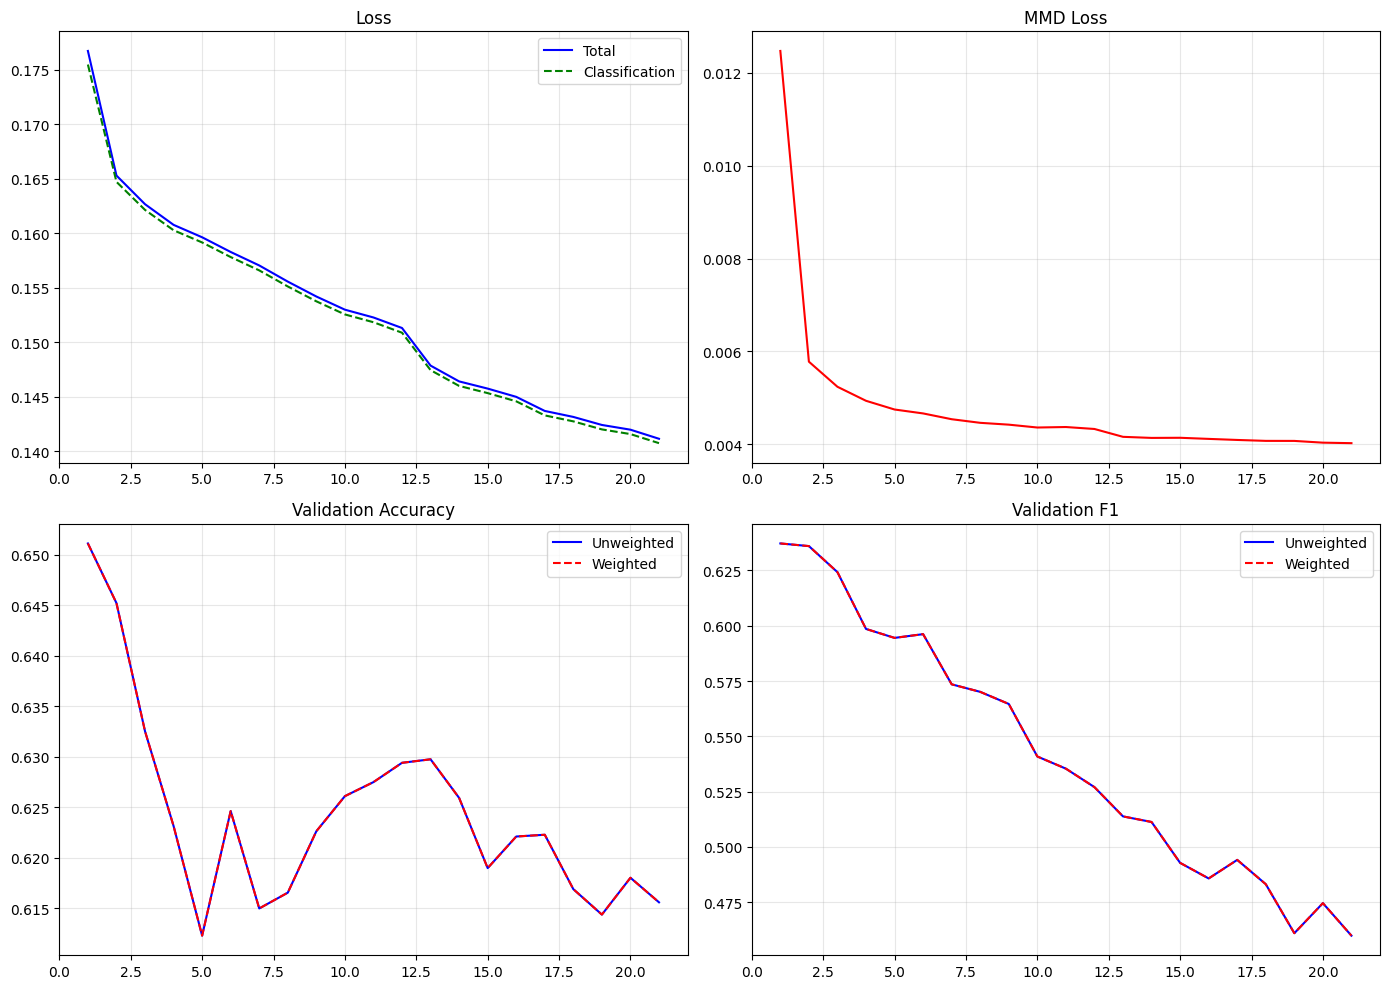


✅ Phase 1 complete! Model: models/phase1_model_unweighted_interact.pth

📈 PERFORMANCE SUMMARY

   HPS Validation:
      Accuracy: 0.6511, F1: 0.6372

   CPS Self-Evaluation:
      Accuracy: 0.7734, F1: 0.7575

   Performance Gap (CPS - HPS):
      Accuracy: 0.1223
      F1: 0.1203
CPS Accuracy: 0.7734
HPS Accuracy: 0.6511
Gap: 0.1223

📊 PERFORMANCE GAP ANALYSIS

🎯 Accuracy Comparison:
   CPS (in-domain):  0.7734
   HPS (transfer):   0.6511
   Gap (CPS - HPS):  0.1223

📈 F1-Score Comparison:
   CPS (in-domain):  0.7575
   HPS (transfer):   0.6372
   Gap (CPS - HPS):  0.1203

⚖️ Weighted Accuracy:
   CPS (weighted):   0.7734
   HPS (weighted):   0.6511
   Gap (CPS - HPS):  0.1223

💡 Interpretation:
   ⚠️ Large gap (>10%): Significant domain shift detected
   → Phase 2 importance weighting is critical


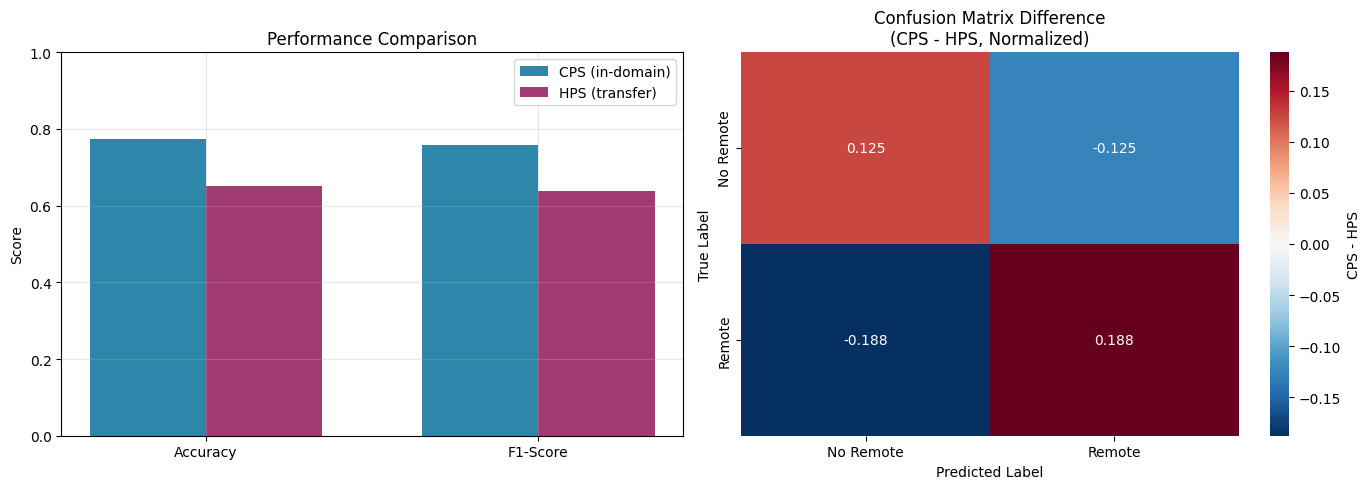


📋 Class-wise Analysis:

   CPS Confusion Matrix (normalized):
   [[0.84378585 0.15621415]
 [0.25767182 0.74232818]]

   HPS Confusion Matrix (normalized):
   [[0.71830778 0.28169222]
 [0.44538527 0.55461473]]

   Difference (CPS - HPS):
   [[ 0.12547807 -0.12547807]
 [-0.18771344  0.18771344]]

   Class Recall Comparison:
      No Remote: CPS=0.8438, HPS=0.7183, Gap=0.1255
      Remote: CPS=0.7423, HPS=0.5546, Gap=0.1877

✅ Analysis saved to results/analysis/

🎯 PHASE 2: IMPORTANCE WEIGHTING

🎯 TRAINING COVARIATE SHIFT DISCRIMINATOR

🔍 PREPARING FEATURES FOR DISCRIMINATION
   Common features: 18
   Features: 130, CPS: 85,294, HPS: 57,536

   Training Logistic Regression...

   ✅ Discriminator Performance:
      Accuracy: 0.7491
      AUC: 0.8320
      ✅ MODERATE covariate shift (good for importance weighting)

              precision    recall  f1-score   support

         CPS     0.7922    0.7860    0.7891     17059
         HPS     0.6864    0.6943    0.6903     11507

    accuracy 

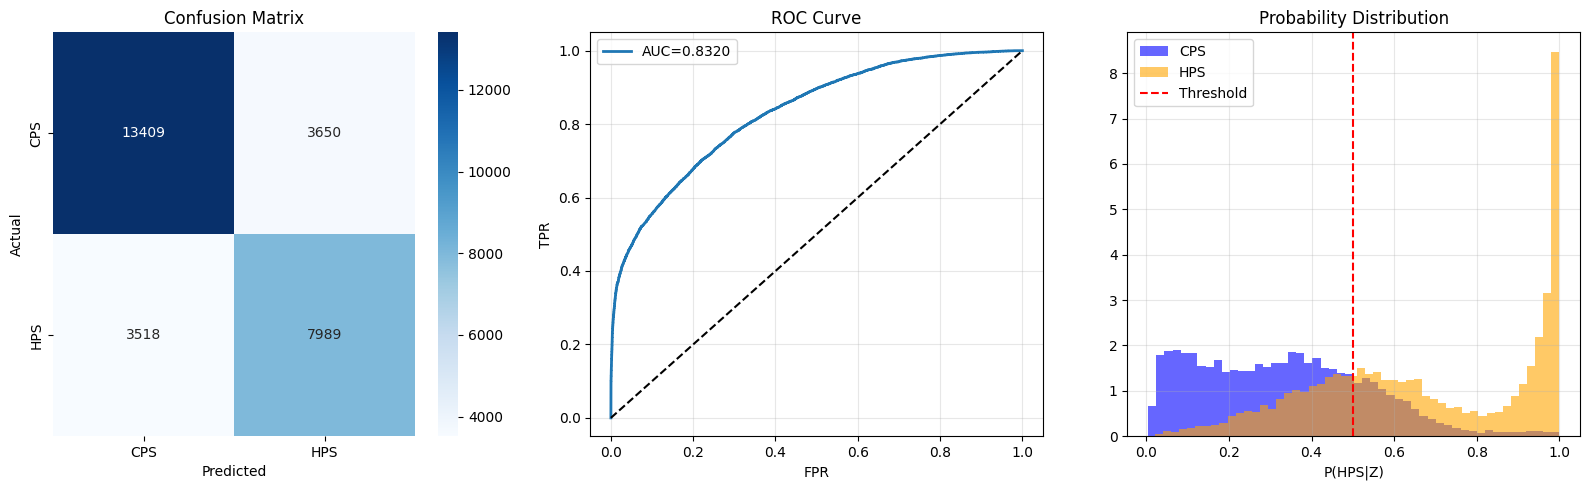


⚖️ COMPUTING IMPORTANCE WEIGHTS

   Raw weights: min=0.0040, max=999.0000, mean=1.3090, median=0.4806

   Winsorized: 4,264 low (5.0%%), 4,265 high (95.0%%)

   ✅ Final weights: [0.0746, 3.2795], mean=1.0000
   📐 ESS: 48,044 / 85,294 (ratio=0.563)
      ✅ Good sample utilization


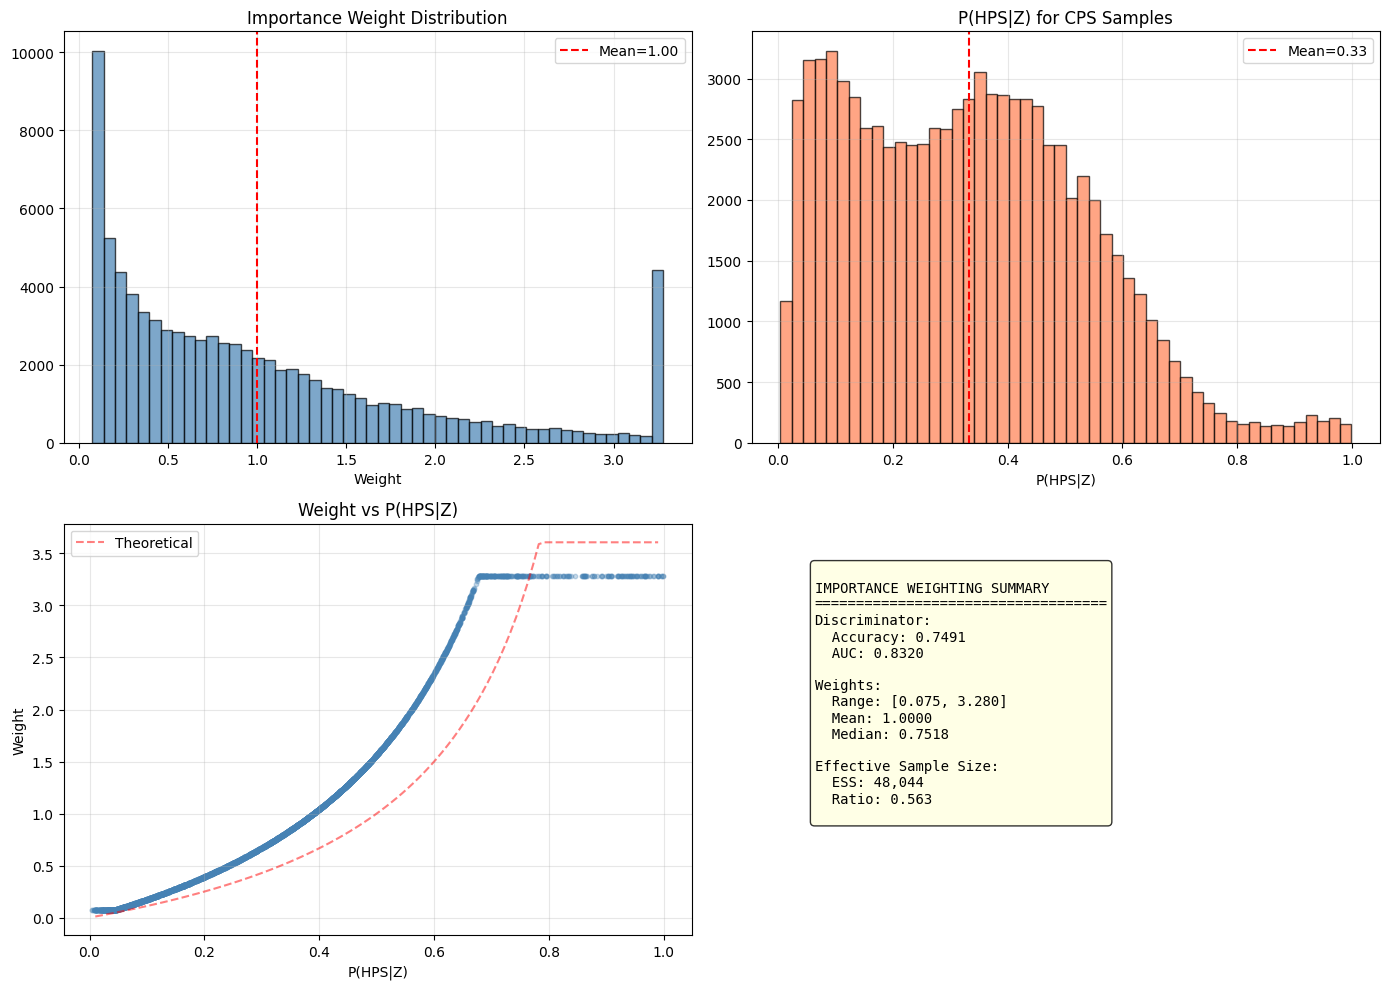


🔄 Retraining with importance weights...

🚀 TRAINING
   CPS: 85,294, HPS train: 46,028, HPS val: 11,508
   Survey weights: False, Importance weights: True


Training:   4%|▍         | 20/500 [00:58<23:31,  2.94s/it]


   Early stop at epoch 21

   ✅ Best F1: 0.6306

📊 PHASE 2
   Accuracy: 0.6470, F1: 0.6306
              precision    recall  f1-score   support

           1     0.6903    0.7276    0.7085      6784
           2     0.5760    0.5313    0.5527      4724

    accuracy                         0.6470     11508
   macro avg     0.6332    0.6295    0.6306     11508
weighted avg     0.6434    0.6470    0.6446     11508


📊 PHASE 2 RESULTS
   Accuracy: 0.6470, F1: 0.6306

🆚 COMPARISON
   Phase 1 F1: 0.6372
   Phase 2 F1: 0.6306
   Improvement: -0.0066
   ➖ Minimal change

✅ Phase 2 complete!


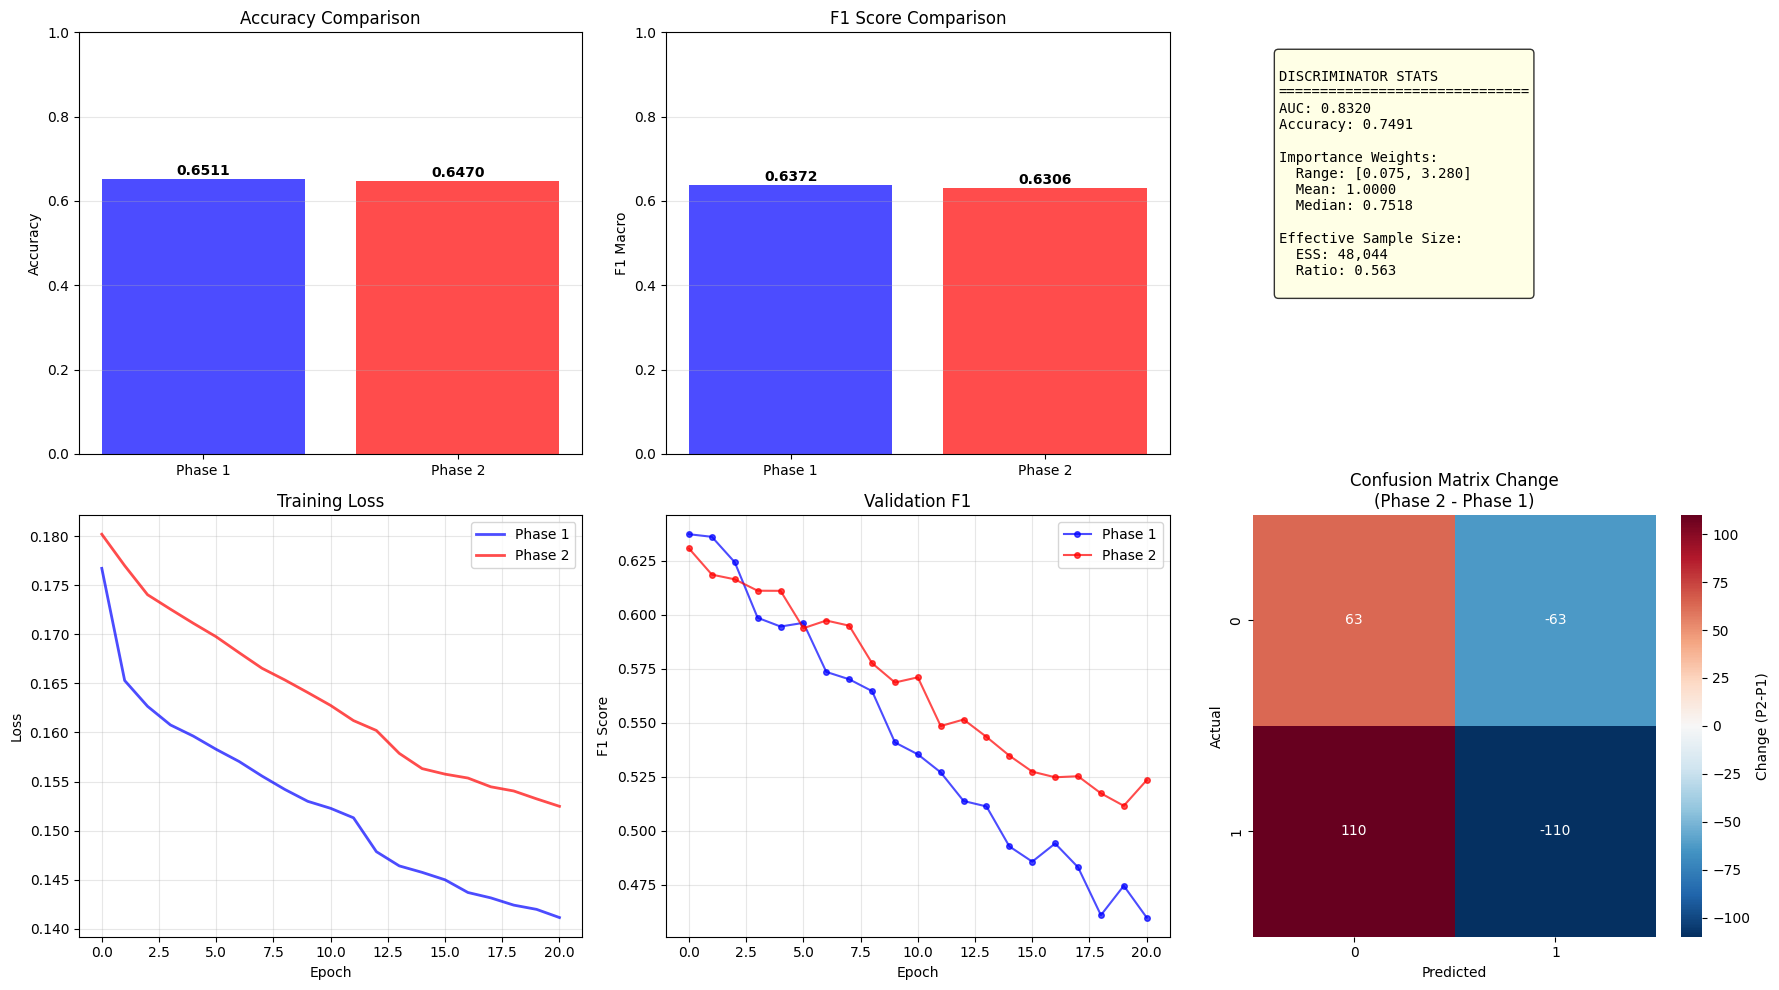

✅ Saved: results/phase1_vs_phase2_unweighted.png

🔬 EXPERIMENT: WITH_WEIGHTS

🎯 PHASE 1: HETEROGENEOUS FEATURE AUGMENTATION

⚡ PREPROCESSING

📊 Processing CPS remote label (pttlwk)...
   Distribution:
      2: 59,142 (69.3%)
      1: 26,152 (30.7%)

📊 HPS remote distribution:
   1: 33,918 (59.0%)
   2: 23,618 (41.0%)
   ⚖️ CPS weights: min=0.049, max=2.043
   ⚖️ HPS weights: min=0.020, max=7.901
   CPS base features: (85294, 416)

🔗 Creating feature interactions...
   Added 22 interactions: 416 → 438 features
   HPS base features: (57536, 86)

🔗 Creating feature interactions...
   Added 22 interactions: 86 → 108 features

✅ CPS: X=(85294, 438), y=(85294,)
   HPS: X=(57536, 108), y=(57536,)
   Classes: [1 2]

📊 Splitting CPS for self-evaluation...
   CPS train: 68,235, CPS test: 17,059

🏗️ HFA: d_cps=438, d_hps=108, k=150, d_aug=696

🚀 TRAINING
   CPS: 68,235, HPS train: 46,028, HPS val: 11,508
   Survey weights: True, Importance weights: False


Training:   6%|▌         | 28/500 [01:04<18:10,  2.31s/it]


   Early stop at epoch 29

   ✅ Best F1: 0.6431

🔍 HPS VALIDATION PERFORMANCE

📊 HPS VALIDATION
   Accuracy: 0.6676, F1: 0.6431
   Accuracy (weighted): 0.6508, F1 (weighted): 0.6508
              precision    recall  f1-score   support

           1     0.6912    0.7885    0.7366      6784
           2     0.6193    0.4941    0.5496      4724

    accuracy                         0.6676     11508
   macro avg     0.6552    0.6413    0.6431     11508
weighted avg     0.6617    0.6676    0.6599     11508


🔍 CPS SELF-EVALUATION PERFORMANCE

📊 CPS SELF-EVALUATION
   Accuracy: 0.8017, F1: 0.7853
   Accuracy (weighted): 0.8094, F1 (weighted): 0.7850
              precision    recall  f1-score   support

           1     0.6300    0.8560    0.7258      5230
           2     0.9243    0.7777    0.8447     11829

    accuracy                         0.8017     17059
   macro avg     0.7772    0.8169    0.7853     17059
weighted avg     0.8341    0.8017    0.8083     17059



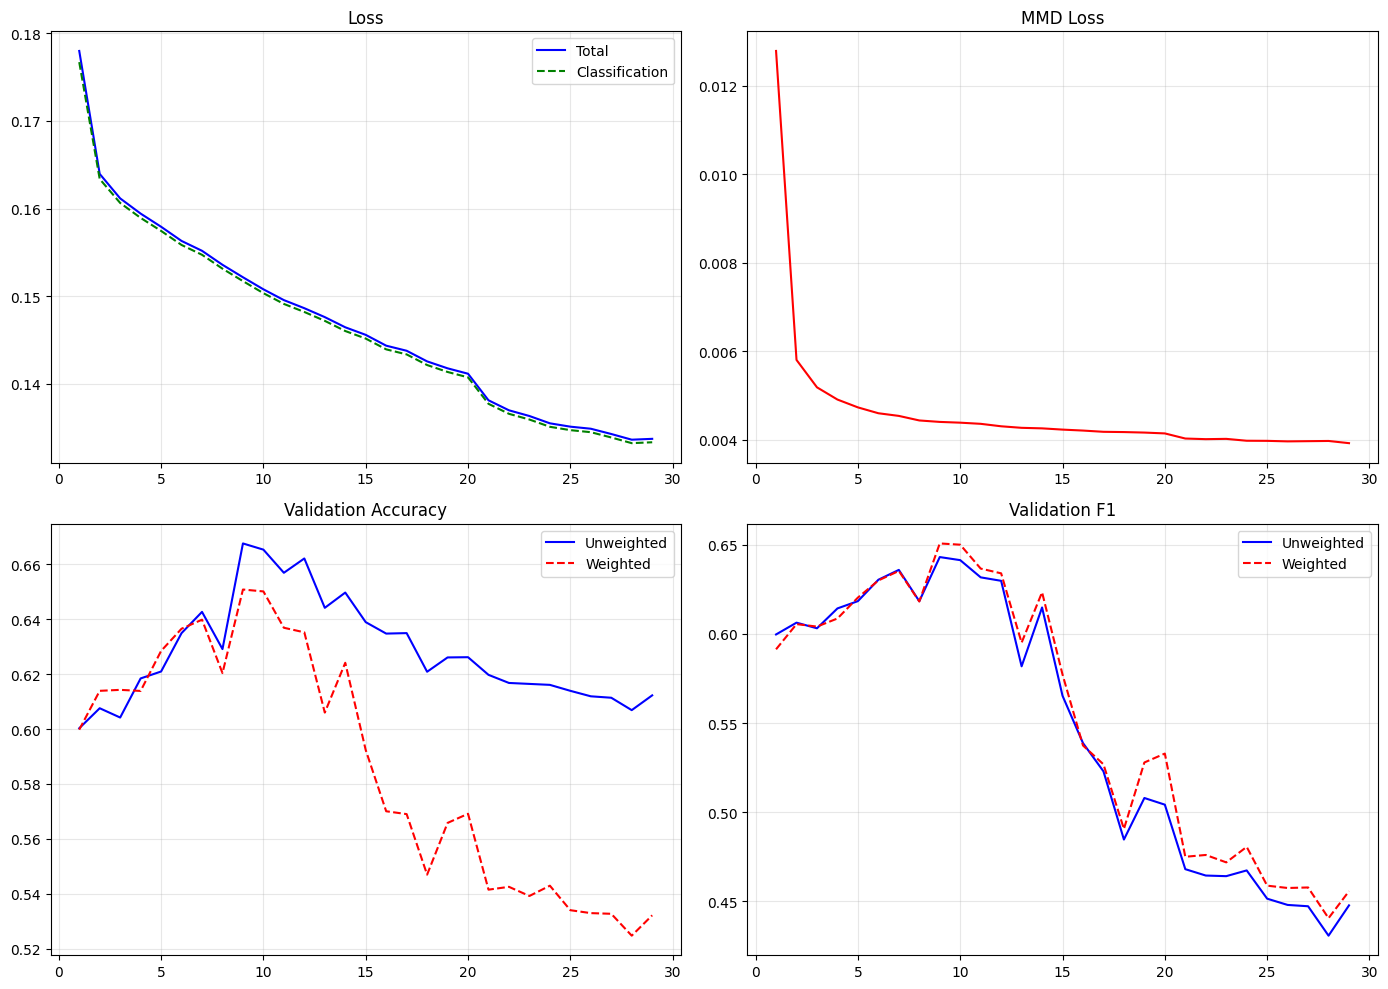


✅ Phase 1 complete! Model: models/phase1_model_weighted_interact.pth

📈 PERFORMANCE SUMMARY

   HPS Validation:
      Accuracy: 0.6676, F1: 0.6431

   CPS Self-Evaluation:
      Accuracy: 0.8017, F1: 0.7853

   Performance Gap (CPS - HPS):
      Accuracy: 0.1341
      F1: 0.1422
CPS Accuracy: 0.8017
HPS Accuracy: 0.6676
Gap: 0.1341

📊 PERFORMANCE GAP ANALYSIS

🎯 Accuracy Comparison:
   CPS (in-domain):  0.8017
   HPS (transfer):   0.6676
   Gap (CPS - HPS):  0.1341

📈 F1-Score Comparison:
   CPS (in-domain):  0.7853
   HPS (transfer):   0.6431
   Gap (CPS - HPS):  0.1422

⚖️ Weighted Accuracy:
   CPS (weighted):   0.8094
   HPS (weighted):   0.6508
   Gap (CPS - HPS):  0.1586

💡 Interpretation:
   ⚠️ Large gap (>10%): Significant domain shift detected
   → Phase 2 importance weighting is critical


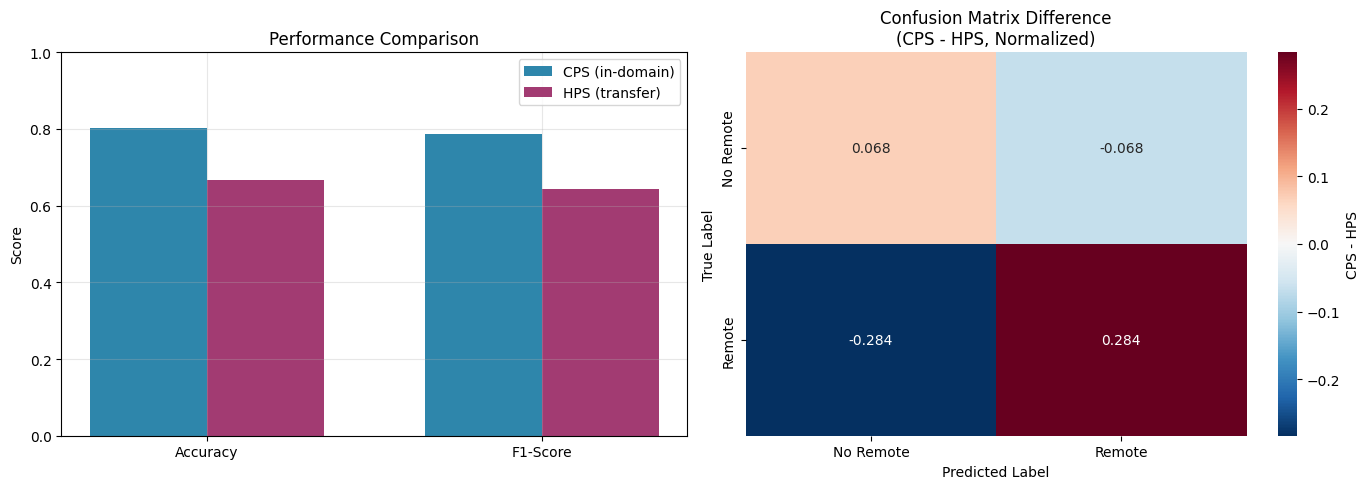


📋 Class-wise Analysis:

   CPS Confusion Matrix (normalized):
   [[0.85602294 0.14397706]
 [0.2222504  0.7777496 ]]

   HPS Confusion Matrix (normalized):
   [[0.78847288 0.21152712]
 [0.50592718 0.49407282]]

   Difference (CPS - HPS):
   [[ 0.06755007 -0.06755007]
 [-0.28367678  0.28367678]]

   Class Recall Comparison:
      No Remote: CPS=0.8560, HPS=0.7885, Gap=0.0676
      Remote: CPS=0.7777, HPS=0.4941, Gap=0.2837

✅ Analysis saved to results/analysis/

🎯 PHASE 2: IMPORTANCE WEIGHTING

🎯 TRAINING COVARIATE SHIFT DISCRIMINATOR

🔍 PREPARING FEATURES FOR DISCRIMINATION
   Common features: 18
   Features: 130, CPS: 85,294, HPS: 57,536

   Training Logistic Regression...

   ✅ Discriminator Performance:
      Accuracy: 0.7491
      AUC: 0.8320
      ✅ MODERATE covariate shift (good for importance weighting)

              precision    recall  f1-score   support

         CPS     0.7922    0.7860    0.7891     17059
         HPS     0.6864    0.6943    0.6903     11507

    accuracy 

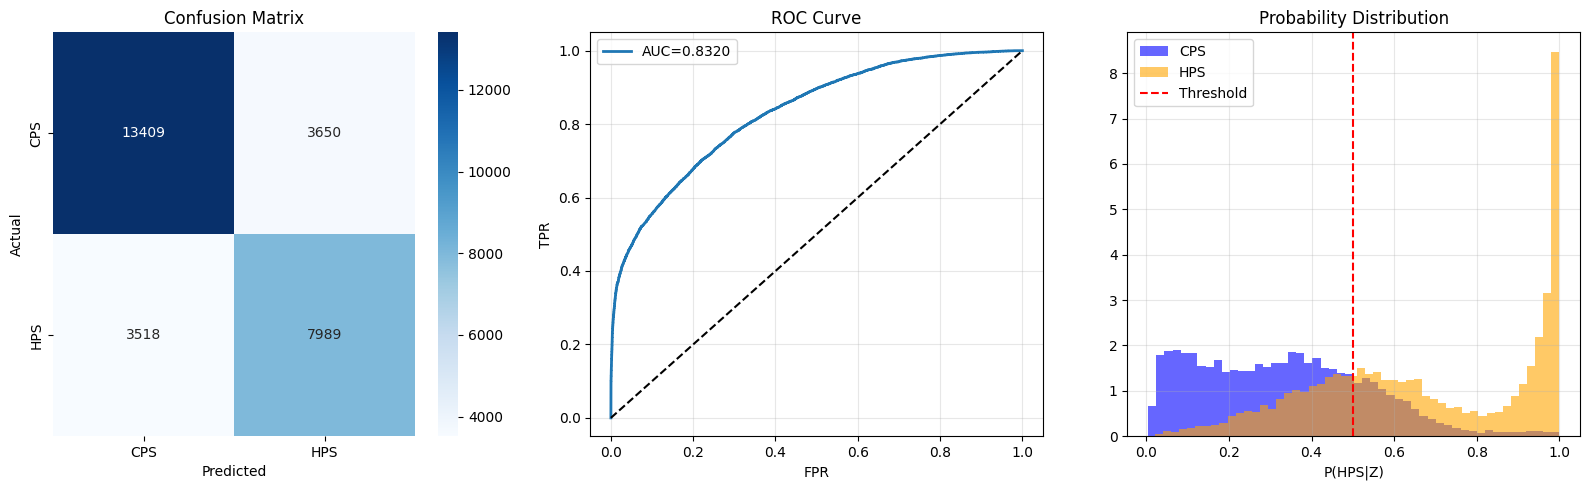


⚖️ COMPUTING IMPORTANCE WEIGHTS

   Raw weights: min=0.0040, max=999.0000, mean=1.3090, median=0.4806

   Winsorized: 4,264 low (5.0%%), 4,265 high (95.0%%)

   ✅ Final weights: [0.0746, 3.2795], mean=1.0000
   📐 ESS: 48,044 / 85,294 (ratio=0.563)
      ✅ Good sample utilization


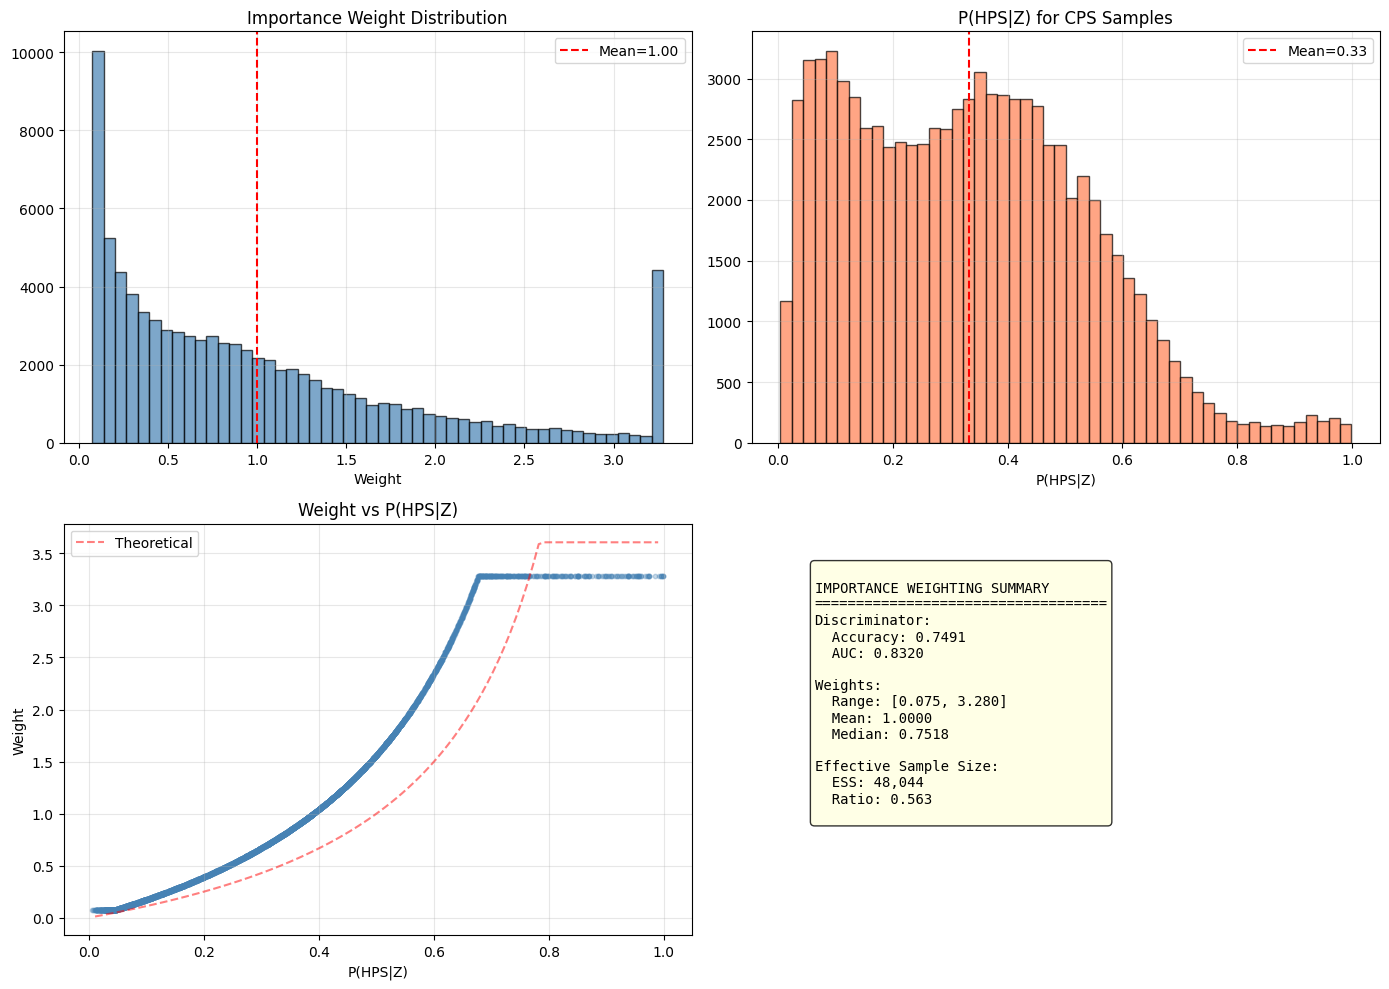


🔄 Retraining with importance weights...

🚀 TRAINING
   CPS: 85,294, HPS train: 46,028, HPS val: 11,508
   Survey weights: True, Importance weights: True


Training:   4%|▍         | 20/500 [00:58<23:27,  2.93s/it]


   Early stop at epoch 21

   ✅ Best F1: 0.6461

📊 PHASE 2
   Accuracy: 0.6701, F1: 0.6461
   Accuracy (weighted): 0.6525, F1 (weighted): 0.6524
              precision    recall  f1-score   support

           1     0.6935    0.7891    0.7382      6784
           2     0.6223    0.4992    0.5540      4724

    accuracy                         0.6701     11508
   macro avg     0.6579    0.6441    0.6461     11508
weighted avg     0.6643    0.6701    0.6626     11508


📊 PHASE 2 RESULTS
   Accuracy: 0.6701, F1: 0.6461

🆚 COMPARISON
   Phase 1 F1: 0.6431
   Phase 2 F1: 0.6461
   Improvement: +0.0030
   ➖ Minimal change

✅ Phase 2 complete!


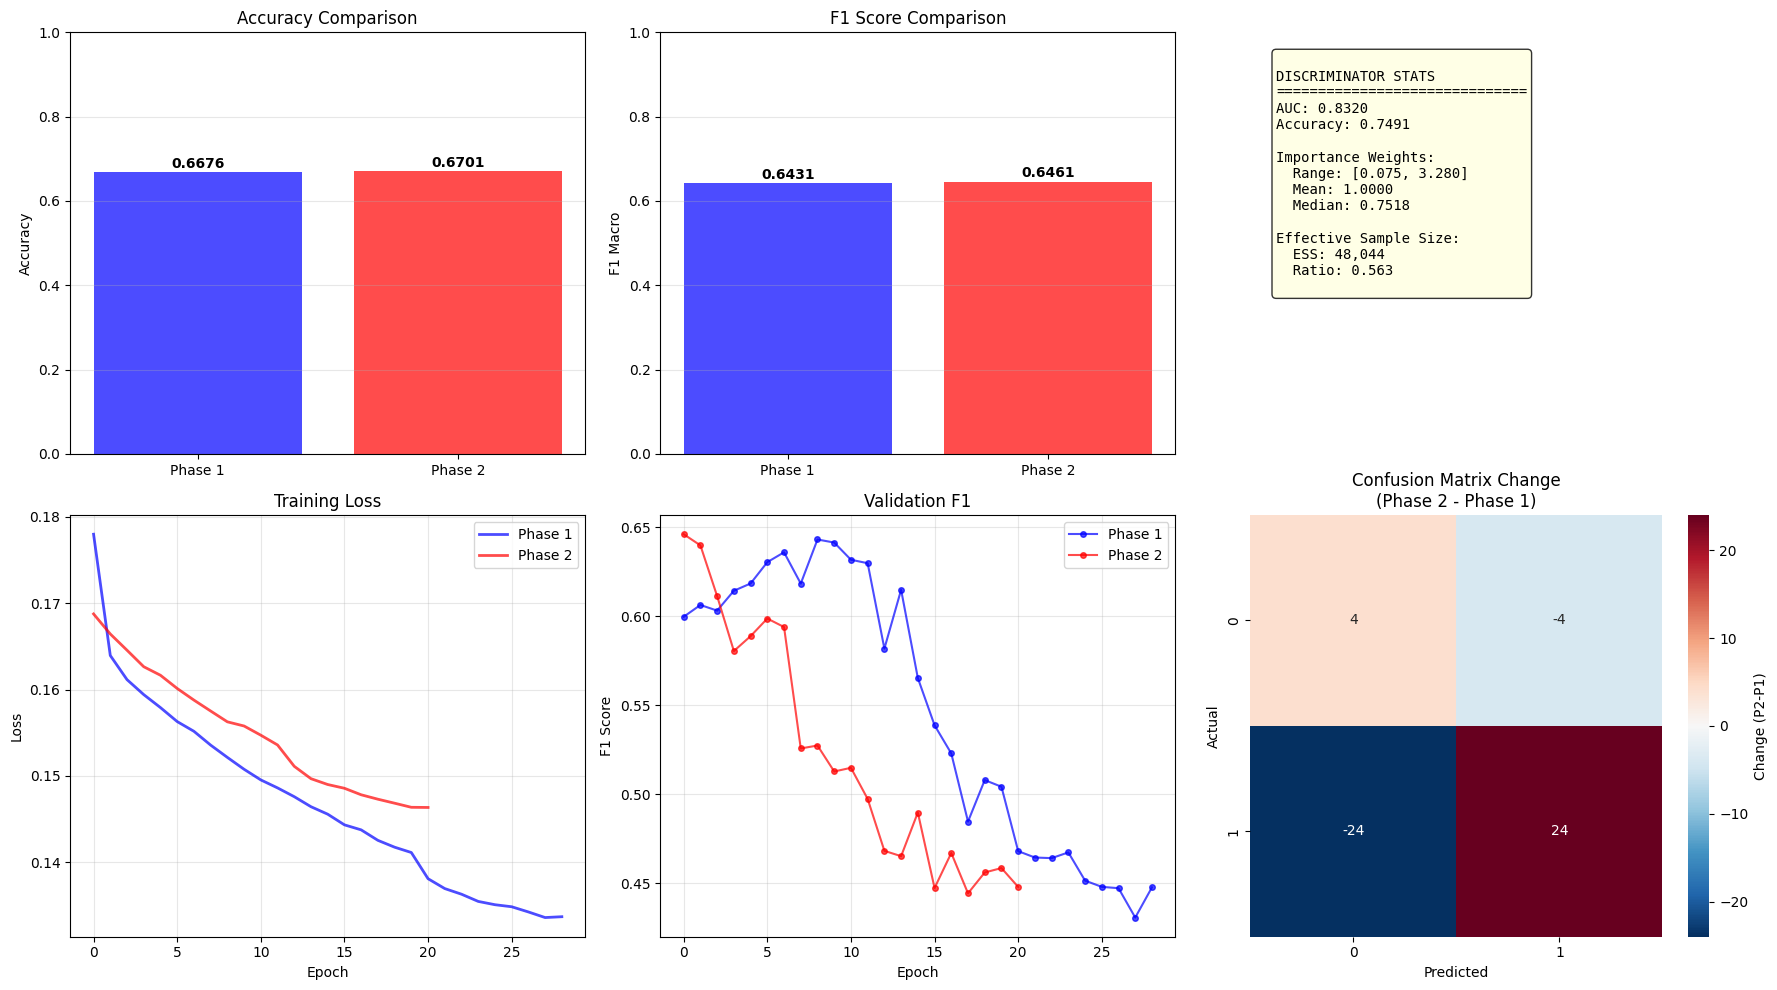

✅ Saved: results/phase1_vs_phase2_weighted.png

🏆 FINAL COMPARISON: SURVEY WEIGHTS IMPACT

            Configuration  Accuracy  F1 Macro  Accuracy (Wt)  F1 (Wt)
WITHOUT_WEIGHTS - Phase 1  0.651112  0.637207       0.651112 0.637207
WITHOUT_WEIGHTS - Phase 2  0.647028  0.630612       0.647028 0.630612
   WITH_WEIGHTS - Phase 1  0.667623  0.643127       0.650829 0.650768
   WITH_WEIGHTS - Phase 2  0.670056  0.646084       0.652493 0.652362


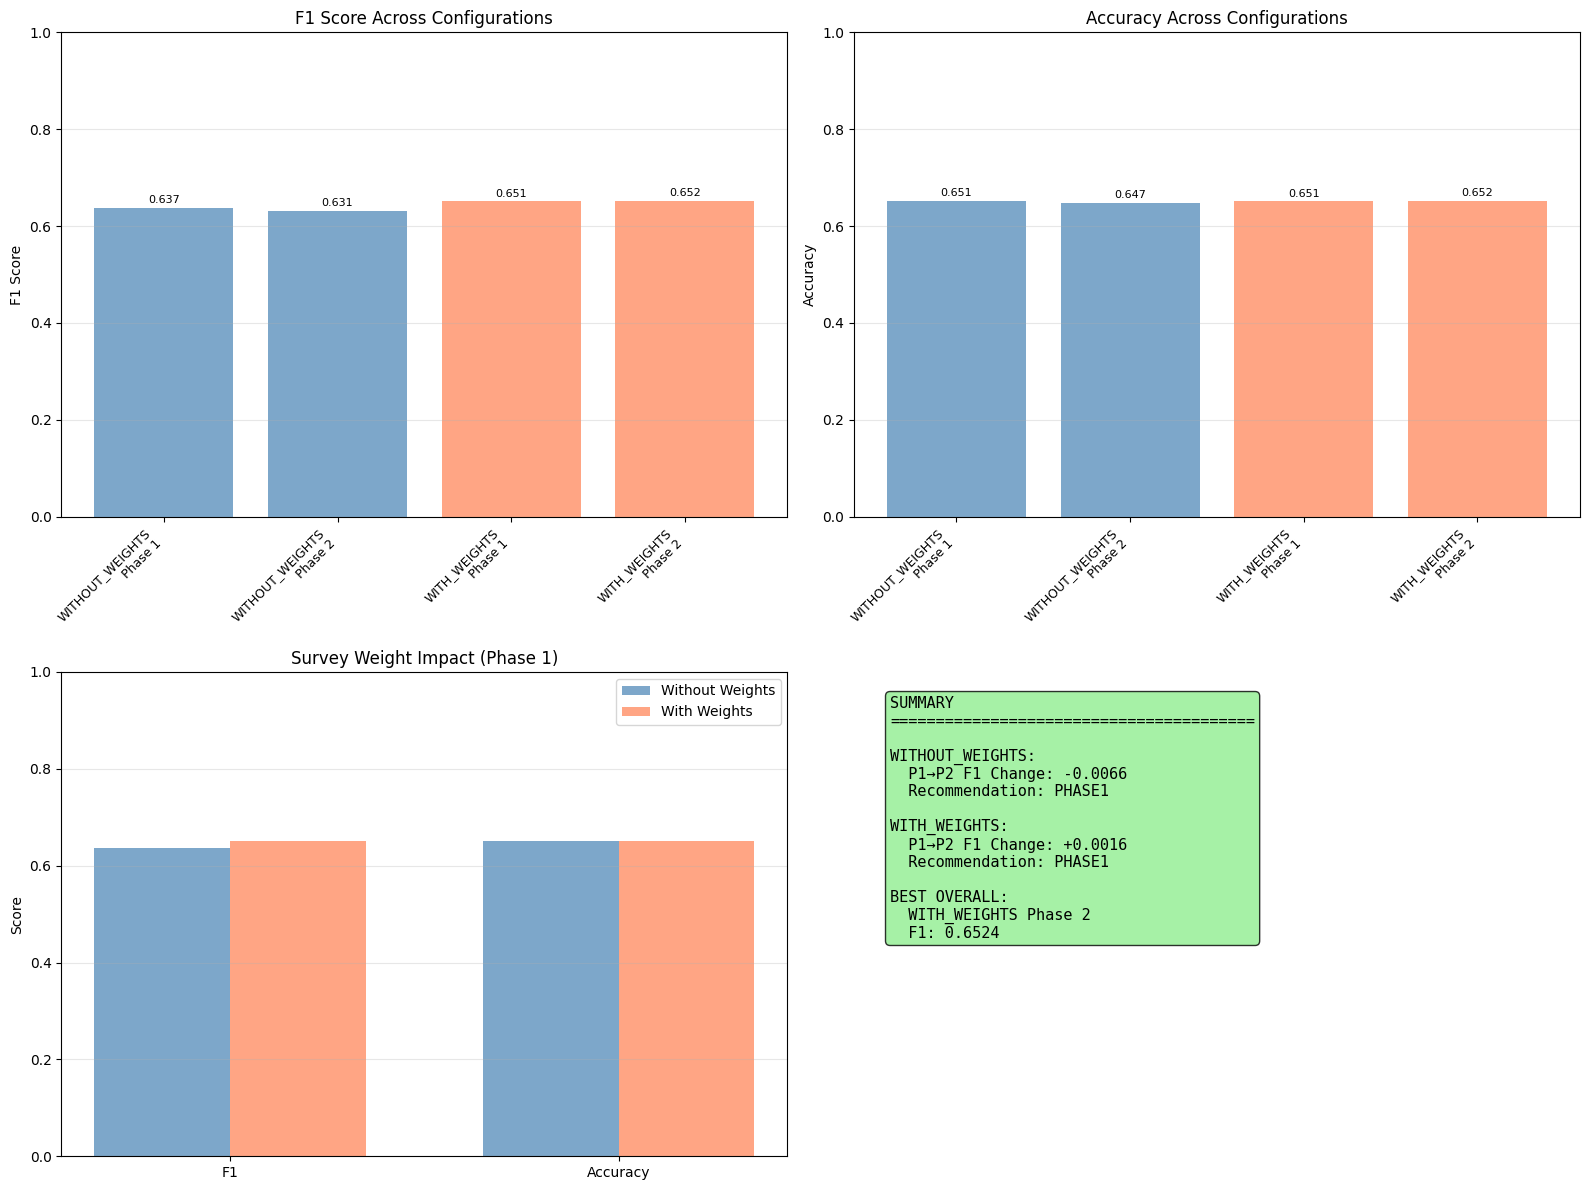

✅ Saved: results/overall_comparison.png

🎯 FINAL RECOMMENDATIONS

   🥇 BEST MODEL: WITH_WEIGHTS - Phase1
      F1 Score: 0.6508

   📊 SURVEY WEIGHTS IMPACT (Phase 1):
      Without: 0.6372
      With: 0.6508
      Change: +0.0136

      Survey weights have MEANINGFUL impact

✅ All results saved to results/
Import this module and call main(X_cps, X_hps) with your data.

Required columns:
  CPS: 'pttlwkhr' (telework hours)
  HPS: 'remote' (remote work category)

Optional weight columns:
  CPS: 'pwsswgt'
  HPS: 'PWEIGHT'


In [ ]:
if __name__ == "__main__":
    # ==========================================================================
    # COMPLETE 4-PHASE PIPELINE
    # ==========================================================================
    # Phase 1 + 2: Run HFA and Importance Weighting (defined in cells above)
    # results = main(X_cps, X_hps)

    # Phase 3: CTABGAN+ Generative Modeling with Query-by-Committee
    # phase3_results = run_phase3(
    #     phase2_output=results['results_by_weight']['WITH_WEIGHTS'],
    #     cps_df=X_cps,
    #     hps_df=X_hps,
    #     cps_specific_features=['prdtind1', 'prdtocc1', 'gtco', 'gtcsa',
    #                            'penatvty', 'pemntvty', 'pefntvty', 'pehractt'],
    #     common_features=['AGE', 'EGENID_BIRTH', 'RHISPANIC', 'RRACE', 'EEDUC',
    #                      'MS', 'KINDWORK', 'INCOME', 'EST_ST', 'EST_MSA',
    #                      'THHLD_NUMPER', 'THHLD_NUMKID'],
    #     hps_specific_features=['HEARING', 'SEEING', 'MOBILITY', 'REMEMBERING',
    #                            'SELFCARE', 'LIVQTRRV'],
    #     target_col='remote',
    #     ctabgan_epochs=150,
    #     n_samples_per_household=5,
    #     agreement_high=0.8,
    #     agreement_low=0.4,
    # )

    # Phase 4: Copula-Based Population Synthesis
    # Example ACS target marginals (replace with real ACS data):
    # target_marginals = {
    #     'AGE': {'type': 'normal', 'mean': 42, 'std': 14},
    #     'INCOME': {'type': 'lognormal', 'mean': 65000, 'std': 45000},
    # }
    #
    # Example IPF targets (replace with real Census proportions):
    # ipf_targets = {
    #     'EEDUC': {1: 0.10, 2: 0.27, 3: 0.29, 4: 0.20, 5: 0.14},
    #     'remote': {1: 0.30, 2: 0.70},  # 30% telework, 70% not
    # }
    #
    # phase4_results = run_phase4(
    #     phase3_output=phase3_results,
    #     n_population=100000,
    #     target_marginals=target_marginals,
    #     ipf_targets=ipf_targets,
    #     n_validation_samples=5000,
    # )
    #
    # synthetic_population = phase4_results['synthetic_population']
    # print(f"Final synthetic population: {synthetic_population.shape}")

    print("="*80)
    print("COMPLETE 4-PHASE HFA PIPELINE")
    print("="*80)
    print()
    print("Phase 1: HFA - Heterogeneous Feature Augmentation")
    print("Phase 2: Domain Adaptation via Importance Weighting")
    print("Phase 3: CTABGAN+ Generative Modeling + Query-by-Committee Ensemble")
    print("Phase 4: Copula-Based Population Synthesis + Uncertainty-Guided Validation")
    print()
    print("Usage:")
    print("  1. Load X_cps and X_hps DataFrames")
    print("  2. results = main(X_cps, X_hps)                    # Phase 1+2")
    print("  3. p3 = run_phase3(phase2_output, X_cps, X_hps)    # Phase 3")
    print("  4. p4 = run_phase4(p3, n_population=100000)         # Phase 4")
    print()
    print("Required columns:")
    print("  CPS: 'pttlwk' (telework status), common + CPS-specific features")
    print("  HPS: 'remote' (remote work category), common + HPS-specific features")

In [ ]:
# ── Save results to Google Drive ─────────────────────────────────────────────
import json
from datetime import datetime

# Populate with your actual result variables
results = {
    "timestamp": datetime.now().strftime('%Y-%m-%d %H:%M'),
    # "accuracy": acc,
    # "f1": f1,
    # "loss_history": loss_history,
    "notes": ""
}

with open(f'{OUTPUT_DIR}/latest_run.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'Results saved to {OUTPUT_DIR}/latest_run.json')
# ─────────────────────────────────────────────────────────────────────────────